## Merging all 9 dtasets


In [29]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Use CSVs beside the notebook when available; otherwise use the verified archive folder.
DATA_DIR = Path(".")
if not (DATA_DIR / "olist_orders_dataset.csv").is_file():
    DATA_DIR = Path.home() / "Downloads" / "archive"

def load(name):
    file_path = DATA_DIR / name
    if not file_path.is_file():
        raise FileNotFoundError(f"Could not find {file_path}. Check that the Olist CSV files are in the data folder.")
    return pd.read_csv(file_path)

orders   = load("olist_orders_dataset.csv")
cust     = load("olist_customers_dataset.csv")
items    = load("olist_order_items_dataset.csv")
pay      = load("olist_order_payments_dataset.csv")
rev      = load("olist_order_reviews_dataset.csv")
prod     = load("olist_products_dataset.csv")
sell     = load("olist_sellers_dataset.csv")
trans    = load("product_category_name_translation.csv")
geo      = load("olist_geolocation_dataset.csv")

# Fix typos in source column names
prod = prod.rename(columns={"product_name_lenght": "product_name_length",
                            "product_description_lenght": "product_description_length"})

# 1) Geolocation: many points per zip prefix -> one averaged lat/lng per prefix
g = (geo.groupby("geolocation_zip_code_prefix")
        .agg(lat=("geolocation_lat", "mean"), lng=("geolocation_lng", "mean"))
        .reset_index())

# 2) Payments: several rows per order -> one row per order (avoids duplicating items)
p = (pay.sort_values(["order_id", "payment_sequential"])
        .groupby("order_id")
        .agg(payment_count=("payment_sequential", "count"),
             payment_types=("payment_type", lambda s: ", ".join(sorted(set(s)))),
             payment_type_primary=("payment_type", "first"),
             payment_installments_max=("payment_installments", "max"),
             payment_value_total=("payment_value", "sum"))
        .reset_index())

# 3) Reviews: a few orders have >1 review -> keep the latest one, record how many
rev["review_answer_timestamp"] = pd.to_datetime(rev["review_answer_timestamp"])
review_counts = rev.groupby("order_id").size().rename("review_count")
rv = (rev.sort_values("review_answer_timestamp")
         .drop_duplicates("order_id", keep="last")
         .merge(review_counts, on="order_id"))

# 4) Products + English category name (untranslated categories keep the Portuguese name)
prod = prod.merge(trans, on="product_category_name", how="left")
prod["product_category_name_english"] = prod["product_category_name_english"].fillna(prod["product_category_name"])

# 5) Customers / sellers + coordinates
cust = cust.merge(g.rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix",
                                    "lat": "customer_lat", "lng": "customer_lng"}),
                  on="customer_zip_code_prefix", how="left")
sell = sell.merge(g.rename(columns={"geolocation_zip_code_prefix": "seller_zip_code_prefix",
                                    "lat": "seller_lat", "lng": "seller_lng"}),
                  on="seller_zip_code_prefix", how="left")

# MASTER: one row per order item (orders without items kept as one row)
master = (orders
          .merge(cust,  on="customer_id", how="left", validate="1:1")
          .merge(items, on="order_id",    how="left", validate="1:m")
          .merge(prod,  on="product_id",  how="left", validate="m:1")
          .merge(sell,  on="seller_id",   how="left", validate="m:1")
          .merge(p,     on="order_id",    how="left", validate="m:1")
          .merge(rv,    on="order_id",    how="left", validate="m:1"))

# Convert date columns
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date",
             "shipping_limit_date", "review_creation_date"]
for c in date_cols:
    master[c] = pd.to_datetime(master[c])

# Helper columns
master["item_total_value"] = master["price"] + master["freight_value"]
master["delivery_days"] = ((master["order_delivered_customer_date"] - master["order_purchase_timestamp"])
                           .dt.total_seconds() / 86400).round(2)
master["delivered_late"] = np.where(
    master["order_delivered_customer_date"].isna(), np.nan,
    (master["order_delivered_customer_date"].dt.normalize() > master["order_estimated_delivery_date"]).astype(float))
master["purchase_year_month"] = master["order_purchase_timestamp"].dt.strftime("%Y-%m")

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

master["seller_customer_distance_km"] = haversine_km(master["customer_lat"], master["customer_lng"],
                                                     master["seller_lat"], master["seller_lng"]).round(1)

# Column order
cols = ["order_id", "order_item_id", "order_status", "order_purchase_timestamp", "purchase_year_month",
        "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date", "delivery_days", "delivered_late",
        "customer_id", "customer_unique_id", "customer_zip_code_prefix", "customer_city", "customer_state",
        "customer_lat", "customer_lng",
        "product_id", "product_category_name", "product_category_name_english", "product_name_length",
        "product_description_length", "product_photos_qty", "product_weight_g", "product_length_cm",
        "product_height_cm", "product_width_cm",
        "seller_id", "seller_zip_code_prefix", "seller_city", "seller_state", "seller_lat", "seller_lng",
        "seller_customer_distance_km",
        "shipping_limit_date", "price", "freight_value", "item_total_value",
        "payment_count", "payment_types", "payment_type_primary", "payment_installments_max", "payment_value_total",
        "review_id", "review_count", "review_score", "review_comment_title", "review_comment_message",
        "review_creation_date", "review_answer_timestamp"]
master = master[cols].sort_values(["order_purchase_timestamp", "order_id", "order_item_id"]).reset_index(drop=True)

# Sanity checks: totals must match the source files
print("Master shape:", master.shape)                                  # expected (113425, 51)
print("Orders:", master["order_id"].nunique(), "vs", len(orders))
print("Item price total:", round(master["price"].sum(), 2), "vs", round(items["price"].sum(), 2))
print("Payment total:", round(master.drop_duplicates("order_id")["payment_value_total"].sum(), 2),
      "vs", round(pay["payment_value"].sum(), 2))

# Save
master.to_csv(DATA_DIR / "olist_master_dataset.csv", index=False)
# master.to_excel(DATA_DIR / "olist_master_dataset.xlsx", index=False)  # optional, slow (~1-2 min), needs openpyxl
print("Saved olist_master_dataset.csv")

Master shape: (113425, 51)
Orders: 99441 vs 99441
Item price total: 13591643.7 vs 13591643.7
Payment total: 16008872.12 vs 16008872.12
Saved olist_master_dataset.csv


## Nearby SKU Demand Maps
Configure the SKU, hub location, radius, and number of zip3 areas here.

In [46]:
# Parameters for the SKU catchment analysis.
PRODUCT_ID = "aca2eb7d00ea1a7b8ebd4e68314663af"
HUB_LAT, HUB_LNG = -23.5505, -46.6333
RADIUS_KM = 100
TOP_N_AREAS = 15

In [30]:
with pd.option_context("display.max_columns", None, "display.width", 2000):
    display(master.head(10))

,order_id,order_item_id,order_status,order_purchase_timestamp,purchase_year_month,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivered_late,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,product_id,product_category_name,product_category_name_english,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_customer_distance_km,shipping_limit_date,price,freight_value,item_total_value,payment_count,payment_types,payment_type_primary,payment_installments_max,payment_value_total,review_id,review_count,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,2e7a8482f6fb09756ca50c10d7bfc047,1.0,shipped,2016-09-04 21:15:19,2016-09,2016-10-07 13:18:03,2016-10-18 13:14:51,NaT,2016-10-20,NaN,NaN,08c5351a6aca1c1589a38f244edeee9d,b7d76e111c89f7ebf14761390f0f7d17,69309,boa vista,RR,2.813746,-60.701007,c1488892604e4ba5cff5b4eb4d595400,moveis_decoracao,furniture_decor,59.0,426.0,2.0,1400.0,32.0,6.0,28.0,1554a68530182680ad5c8b042c3ab563,37580.0,monte siao,MG,-22.430218,-46.573405,3198.8,2016-10-26 18:25:19,39.99,31.67,71.66,1.0,credit_card,credit_card,1.0,136.23,cef1ee03ded4d6272894a2eead6e1328,1.0,1.0,NaN,1 mes de atraso na entrega !!! ultima compra q...,2016-10-22,2016-11-15 16:00:34
1,2e7a8482f6fb09756ca50c10d7bfc047,2.0,shipped,2016-09-04 21:15:19,2016-09,2016-10-07 13:18:03,2016-10-18 13:14:51,NaT,2016-10-20,NaN,NaN,08c5351a6aca1c1589a38f244edeee9d,b7d76e111c89f7ebf14761390f0f7d17,69309,boa vista,RR,2.813746,-60.701007,f293394c72c9b5fafd7023301fc21fc2,moveis_decoracao,furniture_decor,41.0,754.0,3.0,1800.0,32.0,6.0,28.0,1554a68530182680ad5c8b042c3ab563,37580.0,monte siao,MG,-22.430218,-46.573405,3198.8,2016-10-26 18:25:19,32.90,31.67,64.57,1.0,credit_card,credit_card,1.0,136.23,cef1ee03ded4d6272894a2eead6e1328,1.0,1.0,NaN,1 mes de atraso na entrega !!! ultima compra q...,2016-10-22,2016-11-15 16:00:34
2,e5fa5a7210941f7d56d0208e4e071d35,1.0,canceled,2016-09-05 00:15:34,2016-09,2016-10-07 13:17:15,NaT,NaT,2016-10-28,NaN,NaN,683c54fc24d40ee9f8a6fc179fd9856c,4854e9b3feff728c13ee5fc7d1547e92,99025,passo fundo,RS,-28.264640,-52.425421,f3c2d01a84c947b078e32bbef0718962,telefonia,telephony,42.0,381.0,1.0,700.0,25.0,2.0,25.0,a425f92c199eb576938df686728acd20,81050.0,curitiba,PR,-25.490559,-49.302027,437.1,2016-09-19 00:15:34,59.50,15.56,75.06,1.0,credit_card,credit_card,3.0,75.06,a93139d9d1314158c080e3db7e79618b,1.0,1.0,NaN,Comprei dois produtos desta loja parceira da l...,2016-10-29,2016-10-30 01:47:48
3,809a282bbd5dbcabb6f2f724fca862ec,NaN,canceled,2016-09-13 15:24:19,2016-09,2016-10-07 13:16:46,NaT,NaT,2016-09-30,NaN,NaN,622e13439d6b5a0b486c435618b2679e,009b0127b727ab0ba422f6d9604487c7,12244,sao jose dos campos,SP,-23.198979,-45.943171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,1.0,credit_card,credit_card,2.0,40.95,69ac6a27fde9855ebeaaecac0f78058b,1.0,1.0,NaN,MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NEN...,2016-10-02,2016-10-26 12:31:00
4,bfbd0f9bdef84302105ad712db648a6c,1.0,delivered,2016-09-15 12:16:38,2016-09,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.81,1.0,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,-20.585751,-47.863693,5a6b04657a4c5ee34285d1e4619a96b4,beleza_saude,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,ecccfa2bb93b34a3bf033cc5d1dcdc69,81810.0,curitiba,PR,-25.507014,-49.275963,566.0,2016-09-19 23:11:33,44.99,2.83,47.82,NaN,NaN,NaN,NaN,NaN,6916ca4502d6d3bfd39818759d55d536,1.0,1.0,NaN,nao recebi o produto e nem resposta da empresa,2016-10-06,2016-10-07 18:32:28
5,bfbd0f9bdef84302105ad712db648a6c,2.0,delivered,2016-09-15 12:16:38,2016-09,2016-09-15 12:16:38,2

In [31]:
selected_columns = [
    "customer_zip_code_prefix", "customer_city", "customer_state", "customer_lat", "customer_lng",
    "product_id", "product_category_name_english",
    "seller_zip_code_prefix", "seller_city", "seller_state", "seller_lat", "seller_lng",
    "seller_customer_distance_km",
]

master_selected = master[selected_columns].copy()
master_selected.to_csv(DATA_DIR / "olist_master_selected_columns.csv", index=False)

print(f"Selected dataset shape: {master_selected.shape}")
with pd.option_context("display.max_columns", None, "display.width", 1600):
    display(master_selected.head(10))

Selected dataset shape: (113425, 13)


,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,product_id,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_customer_distance_km
0,69309,boa vista,RR,2.813746,-60.701007,c1488892604e4ba5cff5b4eb4d595400,furniture_decor,37580.0,monte siao,MG,-22.430218,-46.573405,3198.8
1,69309,boa vista,RR,2.813746,-60.701007,f293394c72c9b5fafd7023301fc21fc2,furniture_decor,37580.0,monte siao,MG,-22.430218,-46.573405,3198.8
2,99025,passo fundo,RS,-28.264640,-52.425421,f3c2d01a84c947b078e32bbef0718962,telephony,81050.0,curitiba,PR,-25.490559,-49.302027,437.1
3,12244,sao jose dos campos,SP,-23.198979,-45.943171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,14600,sao joaquim da barra,SP,-20.585751,-47.863693,5a6b04657a4c5ee34285d1e4619a96b4,health_beauty,81810.0,curitiba,PR,-25.507014,-49.275963,566.0
5,14600,sao joaquim da barra,SP,-20.585751,-47.863693,5a6b04657a4c5ee34285d1e4619a96b4,health_beauty,81810.0,curitiba,PR,-25.507014,-49.275963,566.0
6,14600,sao joaquim da barra,SP,-20.585751,-47.863693,5a6b04657a4c5ee34285d1e4619a96b4,health_beauty,81810.0,curitiba,PR,-25.507014,-49.275963,566.0
7,2975,sao paulo,SP,-23.478131,-46.711362,d2998d7ced12f83f9b832f33cf6507b6,baby,5503.0,sao paulo,SP,-23.570212,-46.710840,10.2
8,4106,sao paulo,SP,-23.581451,-46.635029,3ae08df6bcbfe23586dd431c40bddbb7,watches_gifts,85801.0,cascavel,PR,-24.959184,-53.462644,708.8
9,98280,panambi,RS,-28.293541,-53.502238,fd7fd78fd3cbc1b0a6370a7909c0a629,sports_leisure,15802.0,catanduva,SP,-21.143389,-48.995314,915.9


In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the saved master dataset from the notebook folder.
master_path = Path.cwd() / "olist_master_dataset.csv"
if not master_path.is_file():
    raise FileNotFoundError(f"Master dataset not found in the notebook folder: {master_path}")
master = pd.read_csv(master_path)

required_columns = {
    "order_id", "product_id", "product_category_name_english", "customer_state"
}
missing_columns = required_columns.difference(master.columns)
if missing_columns:
    raise KeyError(f"Master dataset is missing required columns: {sorted(missing_columns)}")

print(f"Loaded {master.shape[0]:,} master rows from {master_path}")

Loaded 113,425 master rows from /Users/dhruv_rai/Desktop/Meesho/olist_master_dataset.csv


In [39]:
# Rank product-category pairs by unique orders, then order-line count.
top_20 = (
    master.loc[master["product_id"].notna()]
    .groupby(
        ["product_id", "product_category_name_english"],
        dropna=False,
        as_index=False,
    )
    .agg(
        unique_orders=("order_id", "nunique"),
        order_line_count=("order_id", "size"),
    )
    .sort_values(
        ["unique_orders", "order_line_count"],
        ascending=[False, False],
        kind="mergesort",
    )
    .head(20)
    .reset_index(drop=True)
)
top_20.insert(0, "rank", np.arange(1, len(top_20) + 1))
top_20["category_label"] = top_20["product_category_name_english"].fillna("unknown")
top_20["label"] = top_20.apply(
    lambda row: f"{row['rank']}. {row['product_id'][:6]} · {row['category_label']}",
    axis=1,
)

# Keep one record per product-order pair and attach the display label.
product_labels = top_20[
    ["product_id", "product_category_name_english", "label"]
]
sub = (
    master.merge(
        product_labels,
        on=["product_id", "product_category_name_english"],
        how="inner",
        validate="many_to_one",
    )
    .drop_duplicates(["product_id", "order_id"])
)

# Count distinct product orders by customer state.
ps = (
    sub.groupby(["label", "customer_state"], dropna=False)["order_id"]
    .nunique()
    .unstack("customer_state", fill_value=0)
    .reindex(top_20["label"], fill_value=0)
)
state_order = ps.sum(axis=0).sort_values(ascending=False, kind="stable").index
ps = ps.loc[:, state_order]
share = ps.div(ps.sum(axis=1), axis=0).mul(100).fillna(0)

print("Top 3 product order counts:")
print(top_20.loc[:2, ["label", "unique_orders"]].to_string(index=False))

Top 3 product order counts:
                      label  unique_orders
 1. 99a478 · bed_bath_table            467
2. aca2eb · furniture_decor            431
   3. 422879 · garden_tools            352


## Getting top 20 sold product ids (SKUs) in Brazil


In [42]:
# Load only the columns needed for the product ranking.
import pandas as pd

master = pd.read_csv(
    "olist_master_dataset.csv",
    usecols=["order_id", "product_id", "product_category_name_english"],
)

# Rank products by distinct orders, using line count to break ties.
top20 = (
    master.dropna(subset=["product_id"])
    .groupby(
        ["product_id", "product_category_name_english"],
        dropna=False,
    )
    .agg(
        unique_orders=("order_id", "nunique"),
        order_line_count=("order_id", "size"),
    )
    .reset_index()
    .sort_values(
        ["unique_orders", "order_line_count"],
        ascending=[False, False],
        kind="stable",
    )
    .head(20)
    .reset_index(drop=True)
)

top20 = top20[
    ["product_id", "product_category_name_english", "unique_orders", "order_line_count"]
]
top20.to_csv("top20_products.csv", index=False)
top20

,product_id,product_category_name_english,unique_orders,order_line_count
0,99a4788cb24856965c36a24e339b6058,bed_bath_table,467,488
1,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,431,527
2,422879e10f46682990de24d770e7f83d,garden_tools,352,484
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,323,343
4,389d119b48cf3043d311335e499d9c6b,garden_tools,311,392
5,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,306,323
6,368c6c730842d78016ad823897a372db,garden_tools,291,388
7,53759a2ecddad2bb87a079a1f1519f73,garden_tools,287,373
8,154e7e31ebfa092203795c972e5804a6,health_beauty,269,281
9,2b4609f8948be18874494203496bc318,health_beauty,259,260


## Distribution of product sold accross Brazil

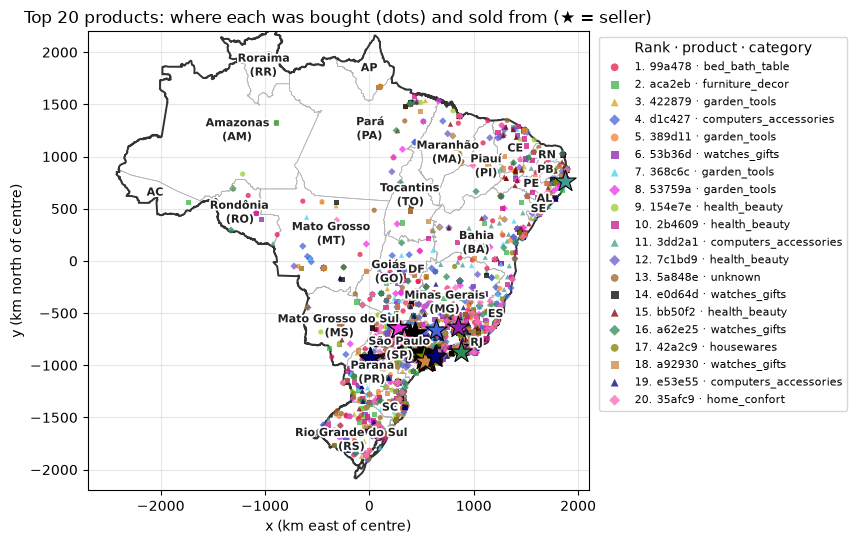

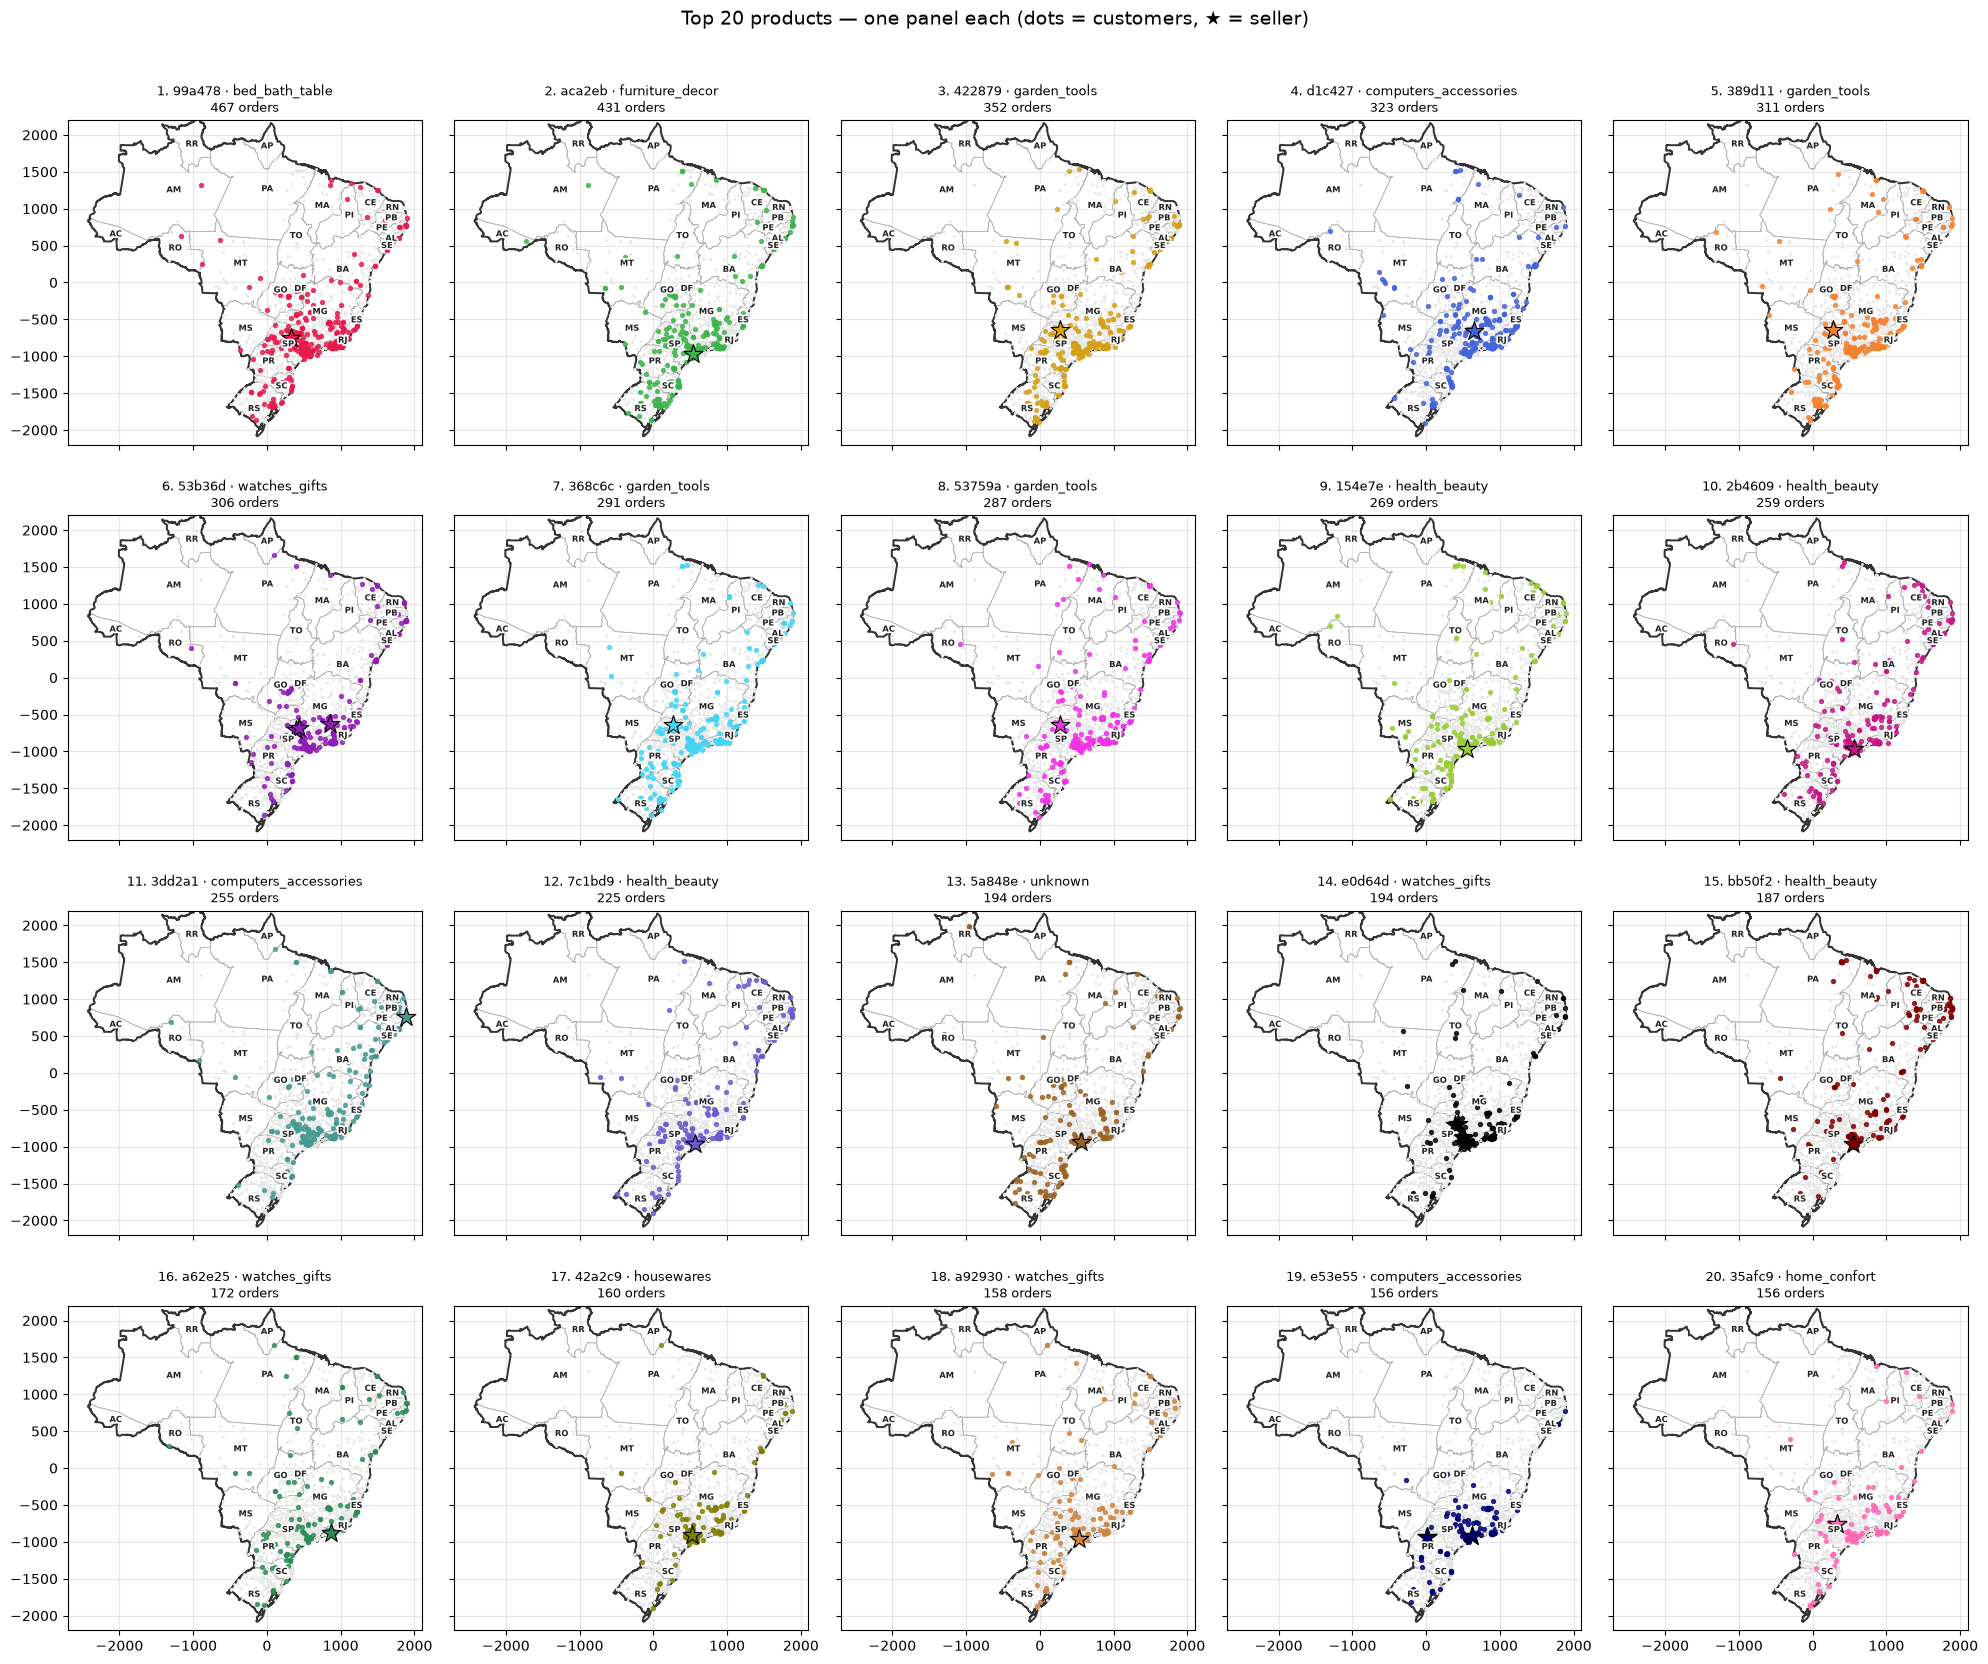

Restored maps: Images/top20_products_xy.png and Images/top20_products_panels.png


In [34]:
# Restore the combined and per-product Brazil maps.
import json
import ssl
from urllib.request import urlopen

import certifi
import matplotlib.patheffects as path_effects
from shapely.geometry import MultiPolygon, Polygon, shape
from shapely.ops import unary_union

MAP_LAT0 = -15
MAP_LON0 = -52
MAP_R = 6371


def to_xy_km(lat, lng):
    lat_values = np.asarray(lat, dtype=float)
    lng_values = np.asarray(lng, dtype=float)
    x = MAP_R * np.radians(lng_values - MAP_LON0) * np.cos(np.radians(lat_values))
    y = MAP_R * np.radians(lat_values - MAP_LAT0)
    if lat_values.ndim == 0 and lng_values.ndim == 0:
        return round(float(x), 2), round(float(y), 2)
    return np.round(x, 2), np.round(y, 2)


map_data = master.copy()
for prefix in ("customer", "seller"):
    lat_col = f"{prefix}_lat"
    lng_col = f"{prefix}_lng"
    valid_point = map_data[lat_col].between(-34, 5.5) & map_data[lng_col].between(-74, -34)
    map_data.loc[~valid_point, [lat_col, lng_col]] = np.nan

map_data["customer_x_km"], map_data["customer_y_km"] = to_xy_km(
    map_data["customer_lat"], map_data["customer_lng"]
)
map_data["seller_x_km"], map_data["seller_y_km"] = to_xy_km(
    map_data["seller_lat"], map_data["seller_lng"]
)

# Load the state boundaries and prepare drawing helpers.
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
ssl_context = ssl.create_default_context(cafile=certifi.where())
with urlopen(geojson_url, context=ssl_context, timeout=30) as response:
    state_geojson = json.load(response)

map_states = [
    {
        "name": feature["properties"]["name"],
        "code": feature["properties"]["sigla"],
        "geometry": shape(feature["geometry"]),
    }
    for feature in state_geojson["features"]
]
map_border = unary_union([state["geometry"] for state in map_states]).buffer(0)


def map_polygons(geometry):
    if isinstance(geometry, Polygon):
        yield geometry
    elif isinstance(geometry, MultiPolygon):
        yield from geometry.geoms


def draw_outline(ax, geometry, color, linewidth, zorder, min_area=0):
    for polygon in map_polygons(geometry):
        if polygon.area < min_area:
            continue
        outline = np.asarray(
            [to_xy_km(lat, lng) for lng, lat in polygon.exterior.coords]
        )
        ax.plot(
            outline[:, 0], outline[:, 1],
            color=color, linewidth=linewidth, zorder=zorder,
        )


def draw_brazil(ax):
    for state in map_states:
        draw_outline(ax, state["geometry"], "#b0b0b0", 0.5, 1)
    draw_outline(ax, map_border, "#333333", 1.4, 2, min_area=0.01)


def label_states(ax, full_names, fontsize):
    for state in map_states:
        geometry = state["geometry"]
        point = geometry.representative_point()
        x, y = to_xy_km(point.y, point.x)
        text = (
            f"{state['name']}\n({state['code']})"
            if full_names and geometry.area > 15
            else state["code"]
        )
        ax.text(
            x, y, text,
            fontsize=fontsize,
            fontweight="bold",
            color="#222222",
            ha="center",
            va="center",
            zorder=6,
            path_effects=[path_effects.withStroke(linewidth=2.5, foreground="white")],
        )


map_labels = top_20[["product_id", "product_category_name_english", "label"]]
product_map_data = (
    map_data.merge(
        map_labels,
        on=["product_id", "product_category_name_english"],
        how="inner",
        validate="many_to_one",
    )
    .drop_duplicates(["product_id", "order_id"])
)
map_colors = [
    "#e6194B", "#3cb44b", "#d4a017", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#9acd32", "#c71585",
    "#469990", "#6a5acd", "#9A6324", "#000000", "#800000",
    "#2e8b57", "#808000", "#cd853f", "#000075", "#ff69b4",
]
map_markers = ["o", "s", "^", "D"]
image_dir = Path.cwd() / "Images"
image_dir.mkdir(parents=True, exist_ok=True)


def style_map(ax):
    ax.set_xlim(-2700, 2100)
    ax.set_ylim(-2200, 2200)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)


# Map all products together.
fig_products, ax_products = plt.subplots(figsize=(11, 10))
draw_brazil(ax_products)
label_states(ax_products, full_names=True, fontsize=8)

for _, product in top_20.iterrows():
    rank = int(product["rank"])
    product_id = product["product_id"]
    color = map_colors[rank - 1]
    marker = map_markers[(rank - 1) % len(map_markers)]
    product_rows = product_map_data.loc[product_map_data["product_id"].eq(product_id)]
    customers_for_product = product_rows.dropna(subset=["customer_x_km", "customer_y_km"])
    sellers_for_product = product_rows.dropna(
        subset=["seller_id", "seller_x_km", "seller_y_km"]
    ).drop_duplicates("seller_id")

    ax_products.scatter(
        customers_for_product["customer_x_km"], customers_for_product["customer_y_km"],
        s=14, alpha=0.75, color=color, marker=marker, edgecolor="none",
        label=product["label"], zorder=3,
    )
    ax_products.scatter(
        sellers_for_product["seller_x_km"], sellers_for_product["seller_y_km"],
        marker="*", s=260, color=color, edgecolor="black", linewidth=0.8,
        zorder=5, label="_nolegend_",
    )

style_map(ax_products)
ax_products.set_xlabel("x (km east of centre)")
ax_products.set_ylabel("y (km north of centre)")
ax_products.set_title("Top 20 products: where each was bought (dots) and sold from (★ = seller)")
ax_products.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, markerscale=1.5,
    title="Rank · product · category",
)
fig_products.tight_layout(rect=[0, 0, 0.78, 1])
fig_products.savefig(image_dir / "top20_products_xy.png", dpi=150, bbox_inches="tight")
plt.show()

# Show one map per product, with other top-product orders as context.
fig_product_panels, panel_axes = plt.subplots(4, 5, figsize=(20, 17), sharex=True, sharey=True)
context_orders = product_map_data.drop_duplicates("order_id").dropna(
    subset=["customer_x_km", "customer_y_km"]
)

for _, product in top_20.iterrows():
    rank = int(product["rank"])
    product_id = product["product_id"]
    color = map_colors[rank - 1]
    ax = panel_axes.ravel()[rank - 1]
    product_rows = product_map_data.loc[product_map_data["product_id"].eq(product_id)]
    customers_for_product = product_rows.dropna(subset=["customer_x_km", "customer_y_km"])
    sellers_for_product = product_rows.dropna(
        subset=["seller_id", "seller_x_km", "seller_y_km"]
    ).drop_duplicates("seller_id")

    draw_brazil(ax)
    label_states(ax, full_names=False, fontsize=6)
    ax.scatter(
        context_orders["customer_x_km"], context_orders["customer_y_km"],
        s=1, color="#e8e8e8", zorder=2,
    )
    ax.scatter(
        customers_for_product["customer_x_km"], customers_for_product["customer_y_km"],
        s=8, alpha=0.8, color=color, zorder=3,
    )
    ax.scatter(
        sellers_for_product["seller_x_km"], sellers_for_product["seller_y_km"],
        marker="*", s=200, color=color, edgecolor="black", linewidth=0.8, zorder=5,
    )
    ax.set_title(f"{product['label']}\n{int(product['unique_orders'])} orders", fontsize=9)
    style_map(ax)

fig_product_panels.suptitle(
    "Top 20 products — one panel each (dots = customers, ★ = seller)", fontsize=14
)
fig_product_panels.tight_layout(rect=[0, 0, 1, 0.97])
fig_product_panels.savefig(
    image_dir / "top20_products_panels.png", dpi=120, bbox_inches="tight"
)
plt.show()
print("Restored maps: Images/top20_products_xy.png and Images/top20_products_panels.png")

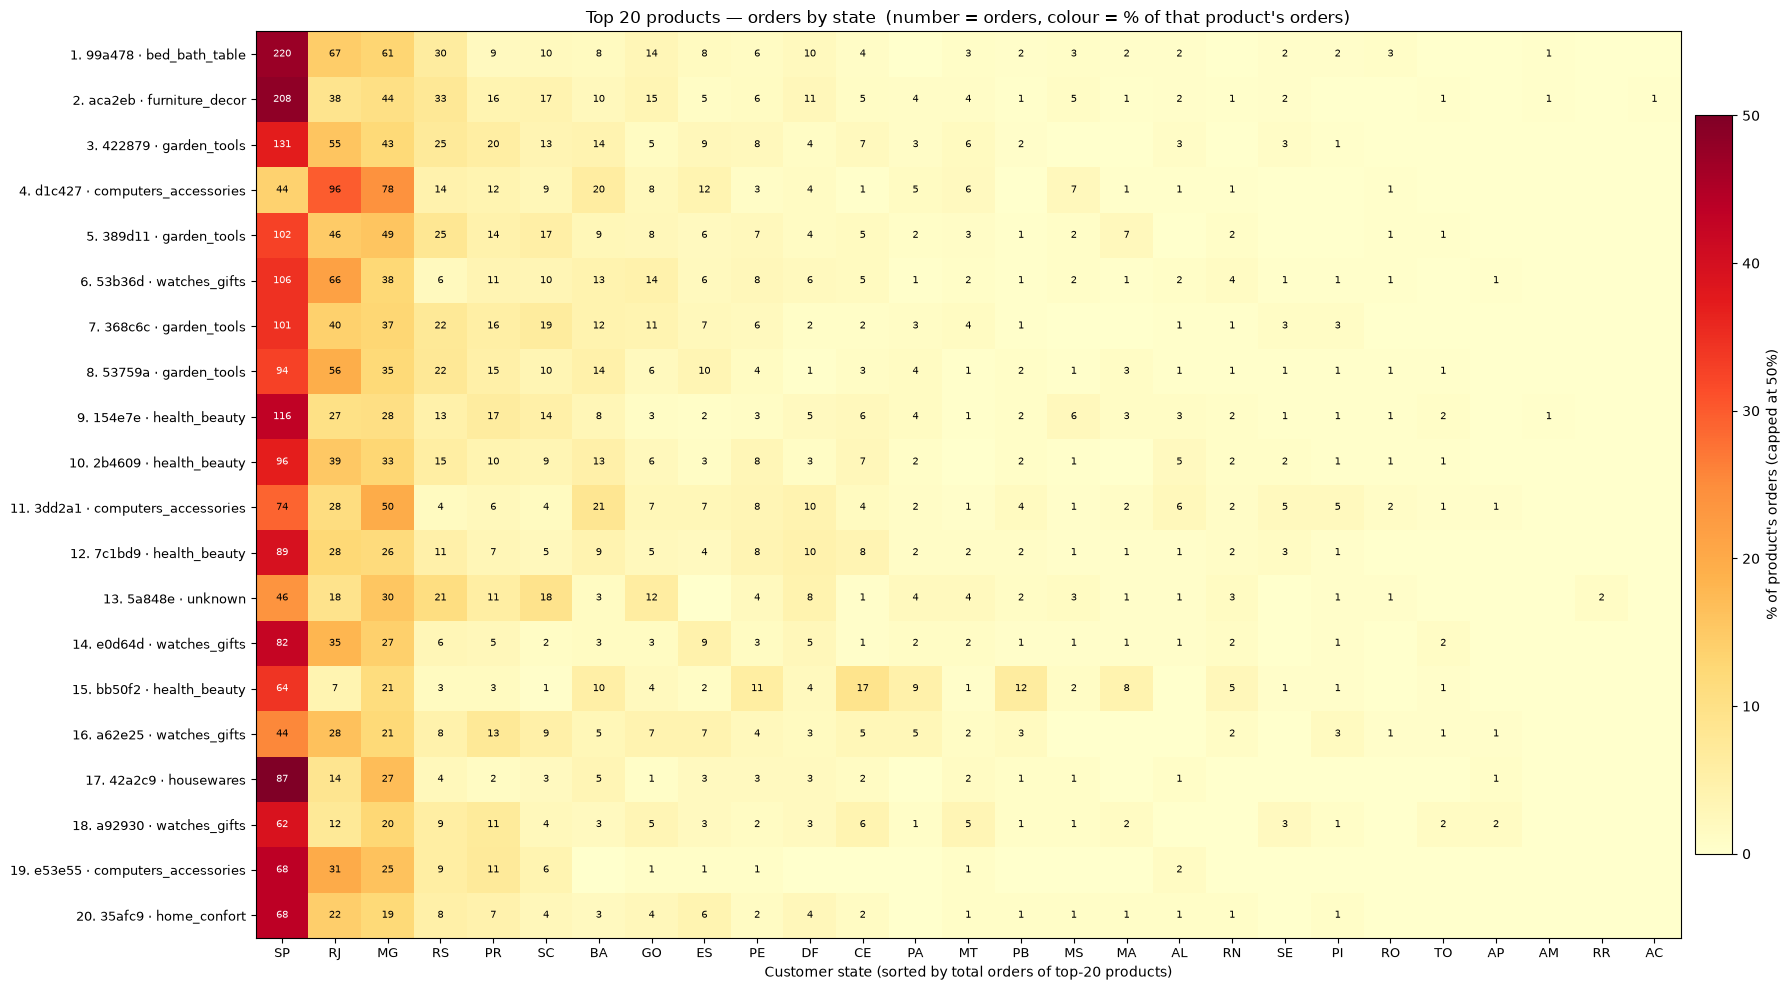

Product-by-state order counts (ps):
customer_state                       SP  RJ  MG  RS  PR  SC  BA  GO  ES  PE  DF  CE  PA  MT  PB  MS  MA  AL  RN  SE  PI  RO  TO  AP  AM  RR  AC
label                                                                                                                                          
1. 99a478 · bed_bath_table          220  67  61  30   9  10   8  14   8   6  10   4   0   3   2   3   2   2   0   2   2   3   0   0   1   0   0
2. aca2eb · furniture_decor         208  38  44  33  16  17  10  15   5   6  11   5   4   4   1   5   1   2   1   2   0   0   1   0   1   0   1
3. 422879 · garden_tools            131  55  43  25  20  13  14   5   9   8   4   7   3   6   2   0   0   3   0   3   1   0   0   0   0   0   0
4. d1c427 · computers_accessories    44  96  78  14  12   9  20   8  12   3   4   1   5   6   0   7   1   1   1   0   0   1   0   0   0   0   0
5. 389d11 · garden_tools            102  46  49  25  14  17   9   8   6   7   4   5   2   3   1   2 

In [35]:
# State-wise top-20 order heatmap: counts as labels, product share as colour.
fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(share.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=50)

ax.set_xticks(np.arange(len(ps.columns)))
ax.set_xticklabels(ps.columns, fontsize=9)
ax.set_yticks(np.arange(len(ps.index)))
ax.set_yticklabels(ps.index, fontsize=9)
ax.set_xlabel("Customer state (sorted by total orders of top-20 products)")
ax.set_title(
    "Top 20 products — orders by state  (number = orders, colour = % of that product's orders)"
)

for row_index in range(ps.shape[0]):
    for column_index in range(ps.shape[1]):
        order_count = int(ps.iat[row_index, column_index])
        if order_count > 0:
            text_color = "white" if share.iat[row_index, column_index] > 30 else "black"
            ax.text(
                column_index,
                row_index,
                str(order_count),
                ha="center",
                va="center",
                color=text_color,
                fontsize=7,
            )

colorbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
colorbar.set_label("% of product's orders (capped at 50%)")
plt.tight_layout()

image_dir = Path.cwd() / "Images"
image_dir.mkdir(parents=True, exist_ok=True)
heatmap_path = image_dir / "top20_statewise_heatmap.png"
fig.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()

print("Product-by-state order counts (ps):")
print(ps.to_string())
state_order_totals = ps.sum(axis=0)
state_order_percent = state_order_totals.div(state_order_totals.sum()).mul(100)
print("\nEach state's share of all top-20 product orders (%):")
print(state_order_percent.to_string(float_format=lambda value: f"{value:.1f}%"))
print("\nSP share for each product, sorted ascending (%):")
print(share["SP"].sort_values().to_string(float_format=lambda value: f"{value:.1f}%"))
print(f"\nSaved heatmap: {heatmap_path}")

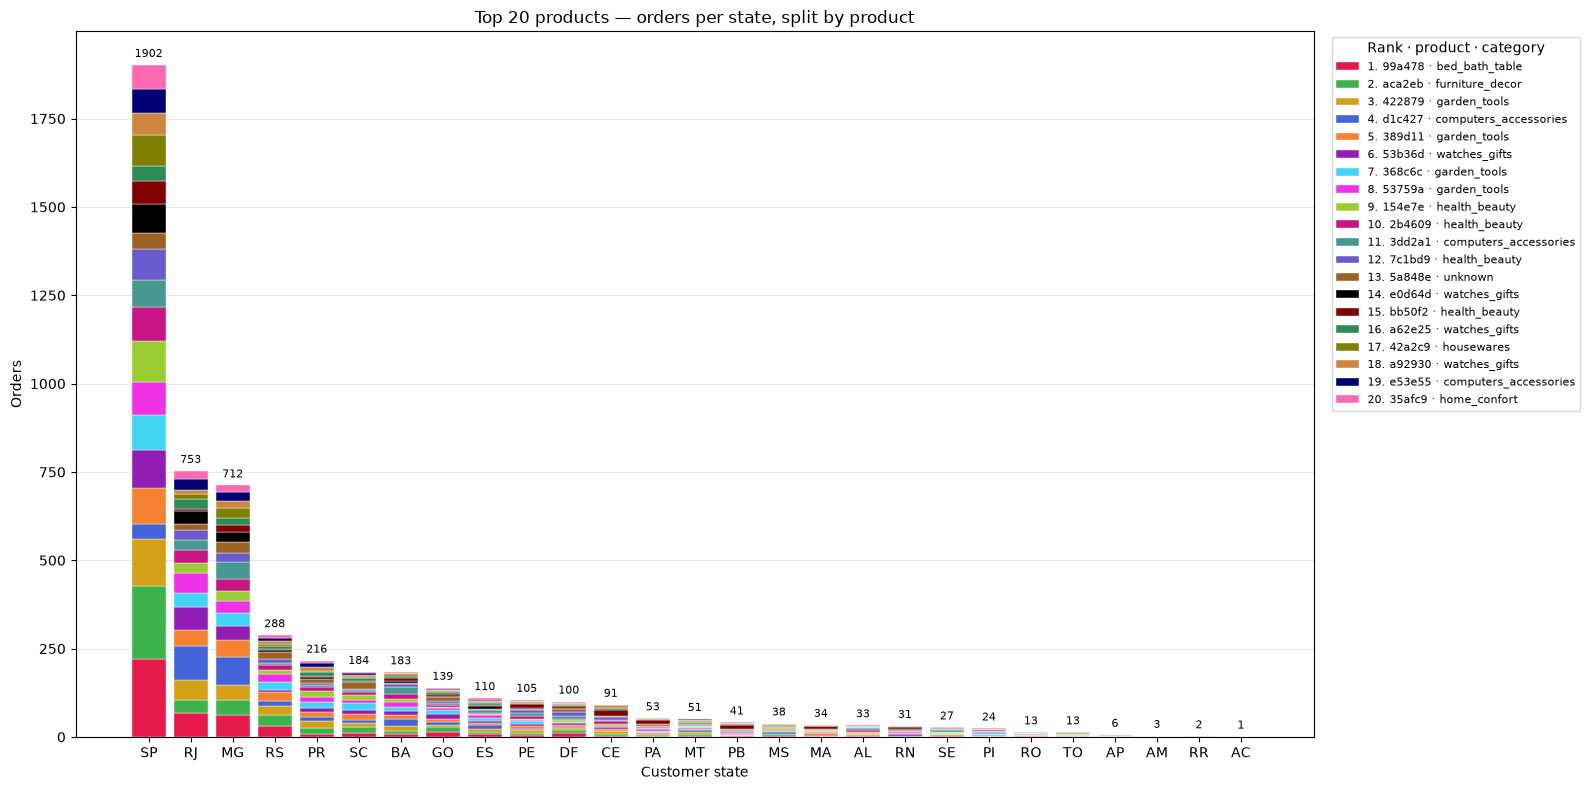

State totals for top-20 products, sorted descending:
customer_state
SP    1902
RJ     753
MG     712
RS     288
PR     216
SC     184
BA     183
GO     139
ES     110
PE     105
DF     100
CE      91
PA      53
MT      51
PB      41
MS      38
MA      34
AL      33
RN      31
SE      27
PI      24
RO      13
TO      13
AP       6
AM       3
RR       2
AC       1
Saved stacked bar chart: /Users/dhruv_rai/Desktop/Meesho/top20_statewise_bars.png


In [36]:
# Stack top-20 product orders within each state, preserving product rank order.
product_colors = [
    "#e6194B", "#3cb44b", "#d4a017", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#9acd32", "#c71585",
    "#469990", "#6a5acd", "#9A6324", "#000000", "#800000",
    "#2e8b57", "#808000", "#cd853f", "#000075", "#ff69b4",
]

fig, ax = plt.subplots(figsize=(16, 8))
state_codes = ps.columns.tolist()
x_positions = np.arange(len(state_codes))
bottom = np.zeros(len(state_codes), dtype=int)

for product_index, label in enumerate(ps.index):
    product_orders_by_state = ps.loc[label].to_numpy(dtype=int)
    ax.bar(
        x_positions,
        product_orders_by_state,
        bottom=bottom,
        color=product_colors[product_index],
        edgecolor="white",
        linewidth=0.3,
        label=label,
    )
    bottom += product_orders_by_state

state_totals = ps.sum(axis=0).to_numpy(dtype=int)
for x_position, total in zip(x_positions, state_totals):
    ax.text(
        x_position,
        total + 15,
        str(int(total)),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(state_codes)
ax.set_ylabel("Orders")
ax.set_xlabel("Customer state")
ax.set_title("Top 20 products — orders per state, split by product")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.3)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=8,
    title="Rank · product · category",
)
plt.tight_layout()

bar_chart_path = Path.cwd() / "top20_statewise_bars.png"
fig.savefig(bar_chart_path, dpi=150, bbox_inches="tight")
plt.show()

state_totals = ps.sum(axis=0).sort_values(ascending=False)
print("State totals for top-20 products, sorted descending:")
print(state_totals.to_string())
print(f"Saved stacked bar chart: {bar_chart_path}")

In [37]:
# IBGE 2022 Census population density (people per km²), Table 4714.
population_density_2022 = {
    "AC": 5.06, "AL": 112.38, "AP": 4.69, "AM": 2.53,
    "BA": 24.82, "CE": 57.09, "DF": 489.06, "ES": 83.20,
    "GO": 20.74, "MA": 20.56, "MT": 4.05, "MS": 7.72,
    "MG": 35.02, "PA": 6.52, "PB": 70.39, "PR": 57.42,
    "PE": 92.37, "PI": 12.40, "RJ": 366.97, "RN": 62.44,
    "RS": 38.63, "RO": 6.65, "RR": 2.85, "SC": 79.50,
    "SP": 178.96, "SE": 100.74, "TO": 5.74,
}

# Combine top-20 product-order counts with each state's population density.
state_product_sales = ps.T.copy()
state_product_sales.index.name = "customer_state"
state_product_sales["top20_product_orders"] = state_product_sales.sum(axis=1)
state_product_sales["population_density_people_per_km2_2022"] = (
    state_product_sales.index.map(population_density_2022)
)

missing_density_states = state_product_sales[
    "population_density_people_per_km2_2022"
].isna()
if missing_density_states.any():
    raise KeyError(
        "Population density is missing for states: "
        f"{state_product_sales.index[missing_density_states].tolist()}"
    )

ordered_columns = [
    "top20_product_orders",
    "population_density_people_per_km2_2022",
    *ps.index.tolist(),
]
state_product_sales = state_product_sales[ordered_columns].sort_values(
    "top20_product_orders", ascending=False
)

print("State-wise top-20 product orders and 2022 population density:")
with pd.option_context("display.max_columns", None, "display.width", 2400):
    display(state_product_sales)

State-wise top-20 product orders and 2022 population density:


label,top20_product_orders,population_density_people_per_km2_2022,1. 99a478 · bed_bath_table,2. aca2eb · furniture_decor,3. 422879 · garden_tools,4. d1c427 · computers_accessories,5. 389d11 · garden_tools,6. 53b36d · watches_gifts,7. 368c6c · garden_tools,8. 53759a · garden_tools,9. 154e7e · health_beauty,10. 2b4609 · health_beauty,11. 3dd2a1 · computers_accessories,12. 7c1bd9 · health_beauty,13. 5a848e · unknown,14. e0d64d · watches_gifts,15. bb50f2 · health_beauty,16. a62e25 · watches_gifts,17. 42a2c9 · housewares,18. a92930 · watches_gifts,19. e53e55 · computers_accessories,20. 35afc9 · home_confort
customer_state,,,,,,,,,,,,,,,,,,,,,,
SP,1902,178.96,220,208,131,44,102,106,101,94,116,96,74,89,46,82,64,44,87,62,68,68
RJ,753,366.97,67,38,55,96,46,66,40,56,27,39,28,28,18,35,7,28,14,12,31,22
MG,712,35.02,61,44,43,78,49,38,37,35,28,33,50,26,30,27,21,21,27,20,25,19
RS,288,38.63,30,33,25,14,25,6,22,22,13,15,4,11,21,6,3,8,4,9,9,8
PR,216,57.42,9,16,20,12,14,11,16,15,17,10,6,7,11,5,3,13,2,11,11,7
SC,184,79.50,10,17,13,9,17,10,19,10,14,9,4,5,18,2,1,9,3,4,6,4
BA,183,24.82,8,10,14,20,9,13,12,14,8,13,21,9,3,3,10,5,5,3,0,3
GO,139,20.74,14,15,5,8,8,14,11,6,3,6,7,5,12,3,4,7,1,5,1,4
ES,110,83.20,8,5,9,12,6,6,7,10,2,3,7,4,0,9,2,7,3,3,1,6


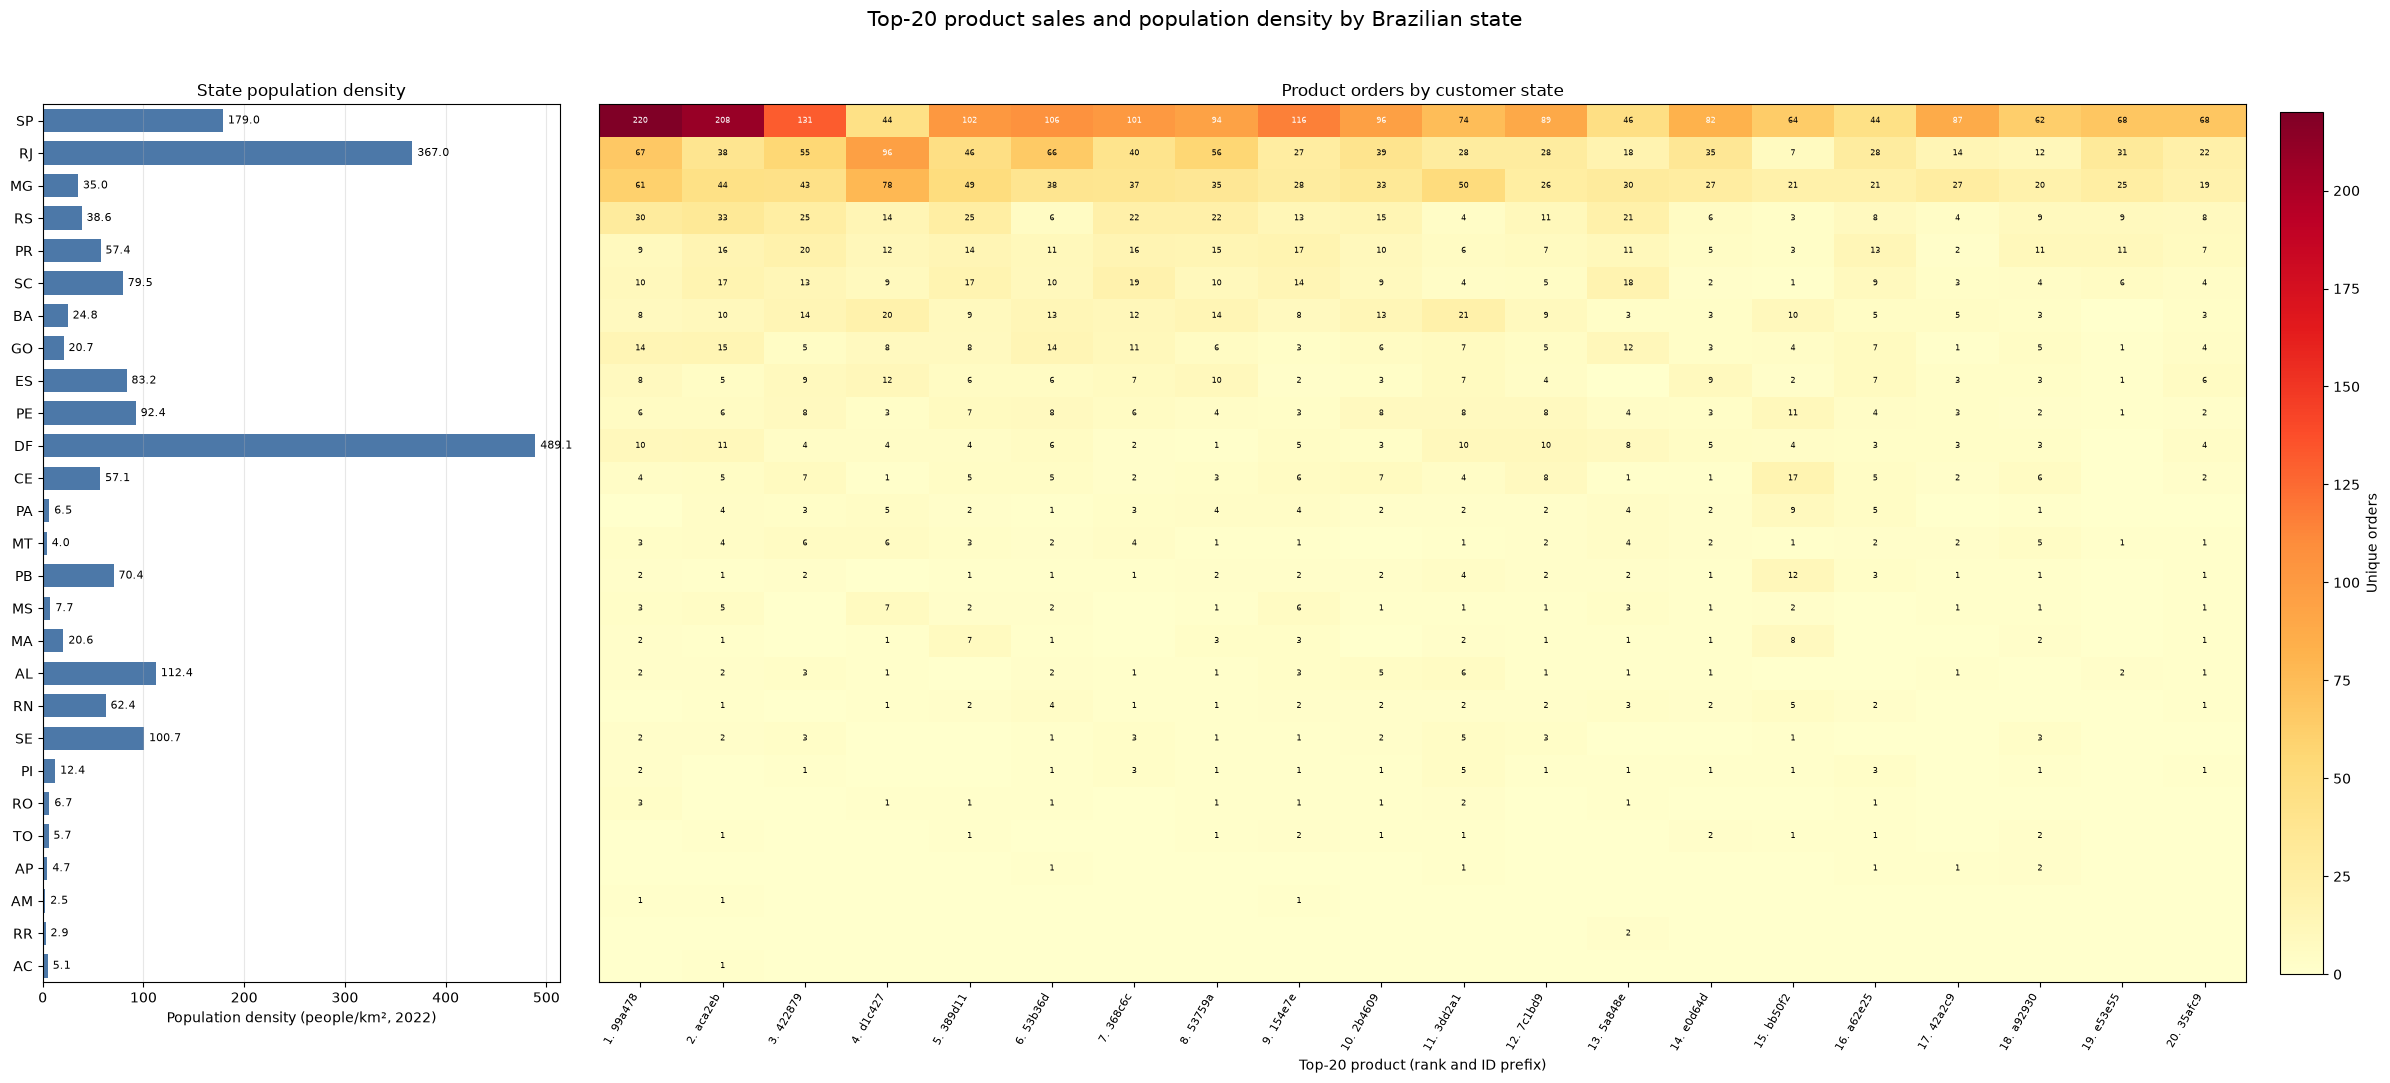

Restored state sales/population density chart: /Users/dhruv_rai/Desktop/Meesho/Images/top20_state_sales_population_density.png


In [38]:
# Compare state population density with the top-20 product order mix.
product_labels_for_plot = top_20["label"].tolist()
state_labels_for_plot = state_product_sales.index.tolist()
product_order_matrix = state_product_sales[product_labels_for_plot].to_numpy()
state_density_values = state_product_sales[
    "population_density_people_per_km2_2022"
].to_numpy()
y_positions = np.arange(len(state_labels_for_plot))

fig_state_comparison, (ax_density, ax_products) = plt.subplots(
    1,
    2,
    figsize=(24, 11),
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 4]},
)

bars = ax_density.barh(
    y_positions,
    state_density_values,
    color="#4C78A8",
    height=0.72,
)
ax_density.set_yticks(y_positions)
ax_density.set_yticklabels(state_labels_for_plot)
ax_density.invert_yaxis()
ax_density.set_xlabel("Population density (people/km², 2022)")
ax_density.set_title("State population density")
ax_density.grid(axis="x", alpha=0.3)
for density_bar, density in zip(bars, state_density_values):
    ax_density.text(
        density_bar.get_width() + max(state_density_values) * 0.01,
        density_bar.get_y() + density_bar.get_height() / 2,
        f"{density:.1f}",
        va="center",
        fontsize=8,
    )

sales_image = ax_products.imshow(
    product_order_matrix,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
ax_products.set_yticks(y_positions)
ax_products.tick_params(axis="y", left=False, labelleft=False)
ax_products.set_xticks(np.arange(len(product_labels_for_plot)))
ax_products.set_xticklabels(
    [f"{row.rank}. {row.product_id[:6]}" for row in top_20.itertuples()],
    rotation=60,
    ha="right",
    fontsize=8,
)
ax_products.set_xlabel("Top-20 product (rank and ID prefix)")
ax_products.set_title("Product orders by customer state")

for row_index in range(product_order_matrix.shape[0]):
    for column_index in range(product_order_matrix.shape[1]):
        order_count = int(product_order_matrix[row_index, column_index])
        if order_count:
            ax_products.text(
                column_index,
                row_index,
                str(order_count),
                ha="center",
                va="center",
                fontsize=6,
                color="white" if order_count >= 80 else "black",
            )

fig_state_comparison.colorbar(
    sales_image,
    ax=ax_products,
    fraction=0.025,
    pad=0.02,
    label="Unique orders",
)
fig_state_comparison.suptitle(
    "Top-20 product sales and population density by Brazilian state",
    fontsize=15,
)
fig_state_comparison.tight_layout(rect=[0, 0, 1, 0.96])
state_comparison_path = Path.cwd() / "Images" / "top20_state_sales_population_density.png"
fig_state_comparison.savefig(state_comparison_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Restored state sales/population density chart: {state_comparison_path}")

## Plot the sell distribution of top 20 SKUs accross a paricular time period

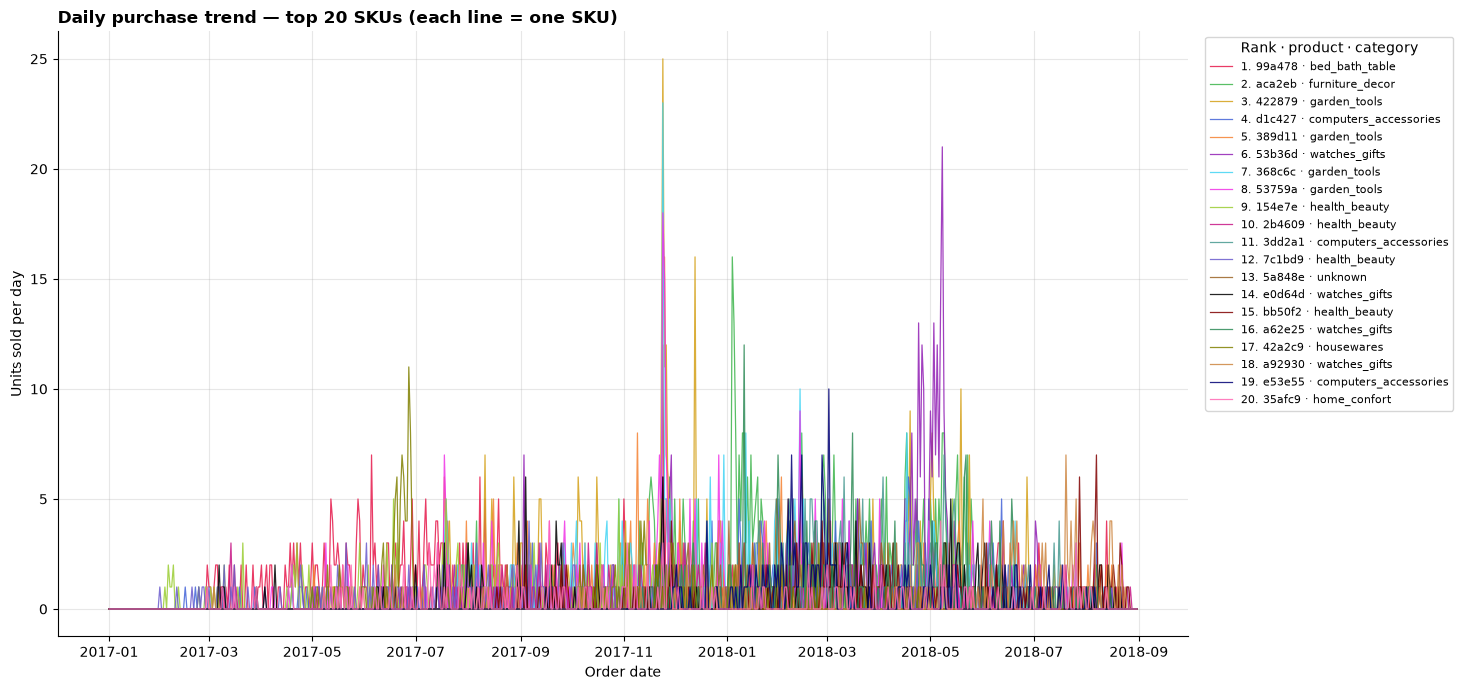

Top-20 units checked: 5,867
SKU 2 peak: 16 units on 2018-01-04
Highest combined day: 121 units on 2017-11-24


In [43]:
# Load order-level product rows and rank the top 20 SKUs.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master = pd.read_csv("olist_master_dataset.csv", parse_dates=["order_purchase_timestamp"])
top20_daily_skus = (
    master.dropna(subset=["product_id"])
    .groupby(["product_id", "product_category_name_english"], dropna=False)
    .agg(
        unique_orders=("order_id", "nunique"),
        order_line_count=("order_id", "size"),
    )
    .reset_index()
    .sort_values(
        ["unique_orders", "order_line_count"],
        ascending=[False, False],
        kind="stable",
    )
    .head(20)
    .reset_index(drop=True)
)
top20_daily_skus["label"] = [
    f"{rank}. {row.product_id[:6]} · "
    f"{row.product_category_name_english if pd.notna(row.product_category_name_english) else 'unknown'}"
    for rank, row in enumerate(top20_daily_skus.itertuples(), start=1)
]

# Build daily unit counts, retaining zero-sale dates in the requested range.
sub = master.loc[master["product_id"].isin(top20_daily_skus["product_id"])].copy()
sub["date"] = sub["order_purchase_timestamp"].dt.normalize()
days = pd.date_range("2017-01-01", "2018-08-31", freq="D")
daily = (
    sub.groupby(["product_id", "date"])
    .size()
    .unstack("date", fill_value=0)
    .reindex(index=top20_daily_skus["product_id"], columns=days, fill_value=0)
)
daily.index = top20_daily_skus["label"]

assert int(daily.to_numpy().sum()) == 5867, "Unexpected total units for the top 20 SKUs"
sku2_peak = daily.iloc[1].max()
sku2_peak_date = daily.columns[daily.iloc[1].to_numpy().argmax()]
assert int(sku2_peak) == 16 and sku2_peak_date == pd.Timestamp("2018-01-04")

# Plot each top SKU's daily units as a separate line.
colors = [
    "#e6194B", "#3cb44b", "#d4a017", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#9acd32", "#c71585",
    "#469990", "#6a5acd", "#9A6324", "#000000", "#800000",
    "#2e8b57", "#808000", "#cd853f", "#000075", "#ff69b4",
]
fig, ax = plt.subplots(figsize=(18, 7))
for index, label in enumerate(daily.index):
    ax.plot(days, daily.loc[label].to_numpy(), color=colors[index], linewidth=0.9, alpha=0.85, label=label)

ax.set_xlabel("Order date")
ax.set_ylabel("Units sold per day")
ax.set_title("Daily purchase trend — top 20 SKUs (each line = one SKU)", loc="left", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=8,
    title="Rank · product · category",
)
plt.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig("top20_daily_trend.png", dpi=150, bbox_inches="tight")
plt.show()

all_sku_daily_totals = daily.sum(axis=0)
highest_day = all_sku_daily_totals.idxmax()
highest_day_units = int(all_sku_daily_totals.max())
print(f"Top-20 units checked: {int(daily.to_numpy().sum()):,}")
print(f"SKU 2 peak: {int(sku2_peak)} units on {sku2_peak_date:%Y-%m-%d}")
print(f"Highest combined day: {highest_day_units} units on {highest_day:%Y-%m-%d}")

## Plot the sell distribution of top 1 SKU accross a paricular time period

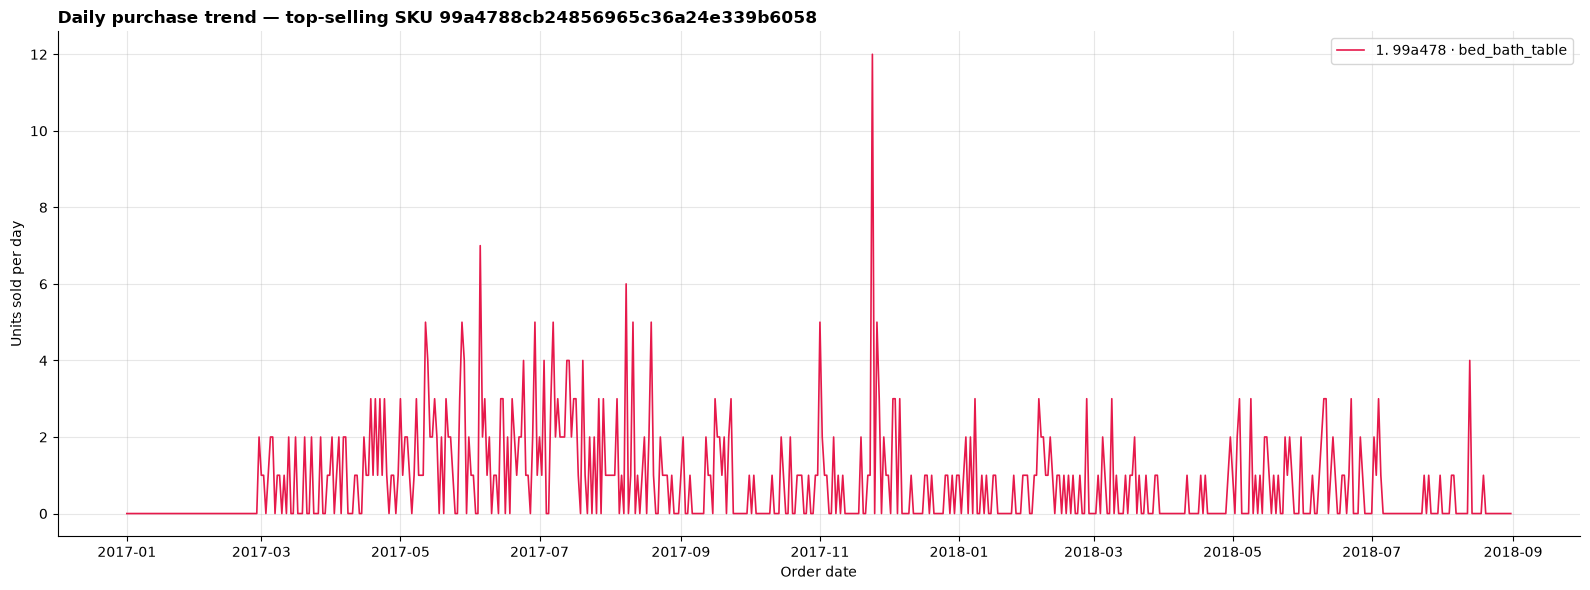

Top-selling SKU: 99a4788cb24856965c36a24e339b6058 (1. 99a478 · bed_bath_table)


In [44]:
# Plot the daily sales trend for the best-selling SKU only.
top_sku_label = top20_daily_skus.loc[0, "label"]
top_sku_product_id = top20_daily_skus.loc[0, "product_id"]
top_sku_daily_units = daily.loc[top_sku_label]

fig_top_sku, ax_top_sku = plt.subplots(figsize=(16, 6))
ax_top_sku.plot(
    days,
    top_sku_daily_units.to_numpy(),
    color=colors[0],
    linewidth=1.2,
    label=top_sku_label,
)
ax_top_sku.set_xlabel("Order date")
ax_top_sku.set_ylabel("Units sold per day")
ax_top_sku.set_title(f"Daily purchase trend — top-selling SKU {top_sku_product_id}", loc="left", fontweight="bold")
ax_top_sku.grid(True, alpha=0.3)
ax_top_sku.spines["top"].set_visible(False)
ax_top_sku.spines["right"].set_visible(False)
ax_top_sku.legend()
plt.tight_layout()
fig_top_sku.savefig("top1_daily_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top-selling SKU: {top_sku_product_id} ({top_sku_label})")

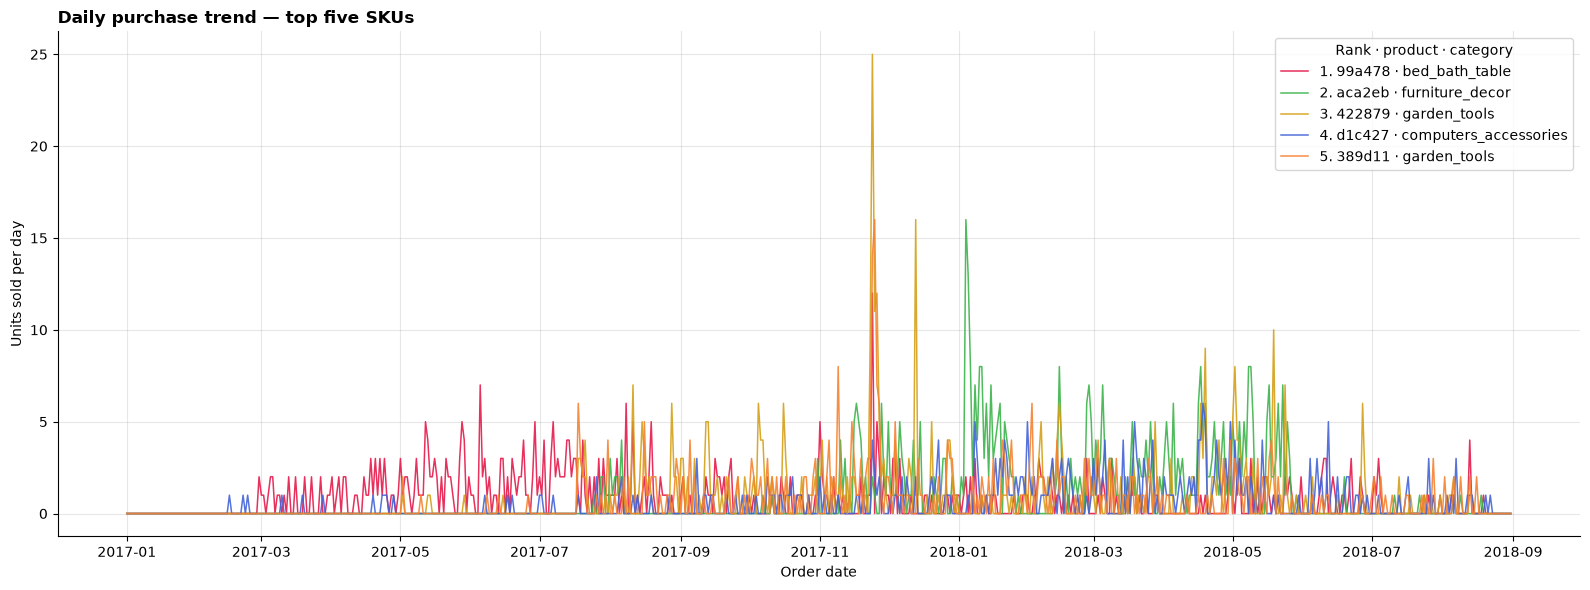

Plotted top five SKUs:
                      product_id                             label  unique_orders
99a4788cb24856965c36a24e339b6058        1. 99a478 · bed_bath_table            467
aca2eb7d00ea1a7b8ebd4e68314663af       2. aca2eb · furniture_decor            431
422879e10f46682990de24d770e7f83d          3. 422879 · garden_tools            352
d1c427060a0f73f6b889a5c7c61f2ac4 4. d1c427 · computers_accessories            323
389d119b48cf3043d311335e499d9c6b          5. 389d11 · garden_tools            311


In [45]:
# Compare daily unit sales for the top five SKUs on one chart.
top5_daily_skus = top20_daily_skus.head(5)
fig_top5, ax_top5 = plt.subplots(figsize=(16, 6))

for index, sku in top5_daily_skus.iterrows():
    label = sku["label"]
    ax_top5.plot(
        days,
        daily.loc[label].to_numpy(),
        color=colors[index],
        linewidth=1.1,
        alpha=0.9,
        label=label,
    )

ax_top5.set_xlabel("Order date")
ax_top5.set_ylabel("Units sold per day")
ax_top5.set_title("Daily purchase trend — top five SKUs", loc="left", fontweight="bold")
ax_top5.grid(True, alpha=0.3)
ax_top5.spines["top"].set_visible(False)
ax_top5.spines["right"].set_visible(False)
ax_top5.legend(title="Rank · product · category")
plt.tight_layout()
fig_top5.savefig("top5_daily_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plotted top five SKUs:")
print(top5_daily_skus[["product_id", "label", "unique_orders"]].to_string(index=False))

### Load and Clean Input Data

In [48]:
# Load all rows, then keep a coordinate-complete copy for geographic analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_raw = pd.read_csv(
    "olist_master_dataset.csv",
    parse_dates=["order_purchase_timestamp"],
)
master = master_raw.dropna(subset=["customer_lat", "customer_lng"]).copy()
print(f"Loaded {len(master_raw):,} rows; {len(master):,} have customer coordinates")

Loaded 113,425 rows; 113,110 have customer coordinates


### Reusable SKU Catchment Analysis

In [49]:
# Build zip summaries and the three-panel demand map for one SKU.
def plot_sku_heat(product_id, hub_lat, hub_lng, radius_km=100, top_n=15, out_png=None):
    earth_radius_km = 6371
    sku_rows = master.loc[master["product_id"].eq(product_id)].copy()
    total_units = int(master_raw["product_id"].eq(product_id).sum())
    if sku_rows.empty:
        raise ValueError(f"No coordinate-valid orders found for product_id={product_id}")

    sku_category_values = sku_rows["product_category_name_english"].dropna()
    category = sku_category_values.iloc[0] if not sku_category_values.empty else "unknown"
    sku_identity = "#1" if product_id == PRODUCT_ID else product_id[:8]

    # Project all valid customer points around the selected hub.
    geographic_rows = master.copy()
    geographic_rows["x_km"] = (
        earth_radius_km
        * np.radians(geographic_rows["customer_lng"] - hub_lng)
        * np.cos(np.radians(hub_lat))
    )
    geographic_rows["y_km"] = earth_radius_km * np.radians(
        geographic_rows["customer_lat"] - hub_lat
    )
    geographic_rows["dist_km"] = np.sqrt(
        geographic_rows["x_km"] ** 2 + geographic_rows["y_km"] ** 2
    )
    all_near = geographic_rows.loc[geographic_rows["dist_km"].le(radius_km)].copy()
    near = all_near.loc[all_near["product_id"].eq(product_id)].copy()
    if near.empty:
        raise ValueError(f"No units of product_id={product_id} fall within {radius_km} km")

    # Create five-digit zip summaries and three-digit sub-region summaries.
    near["zip_number"] = pd.to_numeric(
        near["customer_zip_code_prefix"], errors="coerce"
    )
    near["zip5"] = (
        near["zip_number"].astype("Int64").astype("string").str.zfill(5)
    )
    zip_counts = (
        near.groupby("zip5", dropna=False)
        .agg(
            units=("product_id", "size"),
            mean_x_km=("x_km", "mean"),
            mean_y_km=("y_km", "mean"),
            mean_dist_km=("dist_km", "mean"),
            city=("customer_city", "first"),
        )
        .reset_index()
        .sort_values("units", ascending=False)
        .reset_index(drop=True)
    )

    zip3_rows = near.dropna(subset=["zip_number"]).copy()
    zip3_rows["zip3"] = (zip3_rows["zip_number"] // 100).astype(int)

    def most_common_city(city_values):
        city_modes = city_values.dropna().astype(str).mode()
        return city_modes.iloc[0] if not city_modes.empty else "Unknown"

    zip3_counts = (
        zip3_rows.groupby("zip3")
        .agg(
            units=("product_id", "size"),
            mean_dist_km=("dist_km", "mean"),
            city=("customer_city", most_common_city),
        )
        .reset_index()
        .sort_values("units", ascending=False)
        .reset_index(drop=True)
    )
    zip3_counts["zip3_label"] = zip3_counts["zip3"].map(lambda value: f"{value:03d}xx")

    if product_id == PRODUCT_ID:
        zip5_path = "sku1_nearby_zip_counts.csv"
        zip3_path = "sku1_nearby_zip3_counts.csv"
    else:
        zip5_path = f"sku_{product_id[:8]}_nearby_zip_counts.csv"
        zip3_path = f"sku_{product_id[:8]}_nearby_zip3_counts.csv"
    zip_counts.to_csv(zip5_path, index=False)
    zip3_counts.to_csv(zip3_path, index=False)

    nearby_units = len(near)
    zip_prefix_count = near["customer_zip_code_prefix"].nunique()
    print(
        f"{product_id}: {total_units:,} total units; {nearby_units:,} within "
        f"{radius_km} km; {zip_prefix_count:,} unique zip prefixes"
    )
    if out_png is None:
        out_png = "sku1_nearby_zip_heatmap.png" if product_id == PRODUCT_ID else f"sku_{product_id[:8]}_nearby_zip_heatmap.png"
        show_figure = True
    else:
        show_figure = False

    top_zip3 = zip3_counts.head(top_n).copy()
    near["purchase_month"] = near["order_purchase_timestamp"].dt.to_period("M")
    month_values = near["purchase_month"].dropna()
    if month_values.empty:
        raise ValueError(f"No valid purchase dates found for product_id={product_id}")
    months = pd.period_range(month_values.min(), month_values.max(), freq="M")
    monthly_counts = (
        zip3_rows.assign(
            purchase_month=zip3_rows["order_purchase_timestamp"].dt.to_period("M")
        )
        .dropna(subset=["purchase_month"])
        .groupby(["zip3", "purchase_month"])
        .size()
        .unstack("purchase_month", fill_value=0)
        .reindex(index=top_zip3["zip3"], columns=months, fill_value=0)
    )

    print(f"Saved zip tables: {zip5_path}, {zip3_path}")
    if show_figure:
        print(f"Top {top_n} three-digit zip areas:")
        display(zip3_counts.head(top_n))

    # Arrange the map, zip-by-month heatmap, and distance bands in one row.
    fig = plt.figure(figsize=(17, 7.6))
    outer = fig.add_gridspec(
        1, 3, width_ratios=[1.1, 1.25, 0.75], wspace=0.55
    )
    map_grid = outer[0, 0].subgridspec(
        2, 1, height_ratios=[1, 0.07], hspace=0.28
    )
    ax_map = fig.add_subplot(map_grid[0, 0])
    cax_map = fig.add_subplot(map_grid[1, 0])
    heat_grid = outer[0, 1].subgridspec(
        1, 3, width_ratios=[1, 0.16, 0.06], wspace=0.04
    )
    ax_heat = fig.add_subplot(heat_grid[0, 0])
    ax_totals = fig.add_subplot(heat_grid[0, 1], sharey=ax_heat)
    cax_heat = fig.add_subplot(heat_grid[0, 2])
    ax_bands = fig.add_subplot(outer[0, 2])

    # Panel A: all nearby buyers, SKU density, distance rings, and hub.
    ax_map.scatter(
        all_near["x_km"], all_near["y_km"],
        s=1, alpha=0.4, color="#d9d9d9",
        label="All Olist buyers (any product)", zorder=1,
    )
    hexes = ax_map.hexbin(
        near["x_km"], near["y_km"],
        gridsize=28,
        extent=(-radius_km, radius_km, -radius_km, radius_km),
        mincnt=1,
        cmap="YlOrRd",
        edgecolors="white",
        linewidths=0.3,
        zorder=2,
    )
    for ring, linestyle in ((25, ":"), (50, "--"), (radius_km, "-")):
        ax_map.add_patch(
            plt.Circle(
                (0, 0), ring, fill=False, color="#555555",
                linestyle=linestyle, linewidth=0.9, zorder=3,
            )
        )
        label_radius = ring + 2
        label_offset = label_radius / np.sqrt(2)
        ax_map.text(
            label_offset, label_offset, f"{ring} km",
            color="#444444", fontsize=7, ha="left", va="bottom", zorder=4,
        )
    ax_map.scatter(
        [0], [0], marker="*", s=130, color="#1f4e9e",
        edgecolor="white", linewidth=0.6, zorder=5,
    )
    ax_map.text(
        0.03, 0.97, "★ = hub (São Paulo centre)",
        transform=ax_map.transAxes, ha="left", va="top", fontsize=8,
    )
    ax_map.legend(loc="lower left", frameon=False, fontsize=7)
    ax_map.set_aspect("equal")
    ax_map.set_xlim(-radius_km - 5, radius_km + 5)
    ax_map.set_ylim(-radius_km - 5, radius_km + 5)
    ax_map.set_xlabel("km east of hub")
    ax_map.set_ylabel("km north of hub")
    ax_map.set_title(
        f"A. Where SKU {sku_identity} sells within {radius_km} km\n"
        f"{nearby_units:,} units, {zip_prefix_count:,} zip prefixes",
        fontsize=9,
    )
    map_colorbar = fig.colorbar(hexes, cax=cax_map, orientation="horizontal")
    map_colorbar.set_label("Units of this SKU per ~7 km cell", fontsize=8)

    # Panel B: monthly orders for the highest-volume zip3 areas.
    heat_values = monthly_counts.to_numpy()
    heat_image = ax_heat.imshow(
        heat_values, aspect="auto", vmin=0, cmap="YlOrRd", interpolation="nearest"
    )
    zip3_labels = [
        f"{int(row.zip3):03d}xx · {str(row.city).title()[:20]} · {row.mean_dist_km:.0f} km"
        for row in top_zip3.itertuples()
    ]
    ax_heat.set_yticks(np.arange(len(zip3_labels)))
    ax_heat.set_yticklabels(zip3_labels, fontsize=7)
    ax_heat.set_xticks(np.arange(len(months)))
    ax_heat.set_xticklabels(
        [month.strftime("%b %y") for month in months],
        rotation=90,
        fontsize=7,
    )
    ax_heat.set_title(
        f"B. Top-{top_n} nearby zip areas (first 3 digits) × month\n"
        "(when each pocket buys)",
        fontsize=9,
    )
    max_month_count = int(heat_values.max()) if heat_values.size else 0
    for row_index in range(heat_values.shape[0]):
        for column_index in range(heat_values.shape[1]):
            cell_units = int(heat_values[row_index, column_index])
            if cell_units:
                text_color = "white" if cell_units >= 0.6 * max_month_count else "#222222"
                ax_heat.text(
                    column_index, row_index, str(cell_units),
                    ha="center", va="center", color=text_color, fontsize=6,
                )

    ax_totals.set_xlim(0, 1)
    ax_totals.set_ylim(ax_heat.get_ylim())
    ax_totals.axis("off")
    ax_totals.text(0.5, -0.8, "Total", ha="center", va="bottom", fontsize=8, fontweight="bold")
    for row_index, row_total in enumerate(heat_values.sum(axis=1)):
        ax_totals.text(
            0.5, row_index, f"{int(row_total)}",
            ha="center", va="center", fontsize=8, fontweight="bold",
        )
    heat_colorbar = fig.colorbar(heat_image, cax=cax_heat)
    heat_colorbar.set_label("Units per month", fontsize=7, labelpad=7)

    # Panel C: sold units and area-normalized rate by distance band.
    band_edges = [(0, 10), (10, 25), (25, 50), (50, 75), (75, radius_km)]
    band_labels = [f"{inner}–{outer} km" for inner, outer in band_edges]
    band_units = []
    band_rates = []
    for inner, outer_radius in band_edges:
        if outer_radius == radius_km:
            in_band = near["dist_km"].ge(inner) & near["dist_km"].le(outer_radius)
        else:
            in_band = near["dist_km"].ge(inner) & near["dist_km"].lt(outer_radius)
        units = int(in_band.sum())
        area_km2 = np.pi * (outer_radius**2 - inner**2)
        band_units.append(units)
        band_rates.append(units / area_km2 * 1000 if area_km2 > 0 else 0)

    y_band_positions = np.arange(len(band_labels))
    ax_bands.barh(y_band_positions, band_units, color="#e8743b", height=0.68)
    ax_bands.set_yticks(y_band_positions)
    ax_bands.set_yticklabels(band_labels, fontsize=8)
    ax_bands.invert_yaxis()
    max_band_units = max(band_units) if band_units else 0
    ax_bands.set_xlim(0, max(1, max_band_units * 1.8))
    for y_position, units, rate in zip(y_band_positions, band_units, band_rates):
        ax_bands.text(
            units + max(1, max_band_units * 0.03), y_position,
            f"{units}  ({rate:.1f}/1,000 km²)",
            va="center", fontsize=7,
        )
    within_25 = (near["dist_km"].le(25).sum() / nearby_units) * 100
    within_50 = (near["dist_km"].le(50).sum() / nearby_units) * 100
    ax_bands.set_title(
        f"C. Units by distance band\n{within_25:.0f}% within 25 km, {within_50:.0f}% within 50 km",
        fontsize=9,
    )
    ax_bands.set_xlabel(f"Units of {sku_identity}", fontsize=8)
    ax_bands.set_ylabel("Distance from hub (km)", fontsize=8)

    # Finalize title, save the PNG, and show only the requested single-SKU call.
    for axis in (ax_map, ax_heat, ax_bands):
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
    fig.suptitle(
        f"SKU {sku_identity} ({category}, {product_id[:8]}…) — demand around a São Paulo hub by zip prefix",
        x=0.01, y=0.99, ha="left", fontweight="bold", fontsize=12,
    )
    fig.subplots_adjust(top=0.84, bottom=0.20, left=0.07, right=0.98)

    fig_path = out_png or "sku1_nearby_zip_heatmap.png"
    fig.savefig(fig_path, dpi=170, bbox_inches="tight")
    if show_figure:
        plt.show()
    plt.close(fig)
    return near, zip_counts, zip3_counts

## Run SKU #1 and Inspect Nearby Zip Areas

aca2eb7d00ea1a7b8ebd4e68314663af: 527 total units; 216 within 100 km; 158 unique zip prefixes
Saved zip tables: sku1_nearby_zip_counts.csv, sku1_nearby_zip3_counts.csv
Top 15 three-digit zip areas:


,zip3,units,mean_dist_km,city,zip3_label
0,132,12,56.845197,jundiai,132xx
1,122,9,85.570756,sao jose dos campos,122xx
2,31,9,5.406105,sao paulo,031xx
3,130,7,86.391463,campinas,130xx
4,48,7,21.874447,sao paulo,048xx
5,93,7,23.340447,maua,093xx
6,41,7,5.141474,sao paulo,041xx
7,20,6,5.919771,sao paulo,020xx
8,45,6,8.090963,sao paulo,045xx
9,67,5,25.683472,cotia,067xx


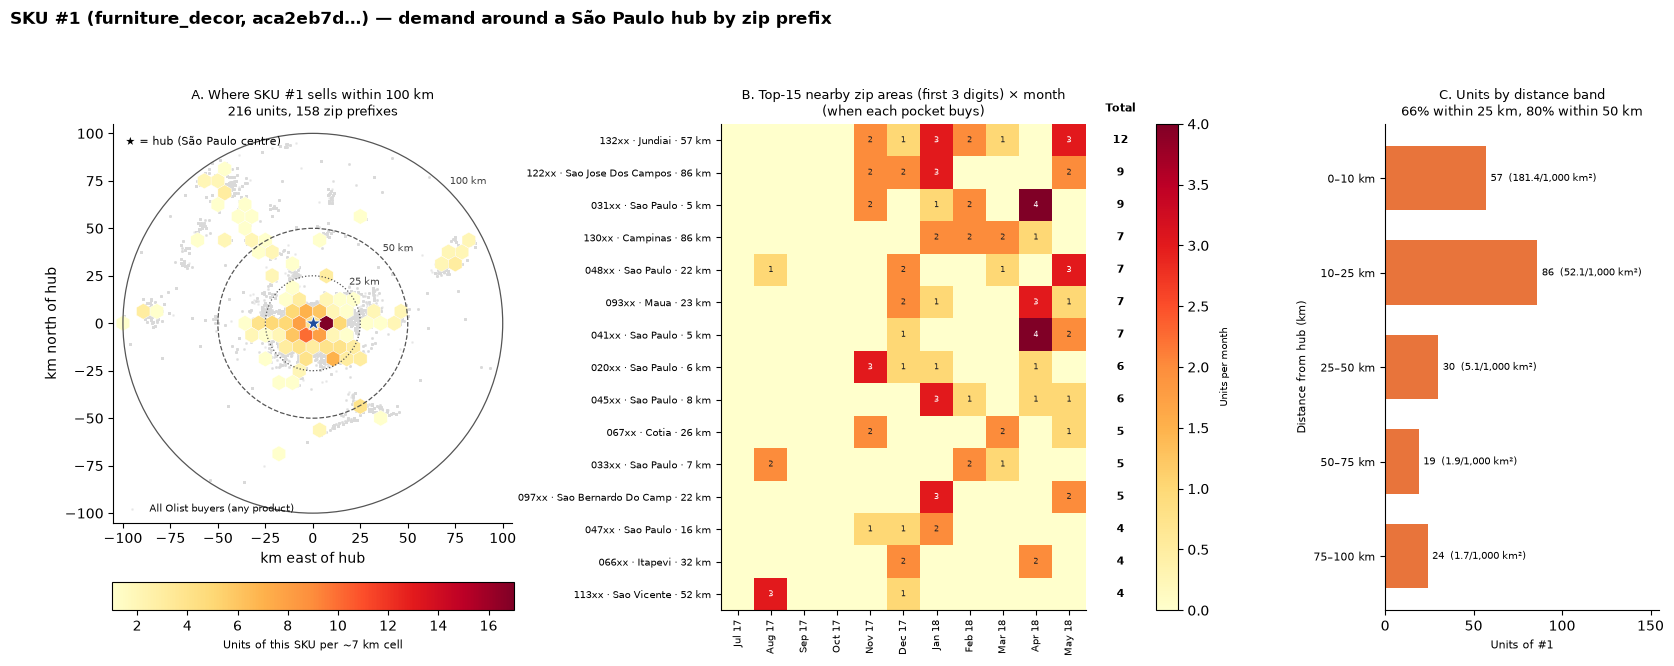

Top nearby 3-digit zip areas:


,zip3,units,mean_dist_km,city,zip3_label
0,132,12,56.845197,jundiai,132xx
1,122,9,85.570756,sao jose dos campos,122xx
2,31,9,5.406105,sao paulo,031xx
3,130,7,86.391463,campinas,130xx
4,48,7,21.874447,sao paulo,048xx
5,93,7,23.340447,maua,093xx
6,41,7,5.141474,sao paulo,041xx
7,20,6,5.919771,sao paulo,020xx
8,45,6,8.090963,sao paulo,045xx
9,67,5,25.683472,cotia,067xx


In [50]:
near_sku1, sku1_zip_counts, sku1_zip3_counts = plot_sku_heat(
    PRODUCT_ID,
    HUB_LAT,
    HUB_LNG,
    radius_km=RADIUS_KM,
    top_n=TOP_N_AREAS,
)
print("Top nearby 3-digit zip areas:")
display(sku1_zip3_counts.head(TOP_N_AREAS))

## Save Maps for the Top 20 SKUs

In [51]:
# Save one map per product, ranked by total units in the full source dataset.
sku_heatmap_dir = Path("sku_zip_heatmaps")
sku_heatmap_dir.mkdir(parents=True, exist_ok=True)
top20_product_ids = master_raw["product_id"].value_counts().head(20).index.tolist()

for rank, product_id in enumerate(top20_product_ids, start=1):
    output_path = sku_heatmap_dir / f"{rank:02d}_{product_id}.png"
    plot_sku_heat(
        product_id,
        HUB_LAT,
        HUB_LNG,
        radius_km=RADIUS_KM,
        top_n=TOP_N_AREAS,
        out_png=output_path,
    )

print(f"Saved {len(top20_product_ids)} SKU maps in {sku_heatmap_dir}/")

aca2eb7d00ea1a7b8ebd4e68314663af: 527 total units; 216 within 100 km; 158 unique zip prefixes
Saved zip tables: sku1_nearby_zip_counts.csv, sku1_nearby_zip3_counts.csv
99a4788cb24856965c36a24e339b6058: 488 total units; 174 within 100 km; 154 unique zip prefixes
Saved zip tables: sku_99a4788c_nearby_zip_counts.csv, sku_99a4788c_nearby_zip3_counts.csv
422879e10f46682990de24d770e7f83d: 484 total units; 122 within 100 km; 82 unique zip prefixes
Saved zip tables: sku_422879e1_nearby_zip_counts.csv, sku_422879e1_nearby_zip3_counts.csv
389d119b48cf3043d311335e499d9c6b: 392 total units; 103 within 100 km; 77 unique zip prefixes
Saved zip tables: sku_389d119b_nearby_zip_counts.csv, sku_389d119b_nearby_zip3_counts.csv
368c6c730842d78016ad823897a372db: 388 total units; 92 within 100 km; 68 unique zip prefixes
Saved zip tables: sku_368c6c73_nearby_zip_counts.csv, sku_368c6c73_nearby_zip3_counts.csv
53759a2ecddad2bb87a079a1f1519f73: 373 total units; 84 within 100 km; 70 unique zip prefixes
Saved zi

## Top-20 SKU Demand Around São Paulo
Set the analysis parameters before preparing the top-20 ZIP-area summaries.

In [52]:
# Parameters for the São Paulo catchment analysis.
DATA = "olist_master_dataset.csv"
HUB_NAME, HUB_LAT, HUB_LNG = "São Paulo", -23.5505, -46.6333
RADIUS_KM = 100
TOP_AREAS = 15
OUT_PNG = "top20_SP_nearby_zip_heatmap.png"

### Load Data and Rank the Top 20 SKUs

In [53]:
# Rank by all sold rows, then remove customers without usable coordinates.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns = [
    "product_id", "order_id", "order_purchase_timestamp",
    "customer_zip_code_prefix", "customer_city", "customer_lat",
    "customer_lng", "product_category_name_english",
]
master_all = pd.read_csv(DATA, usecols=columns, parse_dates=["order_purchase_timestamp"])
top20_ids = master_all["product_id"].value_counts().head(20).index.tolist()
category_by_sku = master_all.groupby("product_id")["product_category_name_english"].first()
top20_skus = pd.DataFrame({"product_id": top20_ids, "rank": np.arange(1, 21)})
top20_skus["category"] = top20_skus["product_id"].map(category_by_sku)
top20_skus["label"] = [
    f"#{rank} {(category if pd.notna(category) else 'uncategorised')[:16]}"
    for rank, category in zip(top20_skus["rank"], top20_skus["category"])
]

master_geo = master_all.dropna(subset=["customer_lat", "customer_lng"]).copy()
print(f"Loaded {len(master_all):,} item rows; {len(master_geo):,} have coordinates")
print("Top-20 SKU IDs:", len(top20_ids))

Loaded 113,425 item rows; 113,110 have coordinates
Top-20 SKU IDs: 20


## Project Coordinates and Select Nearby Buyers

In [54]:
# Project coordinates around the hub and select all/top-20 buyers within the radius.
earth_radius_km = 6371
master_geo["x"] = (
    earth_radius_km
    * np.radians(master_geo["customer_lng"] - HUB_LNG)
    * np.cos(np.radians(HUB_LAT))
)
master_geo["y"] = earth_radius_km * np.radians(master_geo["customer_lat"] - HUB_LAT)
master_geo["dist"] = np.sqrt(master_geo["x"] ** 2 + master_geo["y"] ** 2)

all_near = master_geo.loc[master_geo["dist"].le(RADIUS_KM)].copy()
rank_by_sku = top20_skus.set_index("product_id")["rank"]
near = all_near.loc[all_near["product_id"].isin(top20_ids)].copy()
near["rank"] = near["product_id"].map(rank_by_sku).astype(int)
near["zip_number"] = pd.to_numeric(near["customer_zip_code_prefix"], errors="coerce")
near["zip3"] = (near["zip_number"] // 100).astype("Int64")
near["ym"] = near["order_purchase_timestamp"].dt.to_period("M")

print(f"Top-20 nearby units: {len(near):,}")
print(f"Unique 5-digit zip prefixes: {near['customer_zip_code_prefix'].nunique():,}")
print(f"SKUs present nearby: {near['product_id'].nunique():,}")

Top-20 nearby units: 1,598
Unique 5-digit zip prefixes: 1,057
SKUs present nearby: 20


### Summarize and Save ZIP3 Areas

In [55]:
# Aggregate the nearby sales into three-digit ZIP areas.
def common_city(values):
    city_modes = values.dropna().astype(str).mode()
    return city_modes.iloc[0] if not city_modes.empty else "Unknown"

zip3_summary = (
    near.dropna(subset=["zip3"])
    .groupby("zip3")
    .agg(
        units=("product_id", "size"),
        mean_dist_km=("dist", "mean"),
        city=("customer_city", common_city),
        sku_count=("product_id", "nunique"),
    )
    .reset_index()
    .sort_values(["units", "mean_dist_km"], ascending=[False, True])
    .reset_index(drop=True)
)
zip3_summary["row_label"] = zip3_summary.apply(
    lambda row: (
        f"{int(row['zip3']):03d}xx · {str(row['city']).title()[:17]} "
        f"· {row['mean_dist_km']:.0f} km"
    ),
    axis=1,
)
top_areas = zip3_summary.head(TOP_AREAS)["zip3"].tolist()
top_area_labels = zip3_summary.set_index("zip3")["row_label"].to_dict()
zip3_summary.to_csv("top20_SP_zip3_counts.csv", index=False)

print("Busiest ZIP3 areas:")
print(zip3_summary.head(3)[["row_label", "units", "sku_count"]].to_string(index=False))
print("Saved top20_SP_zip3_counts.csv")

Busiest ZIP3 areas:
                        row_label  units  sku_count
         130xx · Campinas · 85 km     76         18
          132xx · Jundiai · 56 km     68         19
122xx · Sao Jose Dos Camp · 85 km     43         17
Saved top20_SP_zip3_counts.csv


### Build the Five-Panel Demand Figure

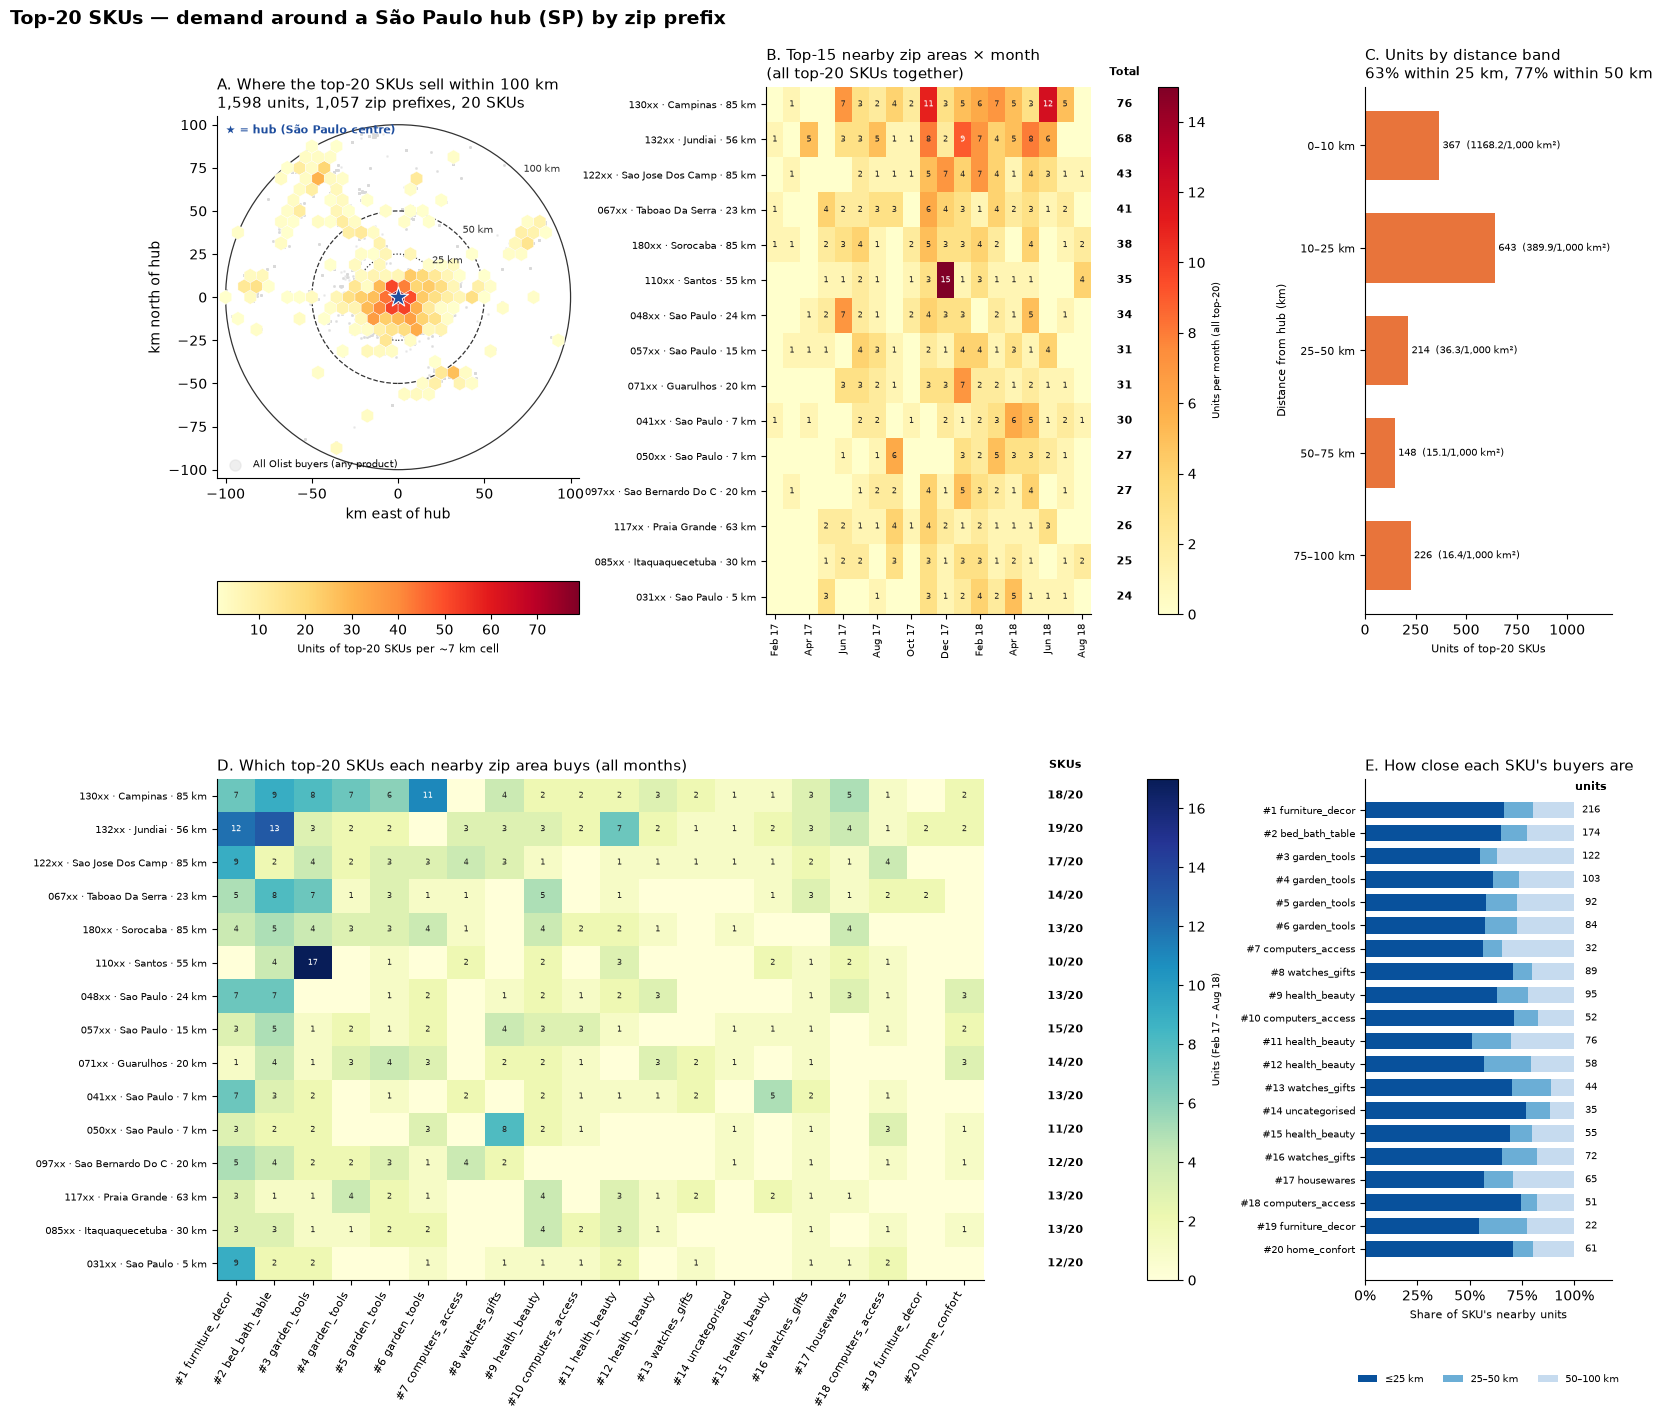

Distance-band units:
distance_band
0–10      367
10–25     643
25–50     214
50–75     148
75–100    226
Within 25 km: 63.2% | within 50 km: 76.6%
Saved per-SKU distance shares to top20_SP_sku_distance_share.csv


In [56]:
# Prepare monthly, ZIP3-by-SKU, distance-band, and per-SKU distance-share tables.
months = pd.period_range(near["ym"].min(), near["ym"].max(), freq="M")
monthly_zip3 = (
    near.dropna(subset=["zip3"])
    .groupby(["zip3", "ym"])
    .size()
    .unstack("ym", fill_value=0)
    .reindex(index=top_areas, columns=months, fill_value=0)
)
zip3_by_sku = (
    near.dropna(subset=["zip3"])
    .groupby(["zip3", "rank"])
    .size()
    .unstack("rank", fill_value=0)
    .reindex(index=top_areas, columns=range(1, 21), fill_value=0)
)

band_edges = [0, 10, 25, 50, 75, RADIUS_KM]
band_labels = ["0–10", "10–25", "25–50", "50–75", "75–100"]
near["distance_band"] = pd.cut(
    near["dist"], bins=band_edges, labels=band_labels, include_lowest=True
)
distance_band_units = (
    near["distance_band"].value_counts(sort=False).reindex(band_labels, fill_value=0)
)

sku_share_rows = []
for sku in top20_skus.itertuples():
    sku_near = near.loc[near["rank"].eq(sku.rank)]
    sku_units = len(sku_near)
    within_25 = int(sku_near["dist"].le(25).sum())
    within_50 = int((sku_near["dist"].le(50)).sum())
    within_100 = sku_units
    sku_share_rows.append({
        "rank": sku.rank,
        "product_id": sku.product_id,
        "label": sku.label,
        "units": sku_units,
        "share_0_25_km": within_25 / sku_units if sku_units else 0,
        "share_25_50_km": (within_50 - within_25) / sku_units if sku_units else 0,
        "share_50_100_km": (within_100 - within_50) / sku_units if sku_units else 0,
    })
sku_distance_shares = pd.DataFrame(sku_share_rows)
sku_distance_shares.to_csv("top20_SP_sku_distance_share.csv", index=False)

# Draw the map, ZIP3-by-month heatmap, distance bands, ZIP3-by-SKU heatmap, and SKU closeness.
fig = plt.figure(figsize=(18, 15.5))
grid = fig.add_gridspec(
    2, 3,
    width_ratios=[1.1, 1.25, 0.75],
    height_ratios=[1, 0.95],
    wspace=0.55,
    hspace=0.32,
)

map_grid = grid[0, 0].subgridspec(2, 1, height_ratios=[1, 0.08], hspace=0.32)
ax_a = fig.add_subplot(map_grid[0, 0])
cax_a = fig.add_subplot(map_grid[1, 0])
heat_grid = grid[0, 1].subgridspec(1, 3, width_ratios=[1, 0.16, 0.06], wspace=0.06)
ax_b = fig.add_subplot(heat_grid[0, 0])
ax_b_totals = fig.add_subplot(heat_grid[0, 1], sharey=ax_b)
cax_b = fig.add_subplot(heat_grid[0, 2])
ax_c = fig.add_subplot(grid[0, 2])
zip_sku_grid = grid[1, 0:2].subgridspec(
    1, 3, width_ratios=[1, 0.15, 0.04], wspace=0.08
)
ax_d = fig.add_subplot(zip_sku_grid[0, 0])
ax_d_totals = fig.add_subplot(zip_sku_grid[0, 1], sharey=ax_d)
cax_d = fig.add_subplot(zip_sku_grid[0, 2])
ax_e = fig.add_subplot(grid[1, 2])

# Panel A: nearby customer locations and SKU density around the hub.
ax_a.scatter(
    all_near["x"], all_near["y"],
    color="#d9d9d9", s=1, alpha=0.4,
    label="All Olist buyers (any product)", zorder=1,
)
hex_map = ax_a.hexbin(
    near["x"], near["y"],
    gridsize=28,
    extent=(-RADIUS_KM, RADIUS_KM, -RADIUS_KM, RADIUS_KM),
    mincnt=1,
    cmap="YlOrRd",
    edgecolors="white",
    linewidths=0.3,
    zorder=2,
)
for ring, style in ((25, ":"), (50, "--"), (RADIUS_KM, "-")):
    ax_a.add_patch(plt.Circle((0, 0), ring, fill=False, color="#333333", linestyle=style, linewidth=0.9))
    ring_label_pos = ring * 0.707 + 2
    ax_a.text(ring_label_pos, ring_label_pos, f"{ring} km", fontsize=7, color="#333333")
ax_a.scatter([0], [0], marker="*", s=230, color="#1f4e9e", edgecolor="white", linewidth=0.8, zorder=5)
ax_a.text(-100, 95, "★ = hub (São Paulo centre)", color="#1f4e9e", fontweight="bold", fontsize=8)
ax_a.legend(loc="lower left", frameon=False, markerscale=8, fontsize=7)
ax_a.set_aspect("equal")
ax_a.set_xlim(-105, 105)
ax_a.set_ylim(-105, 105)
ax_a.set_xlabel("km east of hub")
ax_a.set_ylabel("km north of hub")
ax_a.set_title(
    f"A. Where the top-20 SKUs sell within {RADIUS_KM} km\n"
    f"{len(near):,} units, {near['customer_zip_code_prefix'].nunique():,} zip prefixes, "
    f"{near['product_id'].nunique()} SKUs",
    loc="left", fontsize=11,
)
colorbar_a = fig.colorbar(hex_map, cax=cax_a, orientation="horizontal", shrink=0.8)
colorbar_a.set_label("Units of top-20 SKUs per ~7 km cell", fontsize=8)

# Panel B: monthly units for the busiest ZIP3 areas, with row totals.
monthly_values = monthly_zip3.to_numpy()
image_b = ax_b.imshow(monthly_values, aspect="auto", cmap="YlOrRd", vmin=0, interpolation="nearest")
area_labels = zip3_summary.set_index("zip3").loc[top_areas, "row_label"].tolist()
ax_b.set_yticks(np.arange(len(top_areas)))
ax_b.set_yticklabels(area_labels, fontsize=7)
month_positions = np.arange(0, len(months), 2)
ax_b.set_xticks(month_positions)
ax_b.set_xticklabels([months[pos].strftime("%b %y") for pos in month_positions], rotation=90, fontsize=7)
ax_b.set_title(f"B. Top-{TOP_AREAS} nearby zip areas × month\n(all top-20 SKUs together)", loc="left", fontsize=11)
max_month_units = int(monthly_values.max()) if monthly_values.size else 0
for row_index in range(monthly_values.shape[0]):
    for month_index in range(monthly_values.shape[1]):
        cell_units = int(monthly_values[row_index, month_index])
        if cell_units:
            text_color = "white" if cell_units >= 0.6 * max_month_units else "#222222"
            ax_b.text(month_index, row_index, str(cell_units), ha="center", va="center", fontsize=6, color=text_color)
ax_b_totals.set_xlim(0, 1)
ax_b_totals.set_ylim(ax_b.get_ylim())
ax_b_totals.axis("off")
ax_b_totals.text(0.5, -0.75, "Total", ha="center", va="bottom", fontweight="bold", fontsize=8)
for row_index, row_total in enumerate(monthly_values.sum(axis=1)):
    ax_b_totals.text(0.5, row_index, f"{int(row_total)}", ha="center", va="center", fontweight="bold", fontsize=8)
colorbar_b = fig.colorbar(image_b, cax=cax_b, shrink=0.75)
colorbar_b.set_label("Units per month (all top-20)", fontsize=7)

# Panel C: units and area-normalized rates by distance band.
band_units = distance_band_units.to_numpy(dtype=int)
band_y = np.arange(len(band_labels))
ax_c.barh(band_y, band_units, color="#e8743b", height=0.68)
ax_c.set_yticks(band_y)
ax_c.set_yticklabels([f"{label} km" for label in band_labels], fontsize=8)
ax_c.invert_yaxis()
max_band_units = int(band_units.max()) if len(band_units) else 1
ax_c.set_xlim(0, max(1, 1.9 * max_band_units))
for y_pos, (units, (inner, outer)) in enumerate(zip(band_units, zip(band_edges[:-1], band_edges[1:]))):
    ring_area = np.pi * (outer**2 - inner**2)
    rate_per_1000 = units / ring_area * 1000 if ring_area else 0
    ax_c.text(units + max_band_units * 0.025, y_pos, f"{units}  ({rate_per_1000:.1f}/1,000 km²)", va="center", fontsize=7)
within_25_pct = near["dist"].le(25).mean() * 100
within_50_pct = near["dist"].le(50).mean() * 100
ax_c.set_xlabel("Units of top-20 SKUs", fontsize=8)
ax_c.set_ylabel("Distance from hub (km)", fontsize=8)
ax_c.set_title(f"C. Units by distance band\n{within_25_pct:.0f}% within 25 km, {within_50_pct:.0f}% within 50 km", loc="left", fontsize=11)

# Panel D: ZIP3 by SKU rank, with row SKU-diversity totals.
zip_sku_values = zip3_by_sku.to_numpy()
image_d = ax_d.imshow(zip_sku_values, aspect="auto", cmap="YlGnBu", vmin=0, interpolation="nearest")
ax_d.set_yticks(np.arange(len(top_areas)))
ax_d.set_yticklabels(area_labels, fontsize=7)
ax_d.set_xticks(np.arange(20))
ax_d.set_xticklabels(top20_skus["label"], rotation=60, ha="right", fontsize=8)
month_span = f"{months[0].strftime('%b %y')} – {months[-1].strftime('%b %y')}"
ax_d.set_title("D. Which top-20 SKUs each nearby zip area buys (all months)", loc="left", fontsize=11)
for row_index in range(zip_sku_values.shape[0]):
    for sku_index in range(zip_sku_values.shape[1]):
        cell_units = int(zip_sku_values[row_index, sku_index])
        if cell_units:
            ax_d.text(sku_index, row_index, str(cell_units), ha="center", va="center", fontsize=6, color="white" if cell_units >= zip_sku_values.max() * 0.6 else "#222222")
ax_d_totals.set_xlim(0, 1)
ax_d_totals.set_ylim(ax_d.get_ylim())
ax_d_totals.axis("off")
ax_d_totals.text(0.5, -0.75, "SKUs", ha="center", va="bottom", fontweight="bold", fontsize=8)
for row_index, sku_total in enumerate((zip_sku_values > 0).sum(axis=1)):
    ax_d_totals.text(0.5, row_index, f"{int(sku_total)}/20", ha="center", va="center", fontweight="bold", fontsize=8)
colorbar_d = fig.colorbar(image_d, cax=cax_d)
colorbar_d.set_label(f"Units ({month_span})", fontsize=7)

# Panel E: each SKU's share of orders in three distance bands.
share_matrix = sku_distance_shares[["share_0_25_km", "share_25_50_km", "share_50_100_km"]].to_numpy()
sku_units = sku_distance_shares["units"].to_numpy(dtype=int)
sku_y = np.arange(20)
share_colors = ["#08519c", "#6baed6", "#c6dbef"]
share_labels = ["≤25 km", "25–50 km", "50–100 km"]
left = np.zeros(20)
for band_index, (band_name, band_color) in enumerate(zip(share_labels, share_colors)):
    values = share_matrix[:, band_index]
    ax_e.barh(sku_y, values, left=left, color=band_color, label=band_name, height=0.72)
    left += values
ax_e.set_yticks(sku_y)
ax_e.set_yticklabels(top20_skus["label"], fontsize=7)
ax_e.invert_yaxis()
ax_e.set_xlim(0, 1.18)
ax_e.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax_e.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax_e.set_xlabel("Share of SKU's nearby units", fontsize=8)
ax_e.set_title("E. How close each SKU's buyers are", loc="left", fontsize=11)
ax_e.text(1.08, -0.75, "units", ha="center", va="bottom", fontweight="bold", fontsize=8)
for y_pos, units in enumerate(sku_units):
    ax_e.text(1.08, y_pos, f"{units}", ha="center", va="center", fontsize=7)
ax_e.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3, frameon=False, fontsize=7)

# Save the per-SKU proximity shares and the complete five-panel figure.
sku_distance_shares.to_csv("top20_SP_sku_distance_share.csv", index=False)
for axis in (ax_a, ax_b, ax_c, ax_d, ax_e):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
fig.suptitle(
    "Top-20 SKUs — demand around a São Paulo hub (SP) by zip prefix",
    x=0.01, y=0.93, ha="left", fontweight="bold", fontsize=14,
)
fig.savefig(OUT_PNG, dpi=160, bbox_inches="tight")
plt.show()

print("Distance-band units:")
print(distance_band_units.to_string())
print(f"Within 25 km: {within_25_pct:.1f}% | within 50 km: {within_50_pct:.1f}%")
print("Saved per-SKU distance shares to top20_SP_sku_distance_share.csv")

## Top-20 SKU Pincode Purchase Timelines

### Parameters

In [59]:
# Change these values to rebuild the ZIP-by-week chart for another SKU or area size.
DATA = "olist_master_dataset.csv"
PRODUCT_ID = "aca2eb7d00ea1a7b8ebd4e68314663af"
RANK_LABEL = "#1"
N_PINCODES = 30
OUT_PNG = "sku1_pincode_time_heatmap.png"

### Load Data and Rank Top SKUs

In [60]:
# Load the chart columns and rank SKUs by all sold item rows.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

pincode_time_columns = [
    "product_id", "order_id", "order_purchase_timestamp",
    "customer_zip_code_prefix", "customer_city", "customer_state",
    "product_category_name_english",
]
pincode_time_master = pd.read_csv(
    DATA,
    usecols=pincode_time_columns,
    parse_dates=["order_purchase_timestamp"],
)
pincode_top20_ids = (
    pincode_time_master["product_id"].value_counts().head(20).index.tolist()
)
print(f"Loaded {len(pincode_time_master):,} item rows; top-20 SKU IDs: {len(pincode_top20_ids)}")

Loaded 113,425 item rows; top-20 SKU IDs: 20


## Define the Reusable Pincode-Time Plot

In [64]:
# Build the pincode summaries, weekly matrices, and the single-SKU figure.
def plot_pincode_time(product_id, rank_label, n_pincodes=30, out_png=None):
    sku_data = pincode_time_master.loc[
        pincode_time_master["product_id"].eq(product_id)
    ].copy()
    sku_data["date"] = pd.to_datetime(sku_data["order_purchase_timestamp"])
    sku_data = sku_data.dropna(subset=["date"])
    sku_data["week"] = sku_data["date"].dt.to_period("W-SUN").dt.start_time

    category_values = sku_data["product_category_name_english"].dropna()
    category = category_values.iloc[0] if not category_values.empty else "uncategorised"
    sku_identity = "#1" if product_id == PRODUCT_ID else product_id[:8]
    total_units = len(sku_data)
    pincode_summary = (
        sku_data.groupby("customer_zip_code_prefix", dropna=False)
        .agg(
            units=("product_id", "size"),
            city=("customer_city", "first"),
            state=("customer_state", "first"),
            first_purchase=("date", "min"),
        )
        .reset_index()
        .sort_values(["units", "first_purchase"], ascending=[False, True], kind="stable")
        .reset_index(drop=True)
    )
    top = pincode_summary.head(n_pincodes).copy()
    top_pincodes = top["customer_zip_code_prefix"].tolist()
    top_units = int(top["units"].sum())
    top_share = top_units / total_units * 100 if total_units else 0
    n_pincodes_total = sku_data["customer_zip_code_prefix"].nunique()

    weeks = pd.date_range(sku_data["week"].min(), sku_data["week"].max(), freq="7D")
    top_rows = sku_data.loc[
        sku_data["customer_zip_code_prefix"].isin(top_pincodes)
    ].copy()
    weekly_pincode = (
        top_rows.groupby(["customer_zip_code_prefix", "week"])
        .size()
        .unstack("week", fill_value=0)
        .reindex(index=top_pincodes, columns=weeks, fill_value=0)
    )
    all_weeks = sku_data.groupby("week").size().reindex(weeks, fill_value=0)
    if product_id == PRODUCT_ID:
        weekly_pincode.to_csv("sku1_pincode_by_week.csv")

    pincode_text = {
        row["customer_zip_code_prefix"]: (
            f"{int(row['customer_zip_code_prefix']):05d} · "
            f"{str(row['city']).title()[:16]} ({row['state']})"
        )
        for _, row in top.iterrows()
        if pd.notna(row["customer_zip_code_prefix"])
    }
    row_labels = [pincode_text.get(pincode, "Unknown pincode") for pincode in top_pincodes]
    total_share_text = "most pincodes buy only once or twice over 14 months, in short bursts"
    print(
        f"{product_id}: {total_units:,} units, {n_pincodes_total:,} pincodes, "
        f"top {len(top)} = {top_units:,} units ({top_share:.0f}%)"
    )

    fig = plt.figure(figsize=(18, 12.5))
    grid = fig.add_gridspec(
        2, 2,
        height_ratios=[1, 5.2],
        width_ratios=[30, 1.1],
        hspace=0.04,
        wspace=0.07,
    )
    ax_top = fig.add_subplot(grid[0, 0])
    ax_heat = fig.add_subplot(grid[1, 0], sharex=ax_top)
    cax = fig.add_subplot(grid[1, 1])

    # Weekly unit totals and month separators.
    week_x = np.arange(len(weeks))
    month_start_positions = [idx for idx, week in enumerate(weeks) if week.day <= 7]
    ax_top.set_axisbelow(True)
    for position in month_start_positions:
        ax_top.axvline(position, color="#dddddd", linewidth=0.6, zorder=0)
    ax_top.bar(week_x, all_weeks.to_numpy(), color="#e8743b", width=0.85, zorder=2)
    ax_top.set_ylabel("Units / week\n(all pincodes)", fontsize=9)
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    subtitle = (
        f"{total_units:,} units in total · these {len(top)} pincodes = "
        f"{top_units:,} units ({top_share:.0f}%) · {total_share_text}"
    )
    ax_top.set_title(subtitle, loc="left", color="#444444", fontsize=10, pad=4)

    peak_position = int(np.argmax(all_weeks.to_numpy()))
    peak_units = int(all_weeks.iloc[peak_position])
    peak_week = weeks[peak_position]
    ax_top.annotate(
        f"peak {peak_units} units\nweek of {peak_week:%d %b %Y}",
        xy=(peak_position, peak_units),
        xytext=(-150, -22),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=8,
        color="#444444",
        arrowprops={"arrowstyle": "-", "color": "#999999", "linewidth": 0.7},
    )

    # Discrete weekly units by pincode; zero-sale cells remain blank.
    heat_values = weekly_pincode.to_numpy(dtype=float)
    max_cell = max(1, int(np.nanmax(heat_values)))
    color_samples = plt.get_cmap("YlGnBu")(
        0.35 + 0.6 * np.linspace(0, 1, max_cell)
    )
    discrete_cmap = ListedColormap(color_samples)
    discrete_norm = BoundaryNorm(np.arange(0.5, max_cell + 1.5), max_cell)
    masked_values = np.ma.masked_where(heat_values == 0, heat_values)
    ax_heat.set_facecolor("#f6f6f2")
    image = ax_heat.imshow(
        masked_values,
        aspect="auto",
        interpolation="nearest",
        cmap=discrete_cmap,
        norm=discrete_norm,
    )
    ax_heat.set_yticks(np.arange(len(row_labels)))
    ax_heat.set_yticklabels(row_labels, fontsize=8.5)
    month_tick_positions = month_start_positions[::2] if len(weeks) > 70 else month_start_positions
    ax_heat.set_xticks(month_tick_positions)
    ax_heat.set_xticklabels(
        [weeks[position].strftime("%b %y") for position in month_tick_positions],
        rotation=90,
        fontsize=8,
    )
    ax_heat.set_xlabel("Purchase week (ticks = first week of each month)")
    ax_heat.set_ylabel("Customer pincode (5-digit zip prefix) · city (state)")
    ax_heat.set_xlim(-0.5, len(weeks) + 1.4)
    ax_heat.set_ylim(len(row_labels) - 0.5, -1.5)
    ax_heat.set_xticks(np.arange(-0.5, len(weeks), 1), minor=True)
    ax_heat.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax_heat.grid(which="minor", color="white", linewidth=0.6)
    ax_heat.tick_params(which="minor", bottom=False, left=False)
    for row_index in range(heat_values.shape[0]):
        for week_index in range(heat_values.shape[1]):
            units = int(heat_values[row_index, week_index])
            if units:
                ax_heat.text(
                    week_index,
                    row_index,
                    str(units),
                    ha="center",
                    va="center",
                    fontsize=6 if len(weeks) > 70 else 7.5,
                    color="white" if units >= 2 else "#123333",
                )
    ax_heat.text(
        len(weeks) + 0.3, -1.0, "Total",
        ha="center", va="center", fontweight="bold", fontsize=9,
    )
    for row_index, row_total in enumerate(heat_values.sum(axis=1)):
        ax_heat.text(
            len(weeks) + 0.3, row_index, f"{int(row_total)}",
            ha="center", va="center", fontweight="bold", fontsize=8,
        )

    colorbar = fig.colorbar(image, cax=cax, ticks=range(1, max_cell + 1))
    colorbar.set_label("Units in that pincode that week (blank = 0)")
    fig.suptitle(
        f"SKU {rank_label} ({product_id[:8]}…, {category}) — units by pincode over time,\n"
        f"top {n_pincodes} of {n_pincodes_total} pincodes",
        x=0.01, y=0.955, ha="left", fontweight="bold", fontsize=14,
    )
    fig.subplots_adjust(top=0.88, left=0.28, right=0.96, bottom=0.14)

    png_path = out_png or OUT_PNG
    fig.savefig(png_path, dpi=160, bbox_inches="tight")
    if out_png is None:
        plt.show()
    plt.close(fig)
    return {
        "product_id": product_id,
        "total_units": total_units,
        "nearby_units": top_units,
        "pincode_count": n_pincodes_total,
        "peak_week": peak_week,
        "peak_units": peak_units,
        "top_pincodes": top,
        "weekly_pincode": weekly_pincode,
    }

## Run the SKU #1 Sanity Check

aca2eb7d00ea1a7b8ebd4e68314663af: 527 units, 417 pincodes, top 30 = 78 units (15%)


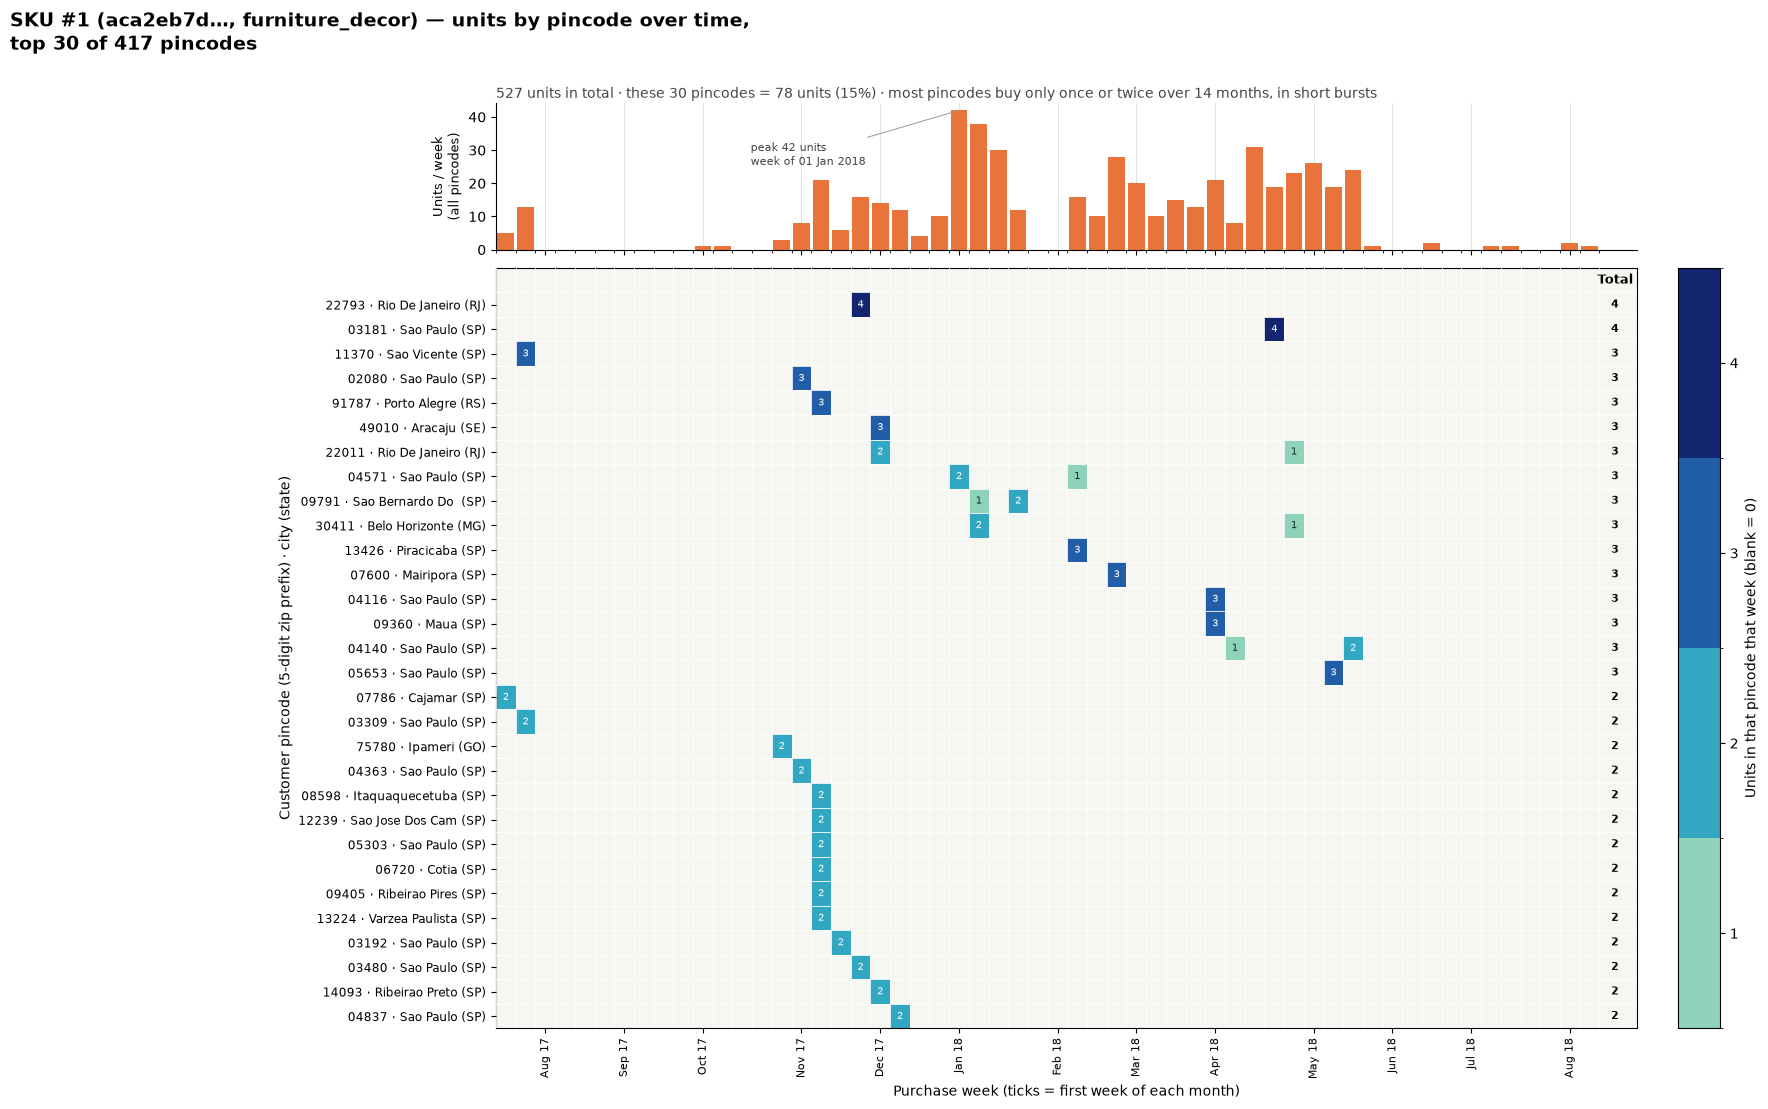

Peak week: 01 Jan 2018; 42 units
Top 5 pincodes by units:
 customer_zip_code_prefix  units           city state
                    22793      4 rio de janeiro    RJ
                     3181      4      sao paulo    SP
                    11370      3    sao vicente    SP
                     2080      3      sao paulo    SP
                    91787      3   porto alegre    RS


In [63]:
sku1_pincode_result = plot_pincode_time(
    PRODUCT_ID,
    RANK_LABEL,
    n_pincodes=N_PINCODES,
)
print(
    f"Peak week: {sku1_pincode_result['peak_week']:%d %b %Y}; "
    f"{sku1_pincode_result['peak_units']} units"
)
print("Top 5 pincodes by units:")
print(
    sku1_pincode_result["top_pincodes"]
    [["customer_zip_code_prefix", "units", "city", "state"]]
    .head(5)
    .to_string(index=False)
)

### Save Pincode-Time Charts for the Top 20 SKUs

In [65]:
# Save one map per SKU, preserving rank from full-dataset unit counts.
pincode_time_output_dir = Path("pincode_time_by_sku")
pincode_time_output_dir.mkdir(parents=True, exist_ok=True)
pincode_time_top20_ids = (
    pincode_time_master["product_id"].value_counts().head(20).index.tolist()
)

for rank, product_id in enumerate(pincode_time_top20_ids, start=1):
    output_path = pincode_time_output_dir / (
        f"sku{rank:02d}_{product_id[:8]}_pincode_time.png"
    )
    plot_pincode_time(
        product_id,
        rank_label=f"#{rank}",
        n_pincodes=N_PINCODES,
        out_png=str(output_path),
    )

print(f"Saved pincode-time charts for {len(pincode_time_top20_ids)} SKUs in {pincode_time_output_dir}/")

aca2eb7d00ea1a7b8ebd4e68314663af: 527 units, 417 pincodes, top 30 = 78 units (15%)
99a4788cb24856965c36a24e339b6058: 488 units, 445 pincodes, top 30 = 65 units (13%)
422879e10f46682990de24d770e7f83d: 484 units, 340 pincodes, top 30 = 120 units (25%)
389d119b48cf3043d311335e499d9c6b: 392 units, 302 pincodes, top 30 = 81 units (21%)
368c6c730842d78016ad823897a372db: 388 units, 287 pincodes, top 30 = 92 units (24%)
53759a2ecddad2bb87a079a1f1519f73: 373 units, 274 pincodes, top 30 = 87 units (23%)
d1c427060a0f73f6b889a5c7c61f2ac4: 343 units, 307 pincodes, top 30 = 62 units (18%)
53b36df67ebb7c41585e8d54d6772e08: 323 units, 287 pincodes, top 30 = 66 units (20%)
154e7e31ebfa092203795c972e5804a6: 281 units, 260 pincodes, top 30 = 51 units (18%)
3dd2a17168ec895c781a9191c1e95ad7: 274 units, 247 pincodes, top 30 = 57 units (21%)
2b4609f8948be18874494203496bc318: 260 units, 255 pincodes, top 30 = 35 units (13%)
7c1bd920dbdf22470b68bde975dd3ccf: 231 units, 219 pincodes, top 30 = 42 units (18%)
a62

## Monthly Pincode Distribution for the Top 20 SKUs

### Parameters

In [66]:
# Chart parameters.
DATA = "olist_master_dataset.csv"
N_SKUS = 20
N_PINCODES = 15
OUT_PNG = "top20_pincode_month_grid.png"

### Load Data and Select Top 20 SKUs

In [67]:
# Rank SKUs on the full dataset, then build one shared month range.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

pincode_month_columns = [
    "product_id", "order_id", "order_purchase_timestamp",
    "customer_zip_code_prefix", "customer_state", "product_category_name_english",
]
pincode_month_df = pd.read_csv(
    DATA,
    usecols=pincode_month_columns,
    parse_dates=["order_purchase_timestamp"],
)
top_product_ids = pincode_month_df["product_id"].value_counts().head(N_SKUS).index.tolist()
category_by_product = (
    pincode_month_df.groupby("product_id")["product_category_name_english"].first()
)
top_sku_meta = pd.DataFrame({"product_id": top_product_ids})
top_sku_meta["rank"] = np.arange(1, len(top_sku_meta) + 1)
top_sku_meta["category"] = top_sku_meta["product_id"].map(category_by_product)
top_sku_meta["category_label"] = top_sku_meta["category"].fillna("uncategorised")
top_sku_meta["label"] = [
    f"#{rank} {category[:20]} · {product_id[:8]}…"
    for rank, category, product_id in zip(
        top_sku_meta["rank"], top_sku_meta["category_label"], top_sku_meta["product_id"]
    )
]
d0 = pincode_month_df.loc[pincode_month_df["product_id"].isin(top_product_ids)].copy()
d0["ym"] = d0["order_purchase_timestamp"].dt.to_period("M")
months = pd.period_range(d0["ym"].min(), d0["ym"].max(), freq="M")

print(f"Loaded {len(pincode_month_df):,} rows; charting {len(top_product_ids)} SKUs")
print(f"Month columns: {months[0]} through {months[-1]} ({len(months)} months)")

Loaded 113,425 rows; charting 20 SKUs
Month columns: 2017-01 through 2018-08 (20 months)


### Build Per-SKU Pincode Tables and Monthly Matrices

In [68]:
# Select each SKU's own top pincodes and build aligned pincode-by-month matrices.
pincode_month_results = []
summary_rows = []
for sku in top_sku_meta.itertuples(index=False):
    product_rows = d0.loc[d0["product_id"].eq(sku.product_id)].copy()
    pincode_table = (
        product_rows.groupby("customer_zip_code_prefix")
        .agg(
            units=("order_id", "size"),
            state=("customer_state", "first"),
            first_purchase=("order_purchase_timestamp", "min"),
        )
        .sort_values(["units", "first_purchase"], ascending=[False, True], kind="stable")
    )
    top_pincodes = pincode_table.head(N_PINCODES)
    top_rows = product_rows.loc[
        product_rows["customer_zip_code_prefix"].isin(top_pincodes.index)
    ]
    matrix = (
        top_rows.groupby(["customer_zip_code_prefix", "ym"])
        .size()
        .unstack("ym", fill_value=0)
        .reindex(index=top_pincodes.index, columns=months, fill_value=0)
    )
    total_units = len(product_rows)
    pincode_count = len(pincode_table)
    pct_once = (pincode_table["units"].eq(1).mean() if pincode_count else 0)

    pincode_month_results.append({
        "rank": sku.rank,
        "product_id": sku.product_id,
        "category": sku.category_label,
        "label": sku.label,
        "units": total_units,
        "pincodes": pincode_count,
        "pct_once": pct_once,
        "pincode_table": pincode_table,
        "top": top_pincodes,
        "mat": matrix,
    })
    summary_rows.append({
        "rank": sku.rank,
        "product_id": sku.product_id,
        "category": sku.category_label,
        "units": total_units,
        "pincodes": pincode_count,
        "pct_once": pct_once,
    })

pincode_month_summary = pd.DataFrame(summary_rows)
pincode_month_summary.to_csv("top20_pincode_month_summary.csv", index=False)
max_pincode_month_units = max(
    int(result["mat"].to_numpy().max()) for result in pincode_month_results
)
print(pincode_month_summary.to_string(index=False, formatters={"pct_once": "{:.0%}".format}))
print(f"Shared maximum weekly cell count: {max_pincode_month_units}")

 rank                       product_id              category  units  pincodes pct_once
    1 aca2eb7d00ea1a7b8ebd4e68314663af       furniture_decor    527       417      78%
    2 99a4788cb24856965c36a24e339b6058        bed_bath_table    488       445      91%
    3 422879e10f46682990de24d770e7f83d          garden_tools    484       340      75%
    4 389d119b48cf3043d311335e499d9c6b          garden_tools    392       302      77%
    5 368c6c730842d78016ad823897a372db          garden_tools    388       287      76%
    6 53759a2ecddad2bb87a079a1f1519f73          garden_tools    373       274      74%
    7 d1c427060a0f73f6b889a5c7c61f2ac4 computers_accessories    343       307      89%
    8 53b36df67ebb7c41585e8d54d6772e08         watches_gifts    323       287      91%
    9 154e7e31ebfa092203795c972e5804a6         health_beauty    281       260      93%
   10 3dd2a17168ec895c781a9191c1e95ad7 computers_accessories    274       247      93%
   11 2b4609f8948be18874494203496bc318     

### Render and Save the Shared-Scale Pincode Heatmap Grid

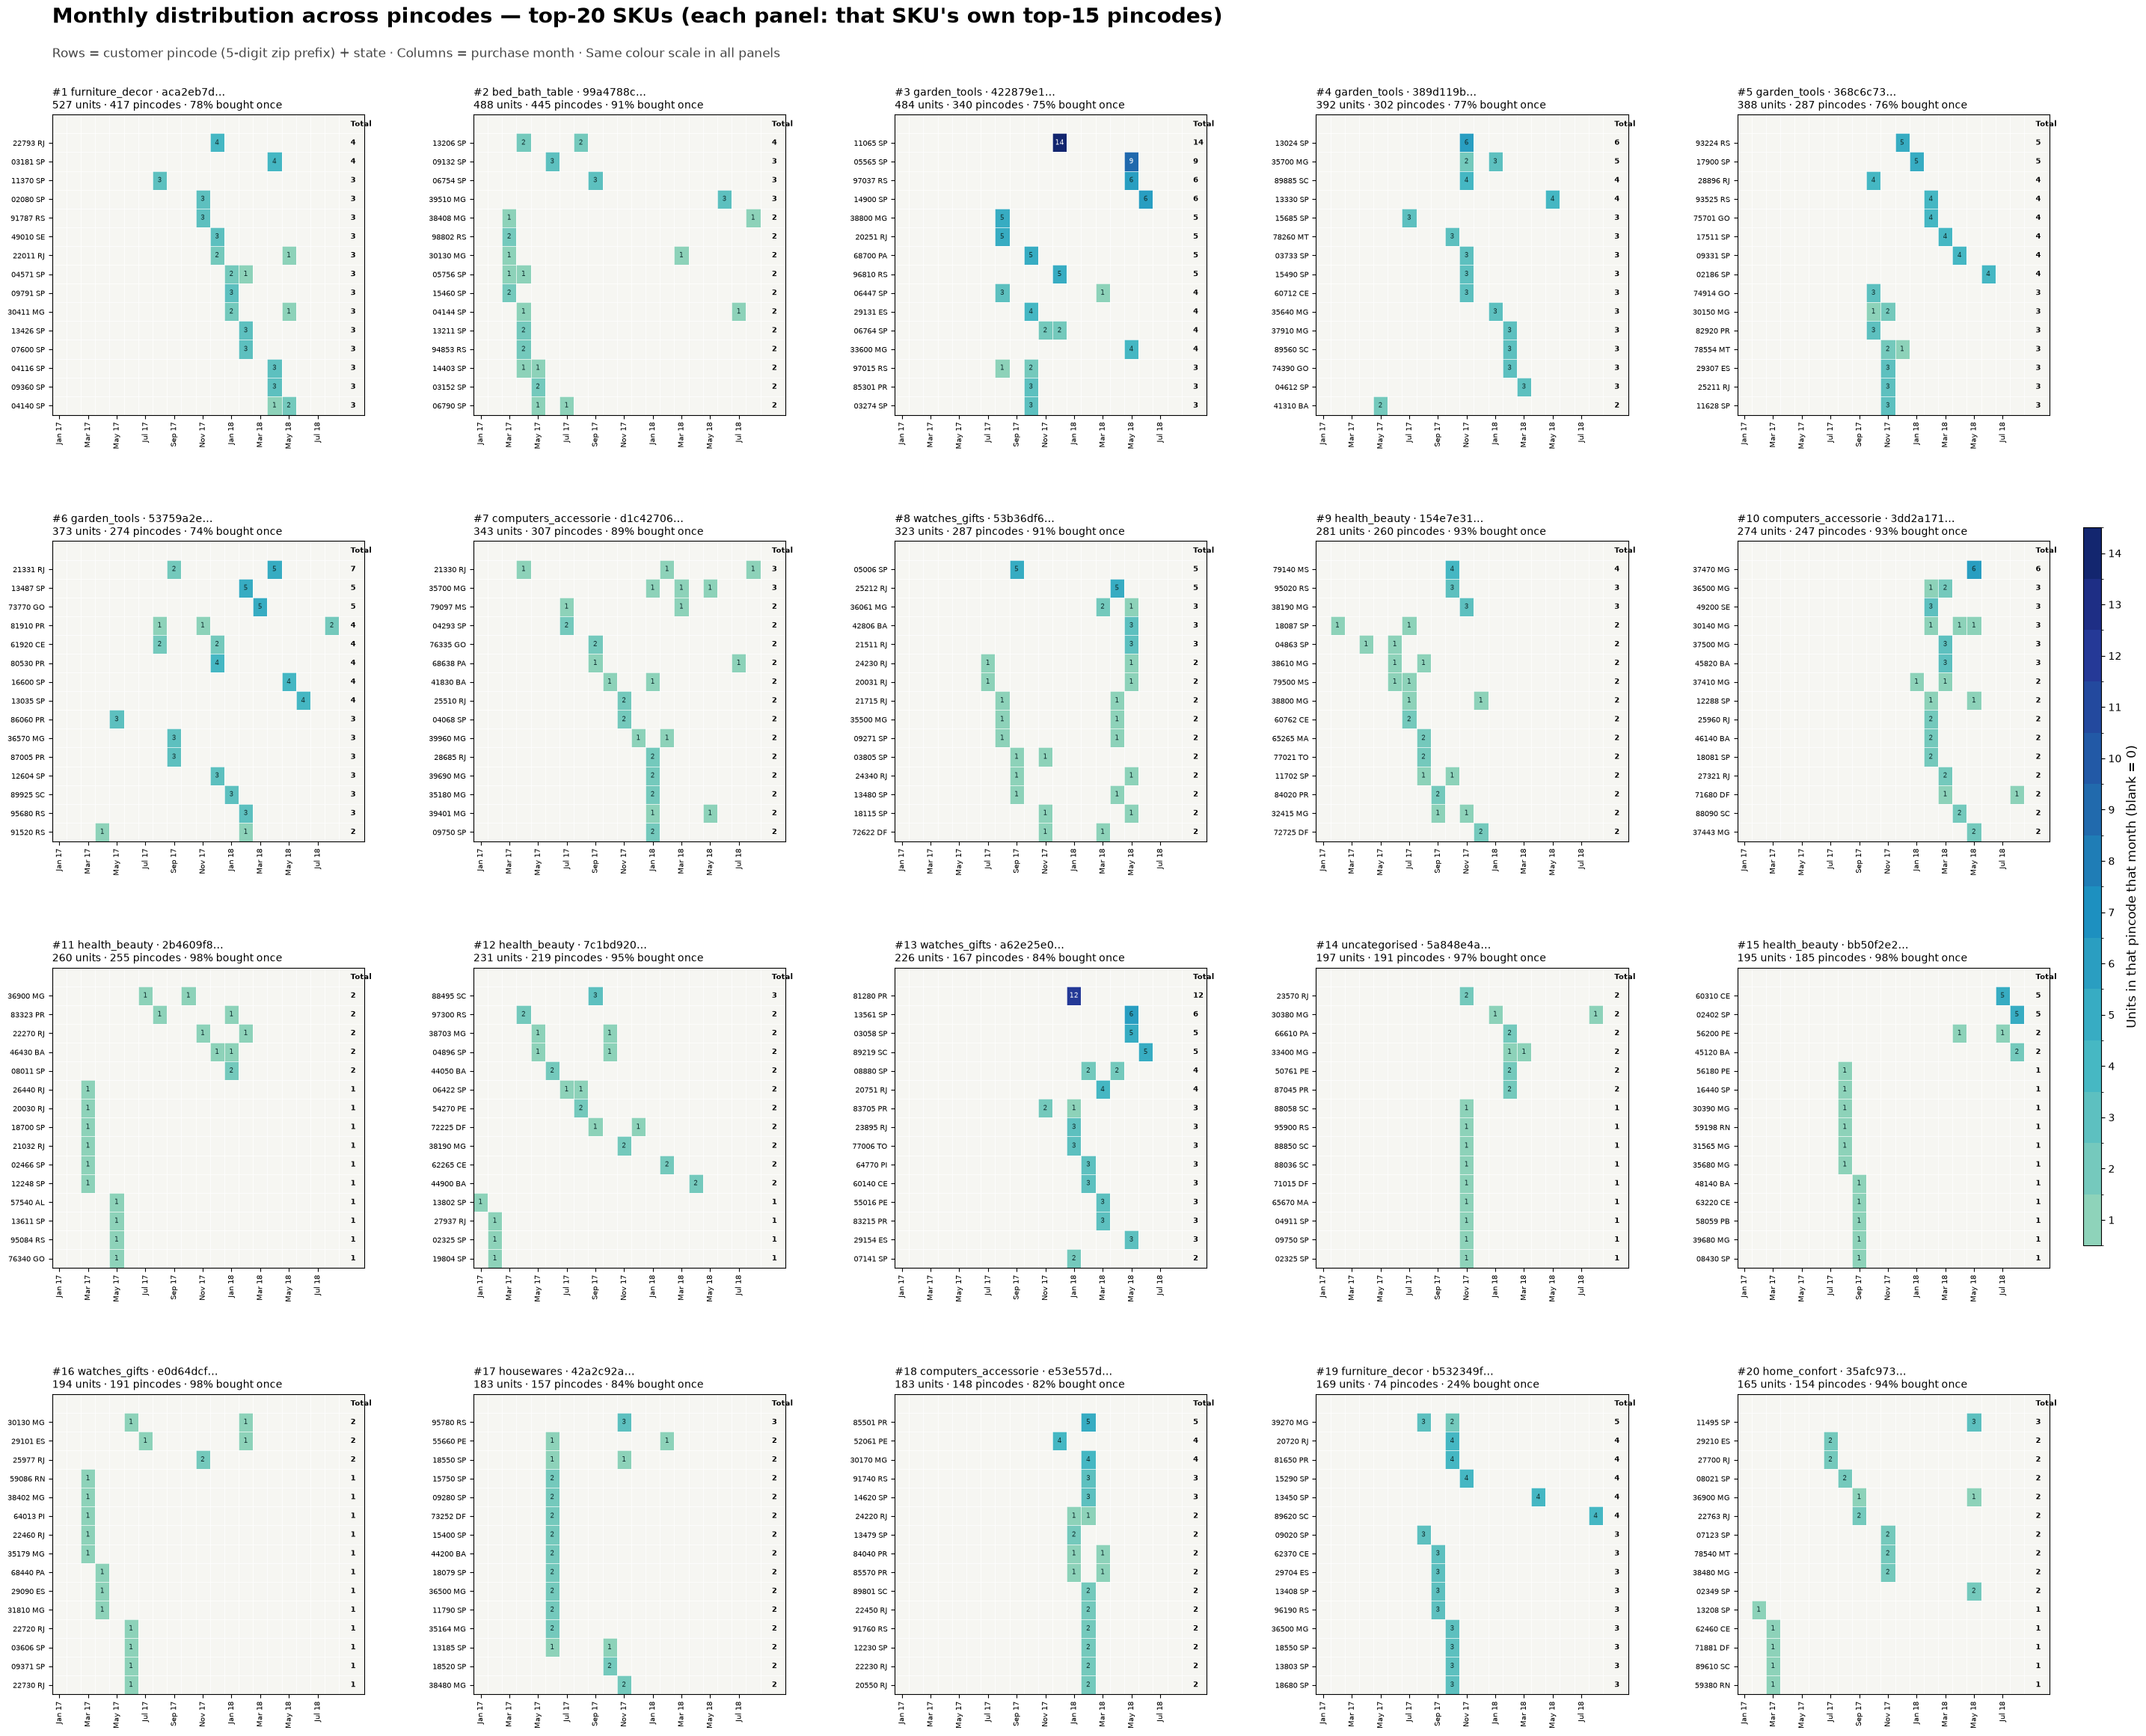

#3 11065 SP, Dec 2017: 14
#13 81280 PR, Jan 2018: 12
Summary table:
 rank                       product_id              category  units  pincodes pct_once
    1 aca2eb7d00ea1a7b8ebd4e68314663af       furniture_decor    527       417      78%
    2 99a4788cb24856965c36a24e339b6058        bed_bath_table    488       445      91%
    3 422879e10f46682990de24d770e7f83d          garden_tools    484       340      75%
    4 389d119b48cf3043d311335e499d9c6b          garden_tools    392       302      77%
    5 368c6c730842d78016ad823897a372db          garden_tools    388       287      76%
    6 53759a2ecddad2bb87a079a1f1519f73          garden_tools    373       274      74%
    7 d1c427060a0f73f6b889a5c7c61f2ac4 computers_accessories    343       307      89%
    8 53b36df67ebb7c41585e8d54d6772e08         watches_gifts    323       287      91%
    9 154e7e31ebfa092203795c972e5804a6         health_beauty    281       260      93%
   10 3dd2a17168ec895c781a9191c1e95ad7 computers_accessories  

In [69]:
# Draw all 20 SKU matrices with one discrete shared colour scale.
max_cell = max_pincode_month_units
assert max_cell == 14, f"Expected shared maximum 14, found {max_cell}"
cmap = ListedColormap(
    plt.get_cmap("YlGnBu")(0.35 + 0.6 * np.arange(max_cell) / max(1, max_cell - 1))
)
cmap.set_bad("#f6f6f2")
norm = BoundaryNorm(np.arange(0.5, max_cell + 1.5), max_cell)

fig, axs = plt.subplots(4, 5, figsize=(30, 24))
image_for_colorbar = None
month_tick_positions = np.arange(0, len(months), 2)

for result, ax in zip(pincode_month_results, axs.ravel()):
    matrix = result["mat"]
    values = matrix.to_numpy(dtype=float)
    shown_values = np.where(values == 0, np.nan, values)
    ax.set_facecolor("#f6f6f2")
    image_for_colorbar = ax.imshow(
        shown_values,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    pincode_table = result["top"]
    y_labels = [
        f"{int(pincode):05d} {state}"
        for pincode, state in zip(
            pincode_table.index,
            pincode_table["state"],
        )
    ]
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=7.5)
    ax.set_xticks(month_tick_positions)
    ax.set_xticklabels(
        [months[position].strftime("%b %y") for position in month_tick_positions],
        rotation=90,
        fontsize=7,
    )
    ax.set_xticks(np.arange(-0.5, len(months), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(y_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row_index in range(values.shape[0]):
        for month_index in range(values.shape[1]):
            units = int(values[row_index, month_index])
            if units:
                ax.text(
                    month_index,
                    row_index,
                    str(units),
                    ha="center",
                    va="center",
                    fontsize=6.5,
                    color="white" if units >= 0.45 * max_cell else "#123333",
                )

    ax.set_title(
        f"#{result['rank']} {result['category'][:20]} · {result['product_id'][:8]}…\n"
        f"{result['units']} units · {result['pincodes']} pincodes · "
        f"{result['pct_once']:.0%} bought once",
        loc="left",
        fontsize=10,
    )

    row_totals = values.sum(axis=1)
    for row_index, row_total in enumerate(row_totals):
        ax.text(
            len(months) + 0.3,
            row_index,
            f"{int(row_total)}",
            ha="left",
            va="center",
            fontsize=7,
            fontweight="bold",
            clip_on=False,
        )
    ax.text(
        len(months) + 0.3,
        -1.0,
        "Total",
        ha="left",
        va="center",
        fontsize=7,
        fontweight="bold",
        clip_on=False,
    )
    ax.set_xlim(-0.5, len(months) + 1.25)
    ax.set_ylim(len(y_labels) - 0.5, -1.5)

cax = fig.add_axes([0.945, 0.30, 0.008, 0.40])
colorbar = fig.colorbar(image_for_colorbar, cax=cax, ticks=range(1, max_cell + 1))
colorbar.set_label("Units in that pincode that month (blank = 0)", fontsize=12)
fig.suptitle(
    "Monthly distribution across pincodes — top-20 SKUs "
    "(each panel: that SKU's own top-15 pincodes)",
    fontweight="bold",
    fontsize=20,
    x=0.04,
    y=0.99,
    ha="left",
)
fig.text(
    0.04,
    0.962,
    "Rows = customer pincode (5-digit zip prefix) + state · "
    "Columns = purchase month · Same colour scale in all panels",
    fontsize=12,
    color="#444444",
)
fig.subplots_adjust(
    left=0.04, right=0.93, top=0.93, bottom=0.05, wspace=0.35, hspace=0.42
)
fig.savefig(OUT_PNG, dpi=110, bbox_inches="tight")
plt.show()

# Verify the highlighted SKU/pincode/month cells and print the summary table.
sku3_matrix = pincode_month_results[2]["mat"]
sku13_matrix = pincode_month_results[12]["mat"]
print("#3 11065 SP, Dec 2017:", int(sku3_matrix.loc[11065, pd.Period("2017-12")]))
print("#13 81280 PR, Jan 2018:", int(sku13_matrix.loc[81280, pd.Period("2018-01")]))
print("Summary table:")
print(pincode_month_summary.to_string(index=False, formatters={"pct_once": "{:.0%}".format}))
print(f"Saved figure: {OUT_PNG}")

## Monthly Product Distribution Across Pincodes — Own Top-20 ZIPs

### Parameters

In [70]:
# Settings for the own-top-pincodes variant.
DATA = "olist_master_dataset.csv"
N_SKUS = 20
N_PINCODES = 20
MODE = "own"  # Use "common" to compare the same 20 pincode prefixes in every panel.
OUT_PNG = (
    "top20_monthly_pincode_grid_own.png"
    if MODE == "own"
    else "top20_monthly_pincode_grid_common.png"
)

### Load Data and Select the Official Top 20

In [71]:
# Rank the full, unfiltered table first so SKU order matches the official list.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

distribution_columns = [
    "product_id", "order_id", "order_purchase_timestamp",
    "customer_zip_code_prefix", "customer_state",
    "product_category_name_english",
]
df = pd.read_csv(
    DATA,
    usecols=distribution_columns,
    parse_dates=["order_purchase_timestamp"],
)
TOP = df["product_id"].value_counts().head(N_SKUS).index
category_by_id = df.groupby("product_id")["product_category_name_english"].first()
d0 = df.loc[df["product_id"].isin(TOP)].copy()
d0["ym"] = d0["order_purchase_timestamp"].dt.to_period("M")
months = pd.period_range(d0["ym"].min(), d0["ym"].max(), freq="M")

print(f"Loaded {len(df):,} source rows; {len(TOP)} top SKUs; {len(months)} month columns")
print("Top three SKUs:", TOP[:3].tolist())

Loaded 113,425 source rows; 20 top SKUs; 20 month columns
Top three SKUs: ['aca2eb7d00ea1a7b8ebd4e68314663af', '99a4788cb24856965c36a24e339b6058', '422879e10f46682990de24d770e7f83d']


### Build SKU-Specific Pincode Matrices and Summary

In [72]:
# Build a separate pincode-by-month matrix for each SKU.
if MODE not in {"own", "common"}:
    raise ValueError("MODE must be 'own' or 'common'")

common_pincodes = (
    df["customer_zip_code_prefix"].value_counts().head(N_PINCODES).index.tolist()
)
pincode_panel_data = []
summary_rows = []

for rank, product_id in enumerate(TOP, start=1):
    dp = d0.loc[d0["product_id"].eq(product_id)].copy()
    pincode_counts = dp["customer_zip_code_prefix"].value_counts()
    if MODE == "own":
        pins = (
            pincode_counts.sort_index()
            .sort_values(ascending=False, kind="stable")
            .head(N_PINCODES)
            .index
            .tolist()
        )
    else:
        pins = common_pincodes

    matrix = (
        dp.loc[dp["customer_zip_code_prefix"].isin(pins)]
        .groupby(["customer_zip_code_prefix", "ym"])
        .size()
        .unstack("ym", fill_value=0)
        .reindex(index=pins, columns=months, fill_value=0)
    )
    category_value = category_by_id.get(product_id)
    category = category_value if pd.notna(category_value) else "uncategorised"
    unit_count = len(dp)
    pincode_count = dp["customer_zip_code_prefix"].nunique()
    pct_once = (pincode_counts.eq(1).sum() / len(pincode_counts)) if len(pincode_counts) else 0
    units_shown = int(matrix.to_numpy().sum())

    pincode_panel_data.append({
        "rank": rank,
        "product_id": product_id,
        "category": category,
        "pins": pins,
        "mat": matrix,
        "total_units": unit_count,
        "pincodes": pincode_count,
        "pct_once": pct_once,
        "units_shown": units_shown,
    })
    summary_rows.append({
        "rank": rank,
        "product_id": product_id,
        "category": category,
        "units": unit_count,
        "pincodes": pincode_count,
        "pct_once": pct_once,
        "units_shown": units_shown,
    })

pincode_panel_summary = pd.DataFrame(summary_rows)
pincode_panel_summary.to_csv("top20_pincode_month_summary.csv", index=False)
MX = max(
    int(panel["mat"].to_numpy().max()) for panel in pincode_panel_data
)
print(pincode_panel_summary.to_string(index=False, formatters={"pct_once": "{:.0%}".format}))
print(f"Units shown across panels: {pincode_panel_summary['units_shown'].sum():,}; shared MX: {MX}")

 rank                       product_id              category  units  pincodes pct_once  units_shown
    1 aca2eb7d00ea1a7b8ebd4e68314663af       furniture_decor    527       417      78%           58
    2 99a4788cb24856965c36a24e339b6058        bed_bath_table    488       445      91%           45
    3 422879e10f46682990de24d770e7f83d          garden_tools    484       340      75%           95
    4 389d119b48cf3043d311335e499d9c6b          garden_tools    392       302      77%           61
    5 368c6c730842d78016ad823897a372db          garden_tools    388       287      76%           70
    6 53759a2ecddad2bb87a079a1f1519f73          garden_tools    373       274      74%           67
    7 d1c427060a0f73f6b889a5c7c61f2ac4 computers_accessories    343       307      89%           42
    8 53b36df67ebb7c41585e8d54d6772e08         watches_gifts    323       287      91%           49
    9 154e7e31ebfa092203795c972e5804a6         health_beauty    281       260      93%           41


### Draw and Save the 4×5 Heatmap Grid

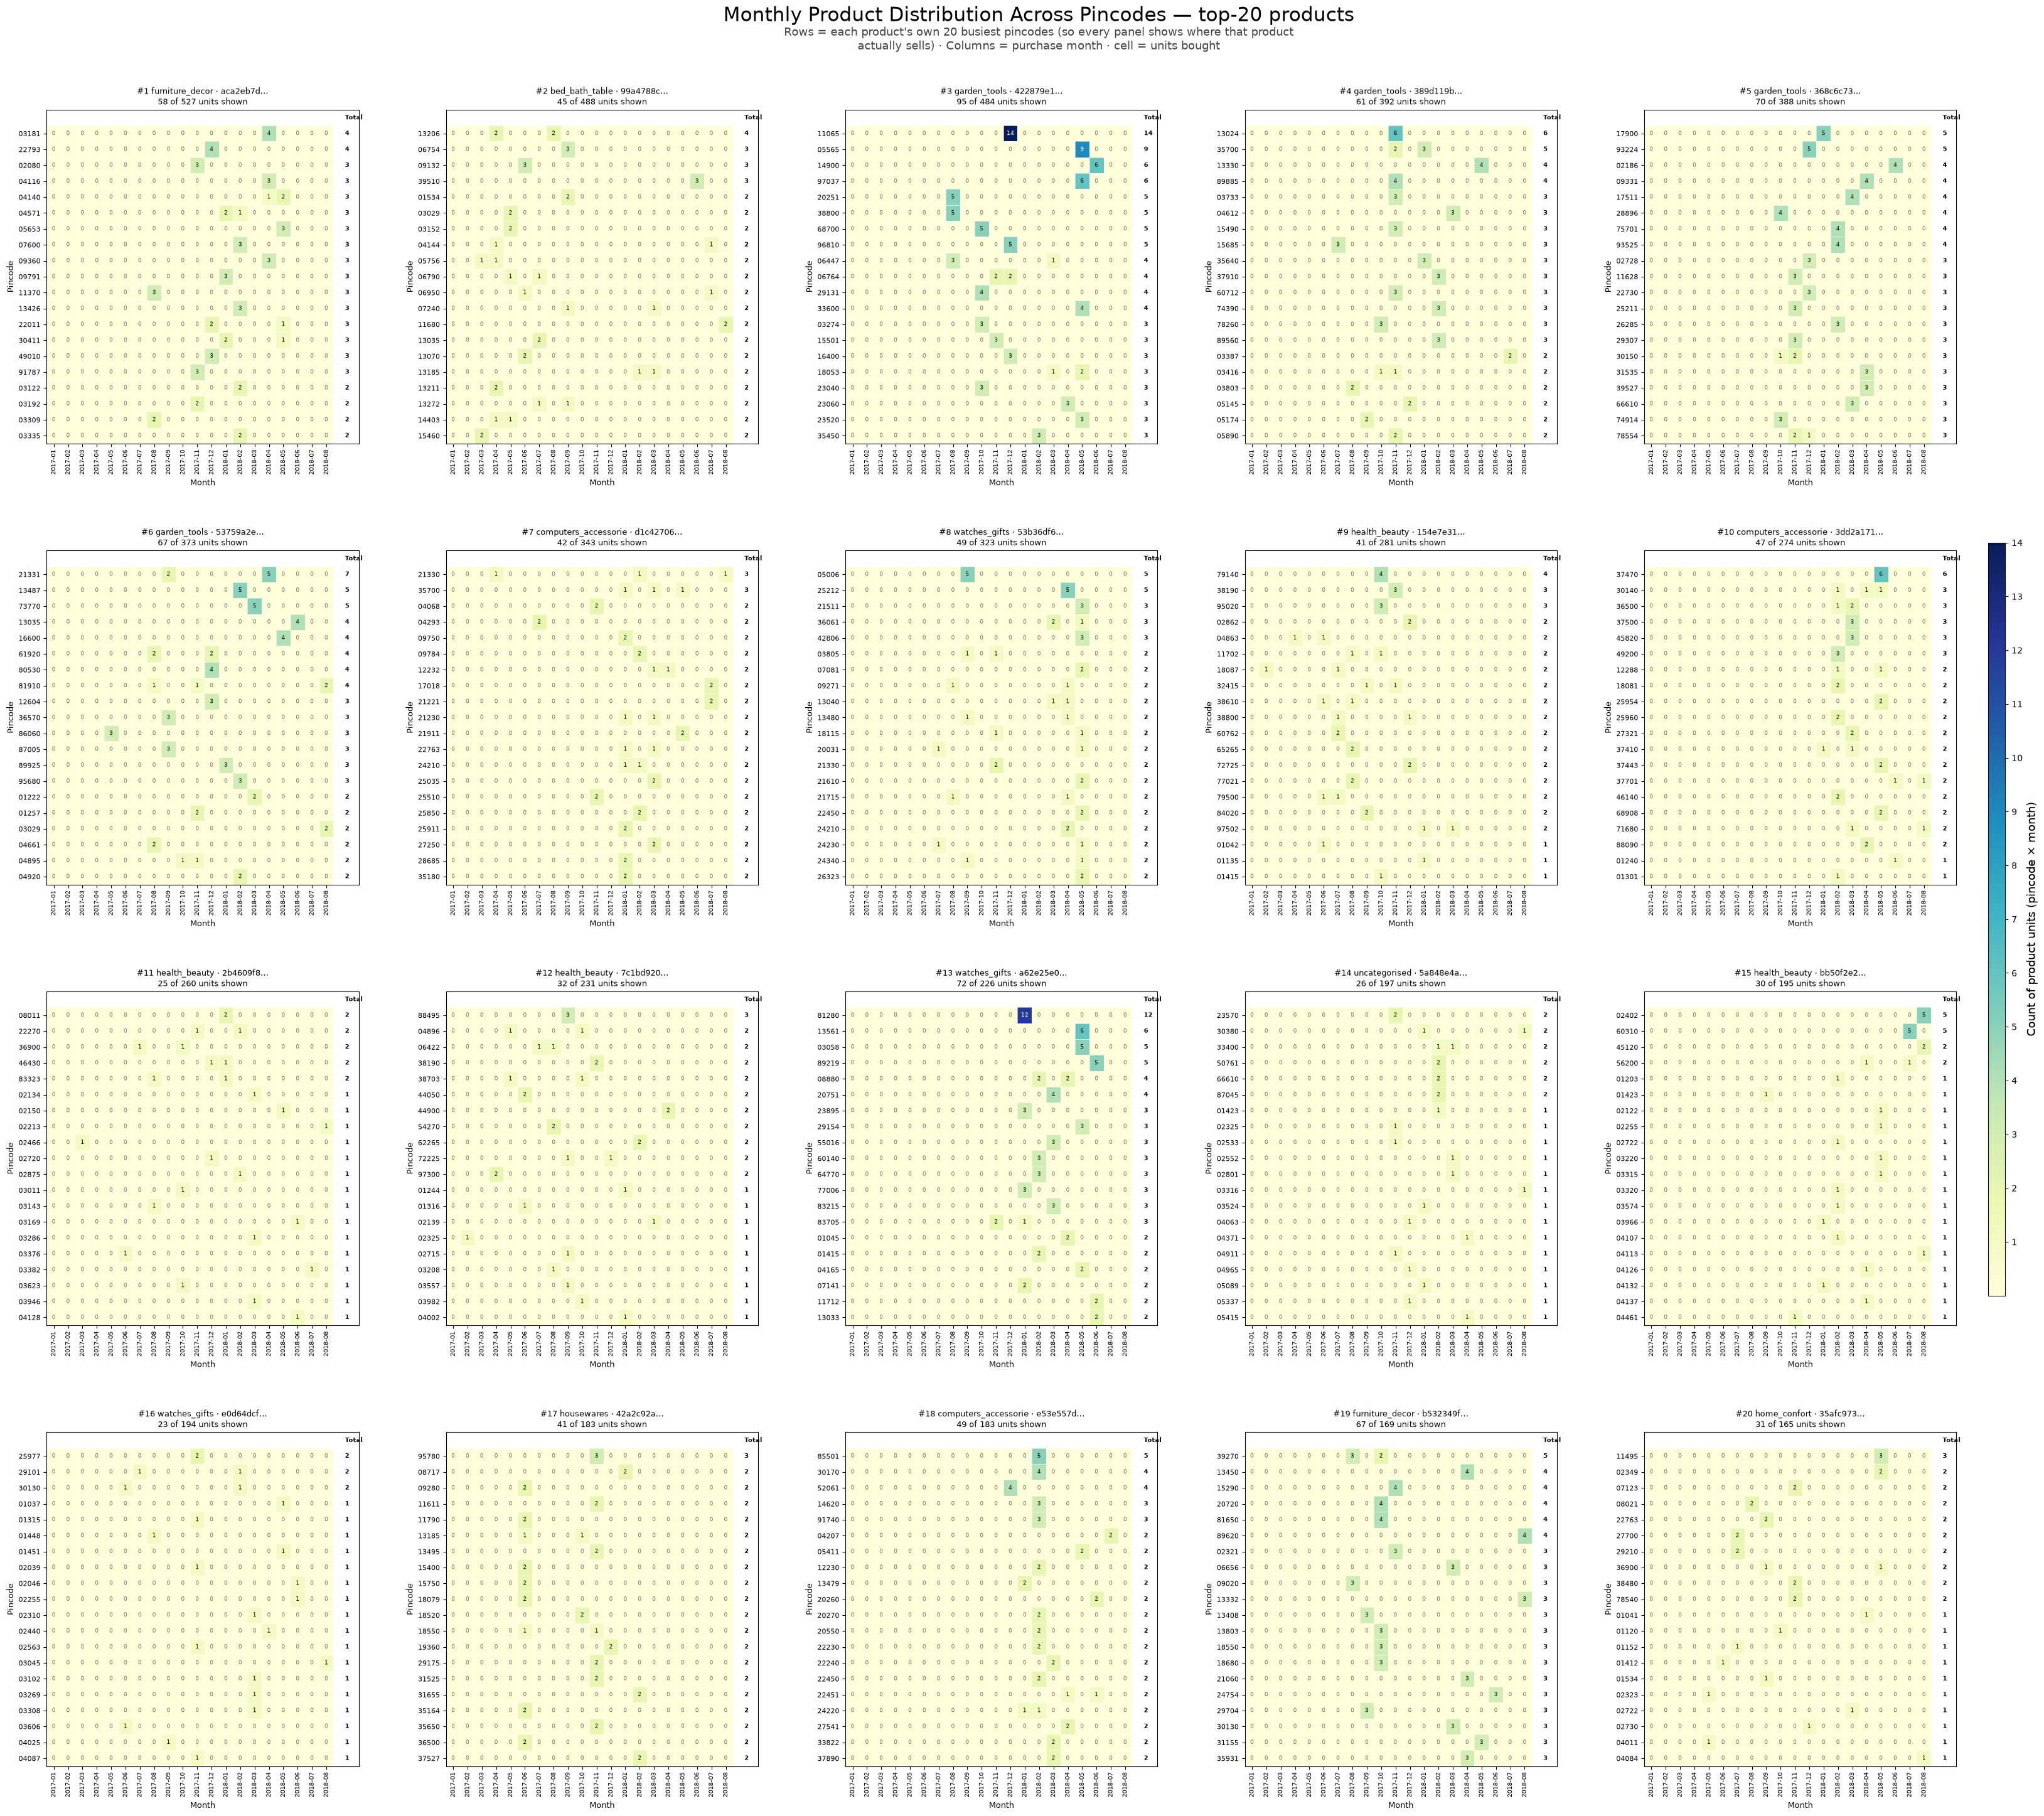

Units shown across panels: 971
Shared maximum cell value: 14
#3 11065 SP, Dec 2017: 14
#13 81280 PR, Jan 2018: 12
Summary table:
 rank                       product_id              category  units  pincodes pct_once  units_shown
    1 aca2eb7d00ea1a7b8ebd4e68314663af       furniture_decor    527       417      78%           58
    2 99a4788cb24856965c36a24e339b6058        bed_bath_table    488       445      91%           45
    3 422879e10f46682990de24d770e7f83d          garden_tools    484       340      75%           95
    4 389d119b48cf3043d311335e499d9c6b          garden_tools    392       302      77%           61
    5 368c6c730842d78016ad823897a372db          garden_tools    388       287      76%           70
    6 53759a2ecddad2bb87a079a1f1519f73          garden_tools    373       274      74%           67
    7 d1c427060a0f73f6b889a5c7c61f2ac4 computers_accessories    343       307      89%           42
    8 53b36df67ebb7c41585e8d54d6772e08         watches_gifts    323    

In [75]:
# Render one panel per SKU with the shared continuous 0..MX scale.
units_shown_total = sum(panel["units_shown"] for panel in pincode_panel_data)
if MODE == "own":
    assert units_shown_total == 971
    assert MX == 14
    assert pincode_panel_data[2]["mat"].loc[11065, pd.Period("2017-12")] == 14
    assert pincode_panel_data[12]["mat"].loc[81280, pd.Period("2018-01")] == 12
else:
    assert units_shown_total == 107

fig, axs = plt.subplots(4, 5, figsize=(34, 30))
image_for_colorbar = None

for panel, ax in zip(pincode_panel_data, axs.ravel()):
    matrix = panel["mat"]
    values = matrix.to_numpy(dtype=float)
    image_for_colorbar = ax.imshow(
        values,
        aspect="auto",
        cmap="YlGnBu",
        vmin=0,
        vmax=MX,
        interpolation="nearest",
    )
    ax.set_yticks(np.arange(len(panel["pins"])))
    ax.set_yticklabels([f"{int(pincode):05d}" for pincode in panel["pins"]], fontsize=8)
    ax.set_ylabel("Pincode", fontsize=9)
    ax.set_xticks(np.arange(len(months)))
    ax.set_xticklabels([str(month) for month in months], rotation=90, fontsize=7)
    ax.set_xlabel("Month", fontsize=9)
    ax.set_xticks(np.arange(-0.5, len(months), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(panel["pins"]), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row_index in range(values.shape[0]):
        for month_index in range(values.shape[1]):
            units = int(values[row_index, month_index])
            if units > 0.5 * MX:
                text_color = "white"
            elif units > 0:
                text_color = "#111111"
            else:
                text_color = "#777777"
            ax.text(
                month_index, row_index, str(units),
                ha="center", va="center", fontsize=6.5, color=text_color,
            )

    ax.set_title(
        f"#{panel['rank']} {panel['category'][:20]} · {panel['product_id'][:8]}…\n"
        f"{panel['units_shown']} of {panel['total_units']} units shown",
        loc="center",
        fontsize=9.5,
    )
    for row_index, row_total in enumerate(values.sum(axis=1)):
        ax.text(
            len(months) + 0.3, row_index, f"{int(row_total)}",
            ha="left", va="center", fontsize=7, fontweight="bold", clip_on=False,
        )
    ax.text(
        len(months) + 0.3, -1.0, "Total",
        ha="left", va="center", fontsize=7, fontweight="bold", clip_on=False,
    )
    ax.set_xlim(-0.5, len(months) + 1.25)
    ax.set_ylim(len(panel["pins"]) - 0.5, -1.5)

cax = fig.add_axes([0.945, 0.30, 0.008, 0.40])
colorbar = fig.colorbar(image_for_colorbar, cax=cax, ticks=range(1, MX + 1))
colorbar.set_label("Count of product units (pincode × month)", fontsize=13)
fig.suptitle(
    "Monthly Product Distribution Across Pincodes — top-20 products",
    fontsize=22, y=0.985,
)
subtitle = (
    "Rows = each product's own 20 busiest pincodes (so every panel shows where that product\n"
    "actually sells) · Columns = purchase month · cell = units bought"
    if MODE == "own"
    else "Rows = the same 20 pincodes in every panel (the 20 busiest pincodes in the whole Olist\n"
    "dataset) · Columns = purchase month · cell = units bought"
)
fig.text(0.5, 0.962, subtitle, ha="center", fontsize=13, color="#444444")
fig.subplots_adjust(left=0.035, right=0.93, top=0.93, bottom=0.05, wspace=0.28, hspace=0.32)

OUT_PNG = (
    "top20_monthly_pincode_grid_own.png"
    if MODE == "own"
    else "top20_monthly_pincode_grid_common.png"
)
fig.savefig(OUT_PNG, dpi=100, bbox_inches="tight")
plt.show()

# Print the computed totals and the matrix sanity cells.
sku3_matrix = pincode_panel_data[2]["mat"]
sku13_matrix = pincode_panel_data[12]["mat"]
print("Units shown across panels:", units_shown_total)
print("Shared maximum cell value:", MX)
print("#3 11065 SP, Dec 2017:", int(sku3_matrix.loc[11065, pd.Period("2017-12")]))
print("#13 81280 PR, Jan 2018:", int(sku13_matrix.loc[81280, pd.Period("2018-01")]))
print("Summary table:")
print(pincode_panel_summary.to_string(index=False, formatters={"pct_once": "{:.0%}".format}))
print(f"Saved figure: {OUT_PNG}")

## Valmo-SAVE RTO Recovery Model


### Load Engine, Dependencies, and Olist Data

In [2]:
# Import the supplied model modules and locate the six required Olist CSVs.
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().resolve()
MODEL_DIR = PROJECT_DIR / "slide 6"
if not (MODEL_DIR / "salvage_v2.py").is_file():
    raise FileNotFoundError(f"Model sources not found: {MODEL_DIR}")
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

import salvage_v2
import slides_v2
import test_salvage_v2
from salvage_v2 import CostConfig, EngineConfig, find_data_dir, run_all

DATA_DIR = None
for data_root in (
    PROJECT_DIR,
    MODEL_DIR,
    Path.home() / "Downloads" / "archive",
    Path.home() / "Downloads",
):
    try:
        DATA_DIR = find_data_dir(str(data_root))
        break
    except FileNotFoundError:
        continue
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate the six Olist CSV files in the workspace or Downloads/archive.")

print(f"Model source: {MODEL_DIR}")
print(f"Olist data: {DATA_DIR}")
print("Imported engine, slide generator, and acceptance tests.")

Model source: /Users/dhruv_rai/Desktop/Meesho/slide 6
Olist data: /Users/dhruv_rai/Downloads/archive
Imported engine, slide generator, and acceptance tests.


## Configure the Workbook Costs and v2.2 Policy

In [3]:
# v2.2 defaults: 70 km resale pool, 21-day cap, and the Meesho 45-day lost rule.
MODEL_OUT_DIR = PROJECT_DIR / "outputs_v2"
RESALE_POOL = "radius"
RESALE_RADIUS_KM = 70
MAX_HOLD_DAYS = 21
APPLY_45_DAY_RULE = True
RUN_CAPACITY_SIM = True
RUN_RADIUS_SWEEP = True
SWEEP_RADII = (10, 25, 50, 70, 100, 150, 200)

model_costs = CostConfig()
model_config = EngineConfig(
    resale_pool=RESALE_POOL,
    resale_radius_km=RESALE_RADIUS_KM,
    max_hold_days=MAX_HOLD_DAYS,
    apply_lost_rule=APPLY_45_DAY_RULE,
)
print(
    f"Status quo ₹{model_costs.status_quo:.0f} | "
    f"held 30d and sold ₹{model_costs.success_cost(30):.0f} | "
    f"held 30d and unsold ₹{model_costs.failure_cost(30):.0f} | "
    f"flat break-even {model_costs.breakeven_flat():.2%}"
)

Status quo ₹170 | held 30d and sold ₹85 | held 30d and unsold ₹205 | flat break-even 29.17%


## Run Model Acceptance Tests

In [4]:
# Run cost, probability, calibration, and real-data geography/leakage checks.
test_salvage_v2.test_costs()
test_salvage_v2.test_policy_math()
test_salvage_v2.test_km()
test_salvage_v2.test_calibrator_identity()
test_salvage_v2.test_data(DATA_DIR)
print("All salvage model acceptance tests passed.")

ok  costs: 170 status quo · 25 one-time · ₹10/30 per day · 85 / 205 at 30 days · break-even 29.17 % · flat transport
ok  policy: every HOLD has E[C](T*) < ₹170 (49% of 4,000 random curves), threshold P_required = (25 + ₹0.33·E[days]) / 120 is exact
ok  Kaplan–Meier equals the product-limit formula and recovers a known geometric curve
ok  calibrator leaves an already-correct model unchanged (a = +0.013, b = 1.022)
ok  geography: 4,619 hub zones, every zone diameter ≤ 2R; launch areas have R_50 ≤ 15 km
ok  no look-ahead: the demand model at time t uses only orders before t
ok  labels censored at the cut-off; KM P(sold ≤ 7 d) = 1.51% vs 1.40% observed
ok  resale pools: buyers within 70 km of the hub (state mode: same state & state radius); pool model has no look-ahead; hold ≤ min(21 days, 45-day room) — median 21 days
    data tests took 7s
All salvage model acceptance tests passed.


## Run, Training, Backtest, and Production Outputs

In [5]:
# Execute the complete configured engine and write reproducible tables/report under outputs_v2/.
model_eng = run_all(
    DATA_DIR,
    out_dir=str(MODEL_OUT_DIR),
    cfg=model_config,
    cc=model_costs,
    verbose=True,
    do_capacity=RUN_CAPACITY_SIM,
    do_radius_sweep=RUN_RADIUS_SWEEP,
    sweep_radii=SWEEP_RADII,
)

[data] 2017-01-05 → 2018-08-24 | 101,206 order-lines | 99,483 pseudo-returns | 32,445 products | 14,905 ZIP prefixes
[regions] eps=2.5 km (knee) | 4,589 areas | 12 data-rich areas | 4,619 regions | max diameter 38.4 km | density law R_min ∝ density^-0.24
[pool] resale pool = any buyer within 70 km of the hub | holding cap 21 d + 45-day rule → median max hold 21 d; 9.1% of returns have no time left
[tune] best on validation: {'half_life': 30.0, 'alpha': 5.0, 'phi': 0.5, 'beta': 10.0} (log-lik -1.2659; no recency -1.3236)
                        policy  hold_rate  resale_rate_on_hold  predicted_on_hold  avg_cost  saving_per_return   ci_lo   ci_hi
            model (calibrated)      0.160                0.432              0.451   166.464              3.536   2.716   4.367
          model (uncalibrated)      0.119                0.509              0.537   166.233              3.767   2.966   4.615
    hold everything (max days)      0.885                0.112                NaN   185.438  

### Generate and Preview the Model Figures

Hero example: 1613b819ab5dae53aead2dbb4ebdb378 | auto | Guarulhos (SP)
Generated 15 presentation figures in /Users/dhruv_rai/Desktop/Meesho/outputs_v2/slides
01_decision_card.png


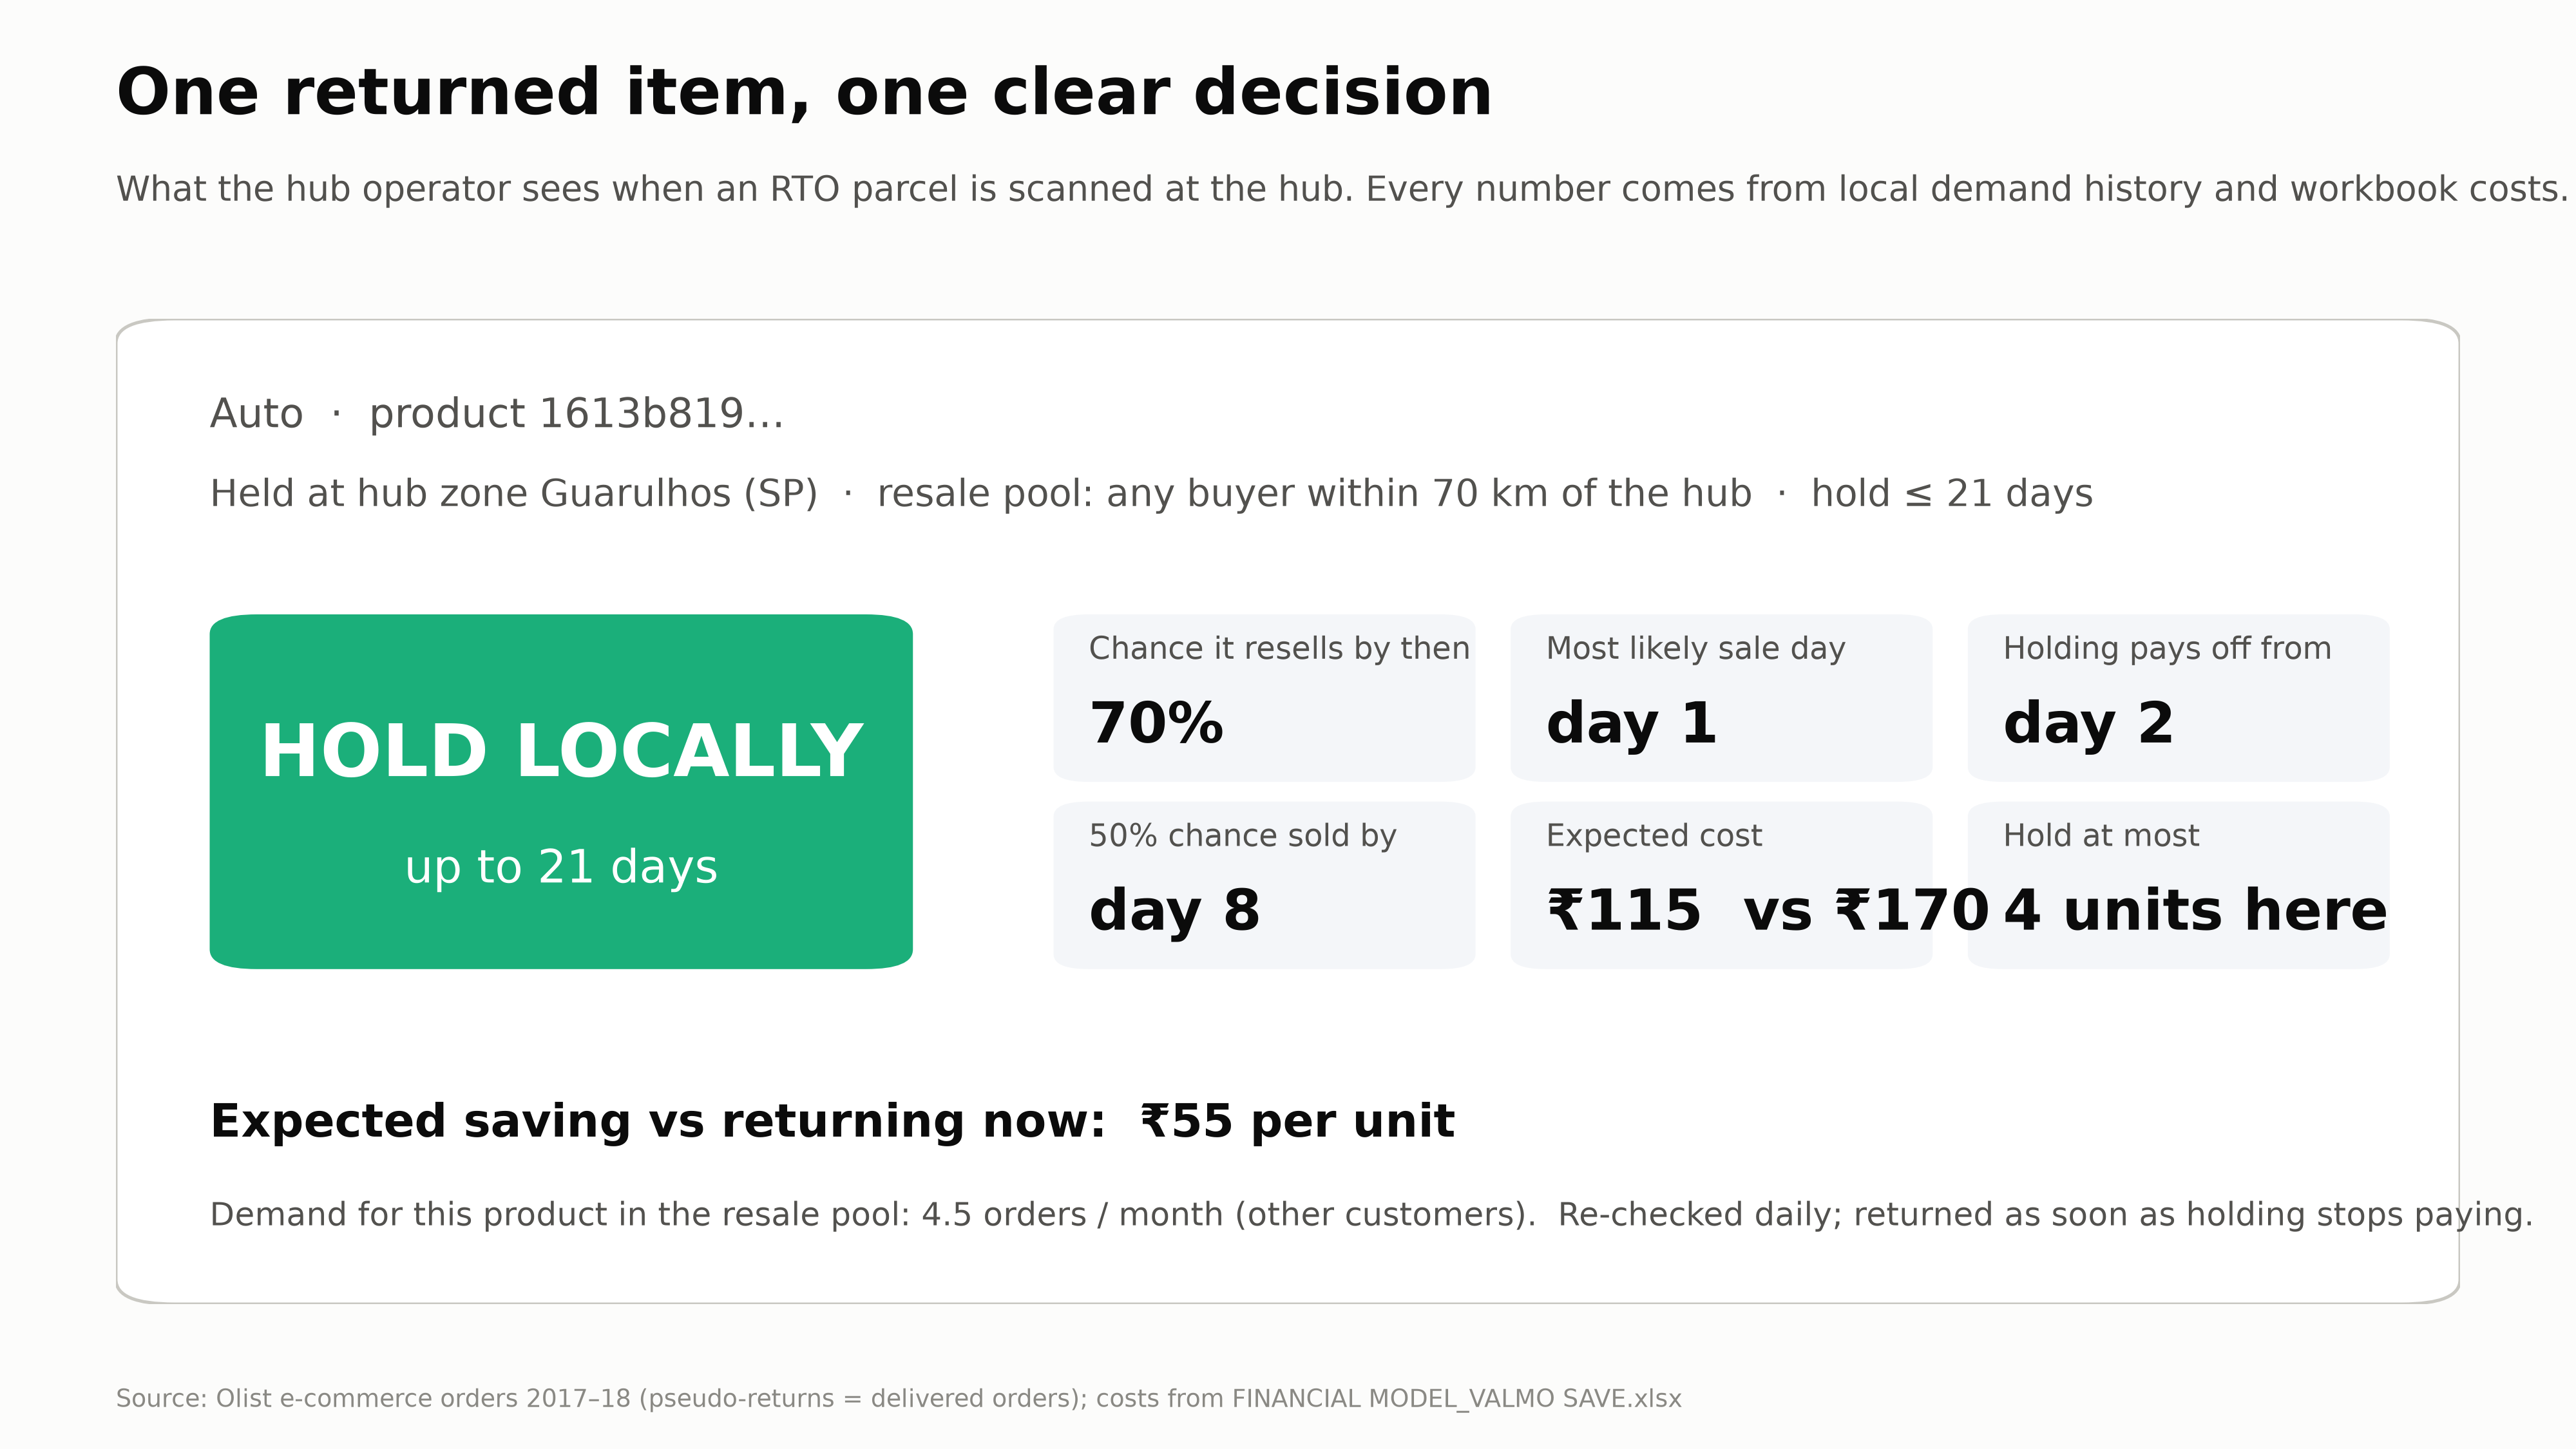

03_cumulative_vs_threshold.png


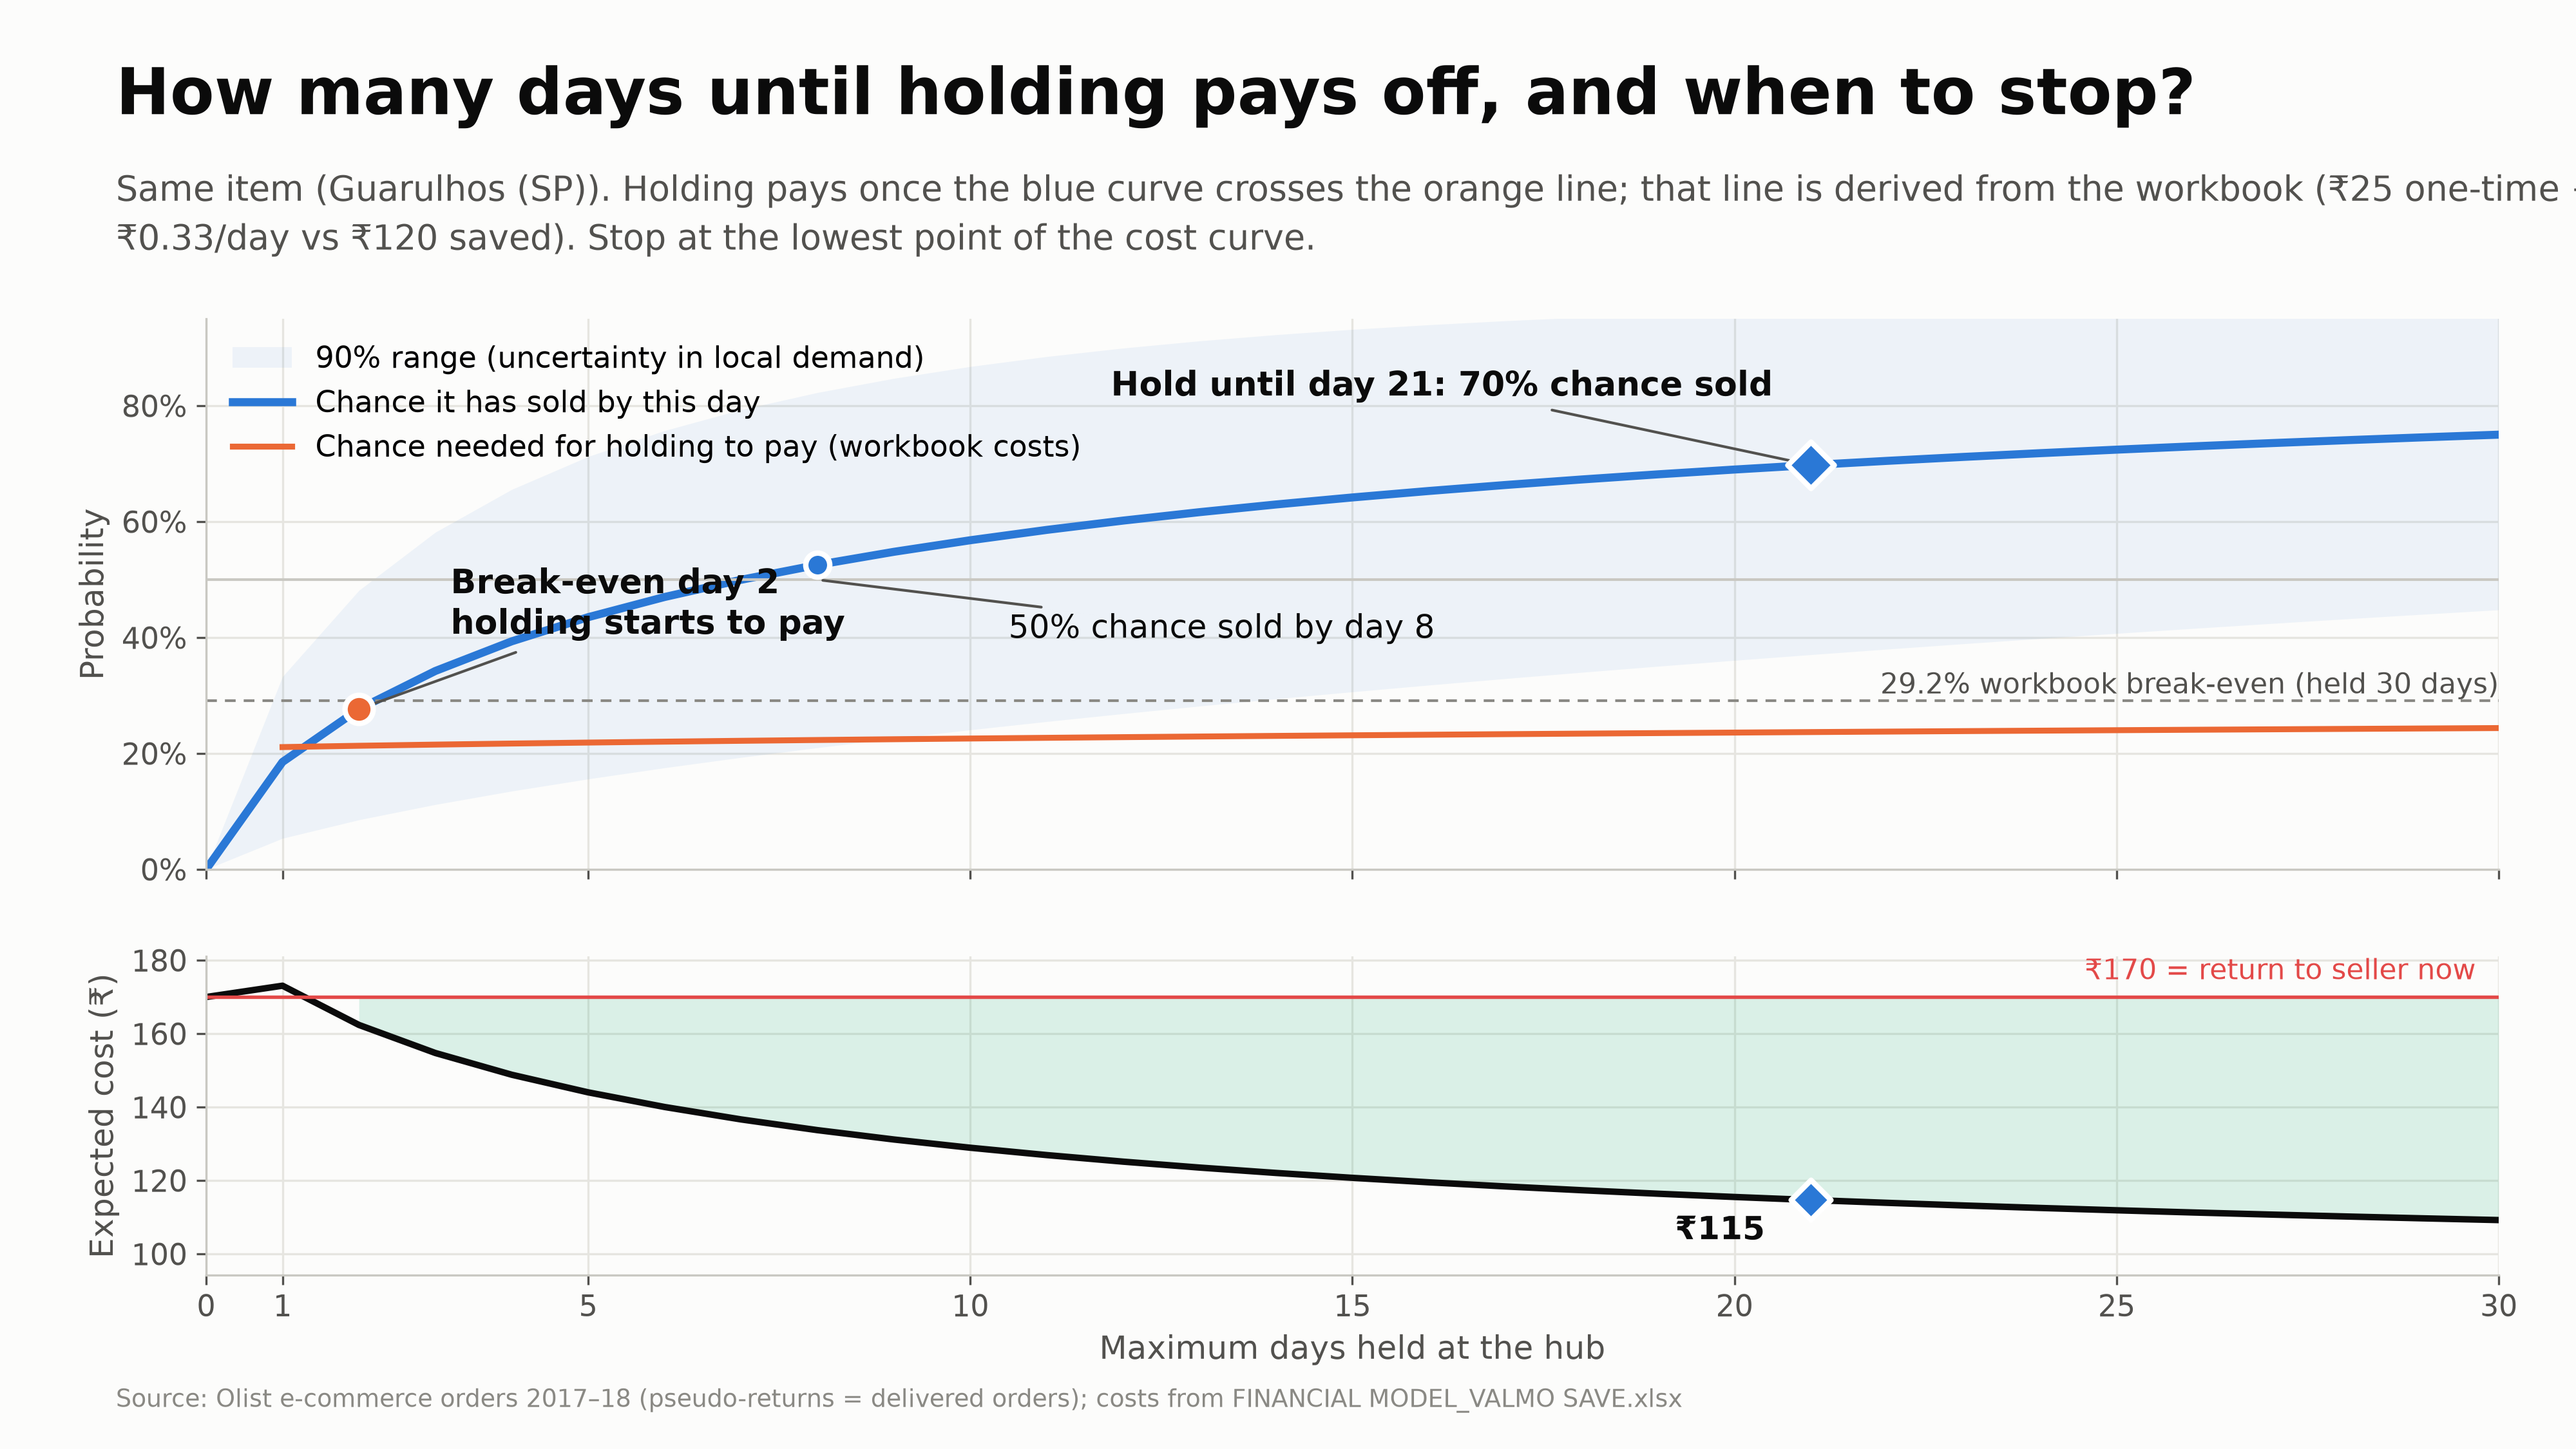

05_top_regions_for_product.png


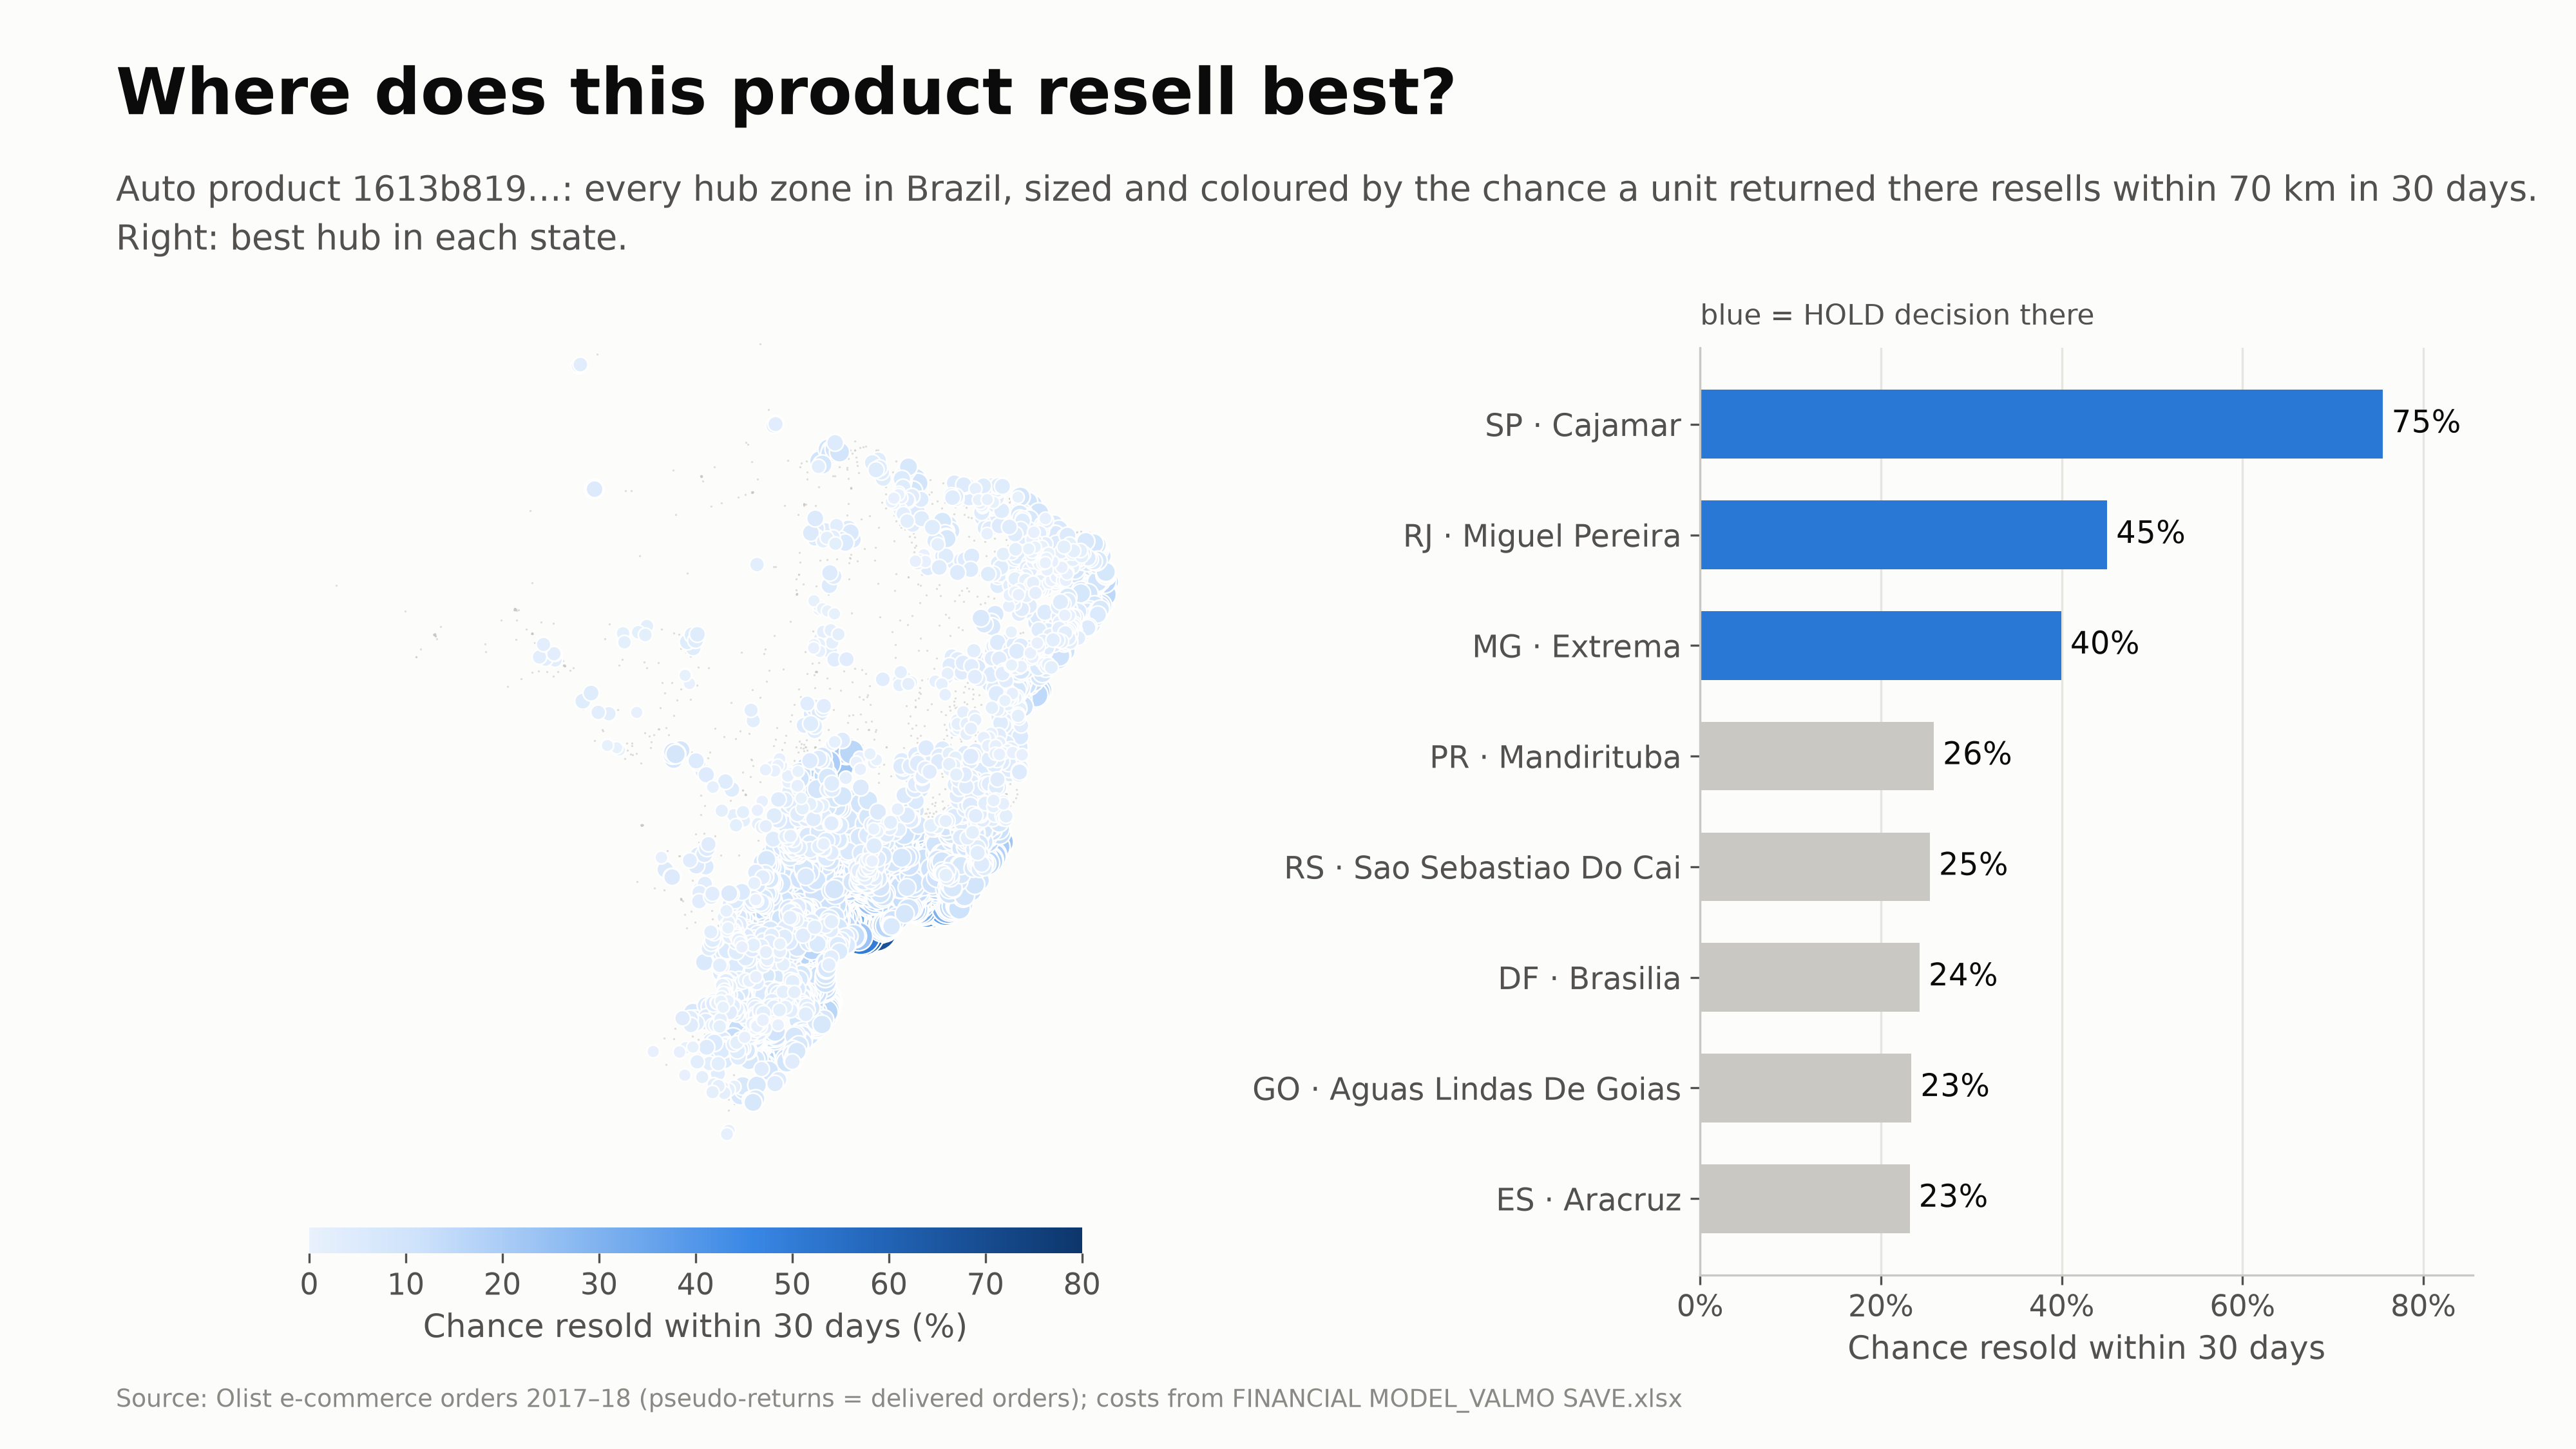

14_radius_value_curve.png


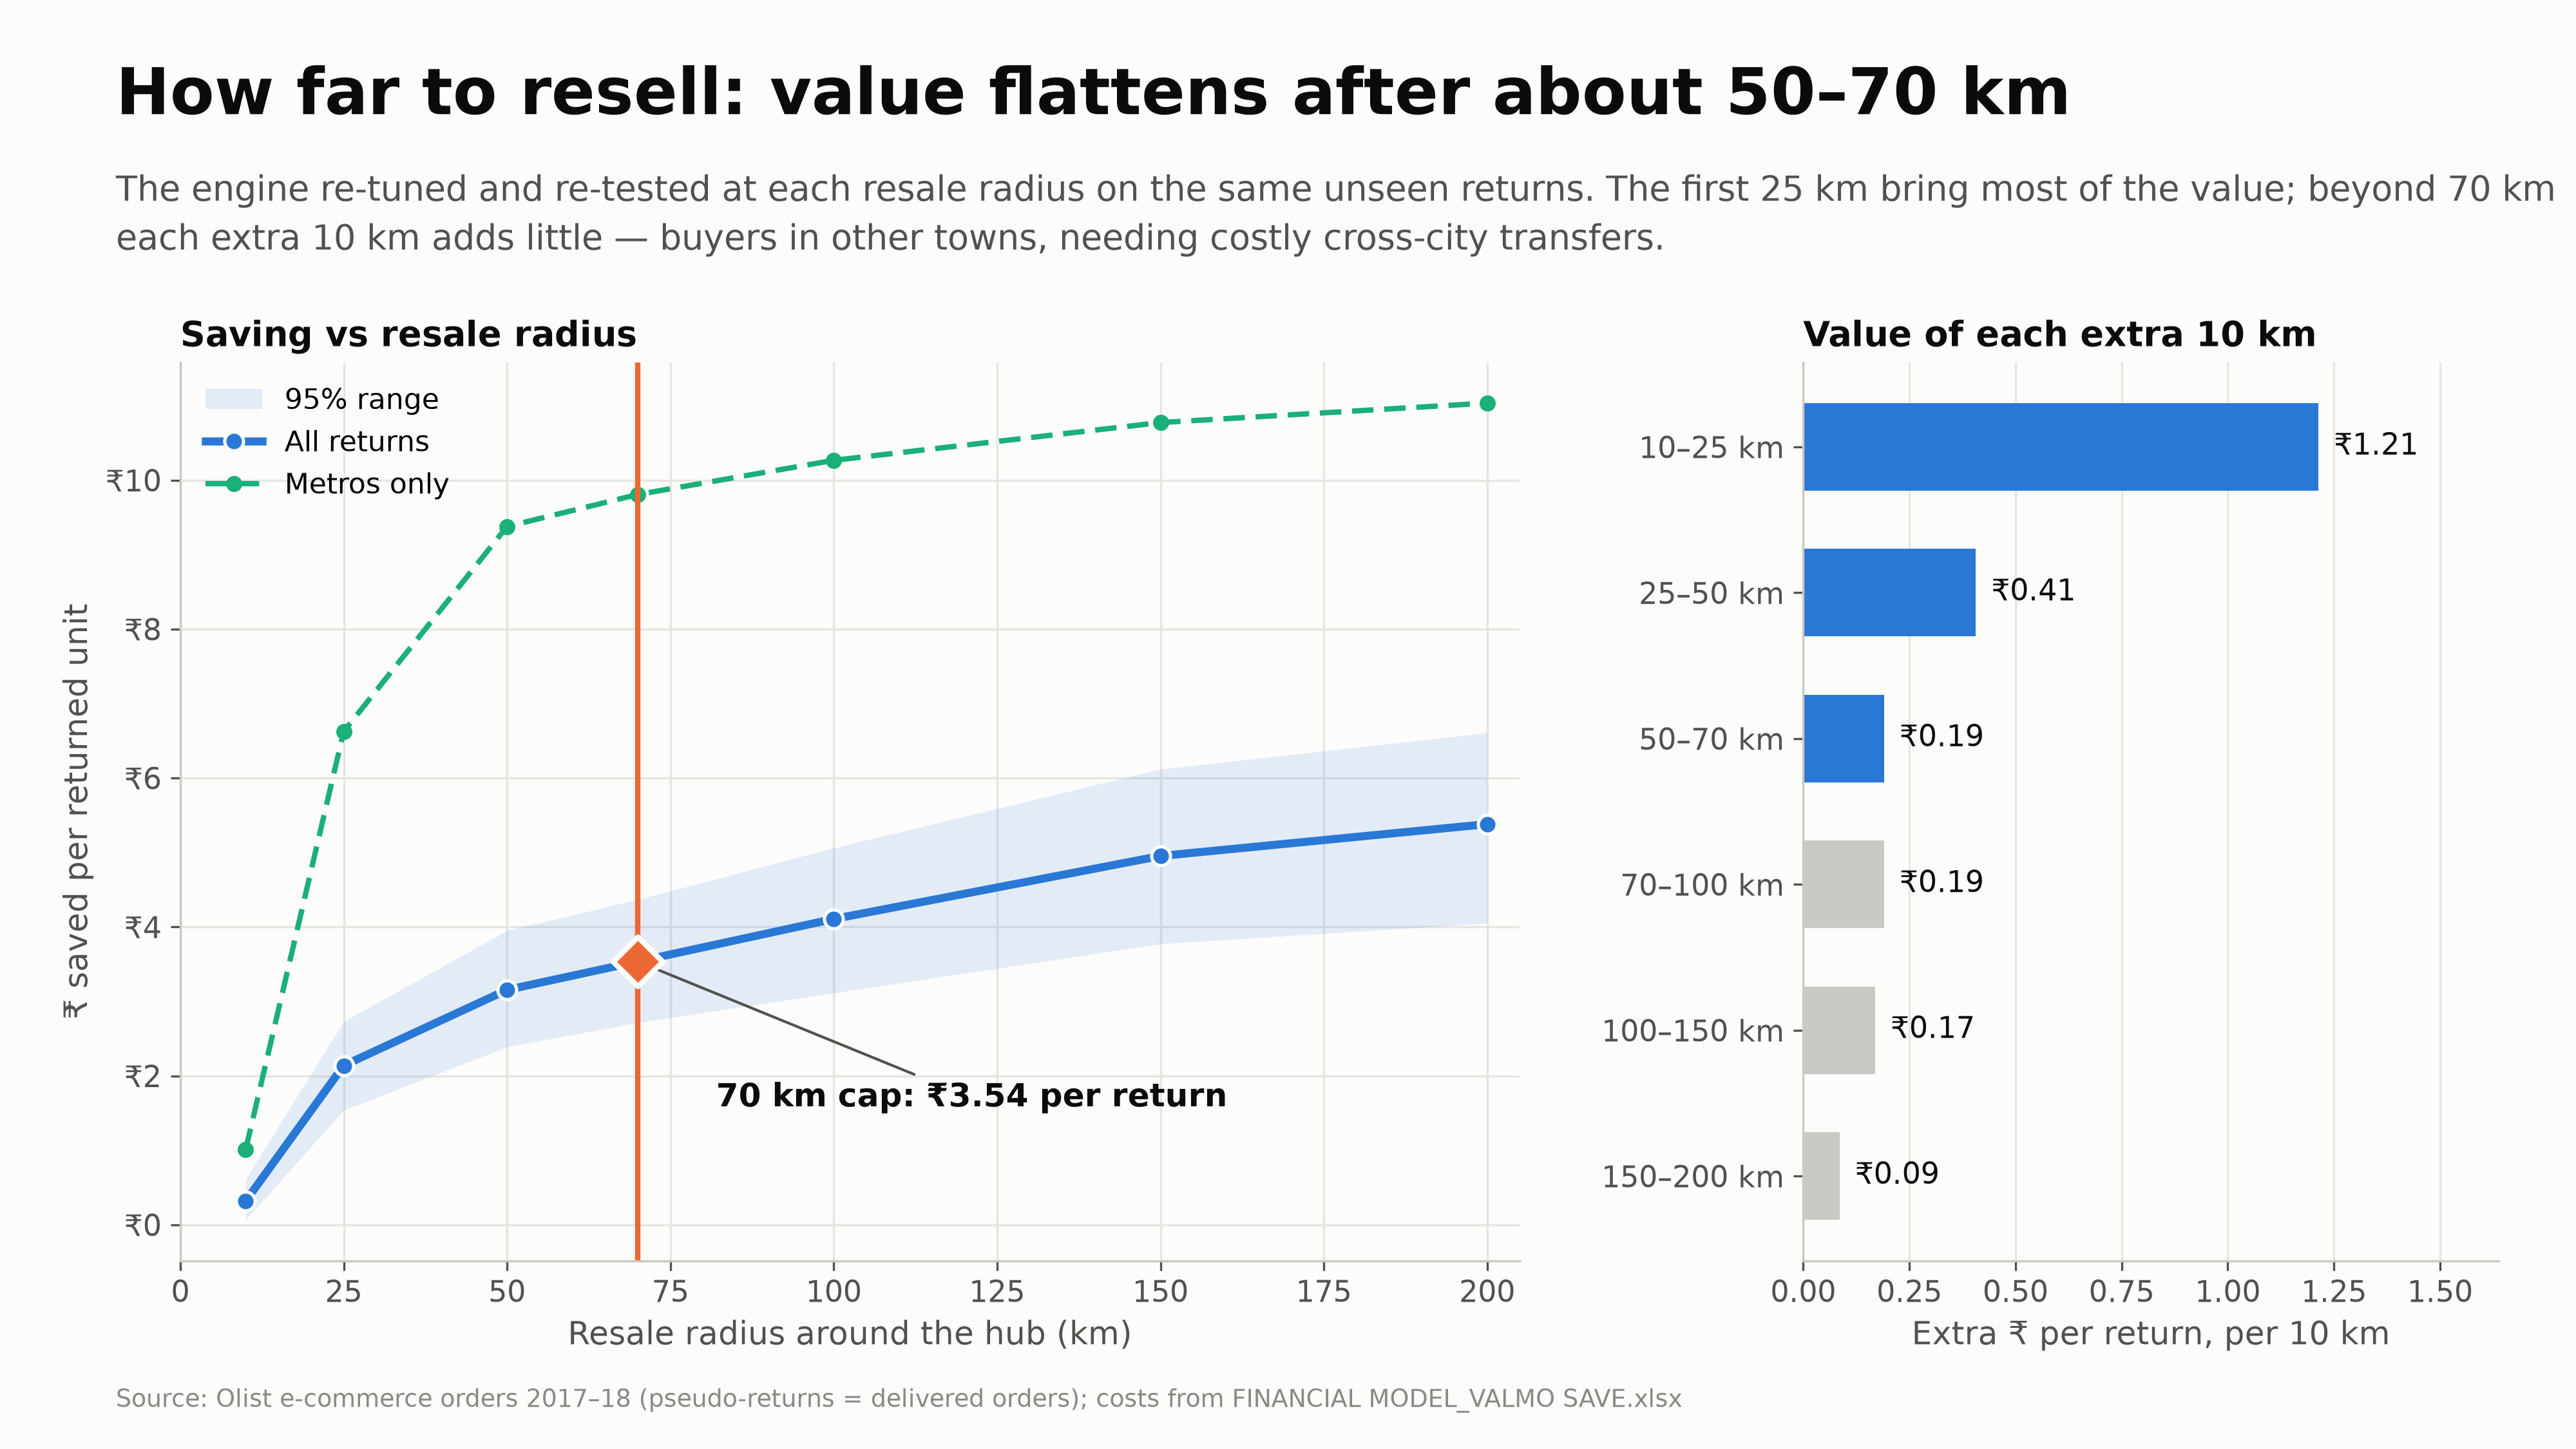

In [6]:
# Save the complete slide figure set and preview the key decision, demand, and validation charts.
from IPython.display import Image, display

MODEL_SLIDES_DIR = MODEL_OUT_DIR / "slides"
model_figure_paths, model_hero = slides_v2.make_all(model_eng, str(MODEL_SLIDES_DIR))
print(f"Hero example: {model_hero.product_id} | {model_hero.category} | {model_hero.region_name}")
print(f"Generated {len(model_figure_paths)} presentation figures in {MODEL_SLIDES_DIR}")

key_figure_names = {
    "01_decision_card.png",
    "03_cumulative_vs_threshold.png",
    "05_top_regions_for_product.png",
    "08_backtest_unseen_months.png",
    "14_radius_value_curve.png",
}
for figure_path in model_figure_paths:
    if Path(figure_path).name in key_figure_names:
        print(Path(figure_path).name)
        display(Image(filename=figure_path, width=1000))

## Review Backtest Results and Example Recommendation

In [8]:
# Display the backtest, leading metros, one recommendation, and generated artifact locations.
import pandas as pd
from IPython.display import display

print("Backtest: savings per returned item versus immediate return")
display(
    model_eng.bt_summary[
        ["policy", "returns", "hold_rate", "resale_rate_on_hold", "saving_per_return", "ci_lo", "ci_hi"]
    ].round(3)
)

print("Highest-volume data-rich areas and their calculated radii")
display(
    model_eng.areas.dropna(subset=["R_min"])
    [["name", "class", "orders_per_day", "R_min", "R_50", "R_area"]]
    .sort_values("orders_per_day", ascending=False)
    .head(10)
    .round(2)
)

hero_region_coords = model_eng.R.set_index("region").loc[
    int(model_hero.region), ["lat", "lon"]
]
example_recommendation = model_eng.recommend(
    model_hero.product_id,
    float(hero_region_coords["lat"]),
    float(hero_region_coords["lon"]),
)
print("Example returned-unit recommendation")
display(pd.Series(example_recommendation, name="recommendation"))
print("Best resale regions for the example product")
display(model_eng.top_regions(model_hero.product_id, k=8).round(3))

model_files = sorted(path for path in MODEL_OUT_DIR.rglob("*") if path.is_file())
print(f"Generated {len(model_files)} output files under {MODEL_OUT_DIR}")
print("Run report:", MODEL_OUT_DIR / "run_report.json")

Backtest: savings per returned item versus immediate return


,policy,returns,hold_rate,resale_rate_on_hold,saving_per_return,ci_lo,ci_hi
0,model (calibrated),26767,0.160,0.432,3.536,2.716,4.367
1,model (uncalibrated),26767,0.119,0.509,3.767,2.966,4.615
2,hold everything (max days),26767,0.885,0.112,-15.438,-16.845,-14.154
3,always return (status quo),26767,0.000,NaN,0.000,0.000,0.000
4,perfect hindsight,26767,0.099,1.000,9.146,8.121,10.101
5,model + daily re-decision (F4),26767,0.160,0.432,3.536,2.716,4.367


Highest-volume data-rich areas and their calculated radii


,name,class,orders_per_day,R_min,R_50,R_area
0,Sao Paulo (SP),launch,32.59,7.0,12.0,12.0
723,Rio De Janeiro (RJ),launch,11.34,7.0,15.0,15.0
1023,Belo Horizonte (MG),marginal,5.24,10.0,20.0,10.0
4193,Porto Alegre (RS),marginal,2.70,12.0,NaN,12.0
3062,Brasilia (DF),marginal,2.69,20.0,NaN,20.0
3534,Curitiba (PR),marginal,2.41,15.0,NaN,15.0
1795,Salvador (BA),marginal,2.00,12.0,NaN,12.0
751,Niteroi (RJ),marginal,1.67,12.0,25.0,12.0
46,Santos (SP),marginal,1.66,10.0,40.0,10.0
26,Campinas (SP),marginal,1.62,12.0,NaN,12.0


Example returned-unit recommendation


product_id                1613b819ab5dae53aead2dbb4ebdb378
category                                              auto
region                                      Guarulhos (SP)
hub_radius_km                                         12.0
resale_pool              any buyer within 70 km of the hub
resale_pool_radius_km                                 70.0
max_hold_days                                           21
decision                                              HOLD
hold_until_day                                          21
p_sold_by_hold_until                               0.69783
breakeven_day                                            2
most_likely_day                                          1
median_day                                               8
expected_cost                                   114.699516
status_quo                                           170.0
expected_saving                                  55.300484
demand_per_month                                  4.5308

Best resale regions for the example product


,region,name,lat,lon,demand_per_month,p_by_day30,p_by_hold,hold_until,decision,saving,orders_seen
0,39,Cajamar (SP) #2,-23.284,-46.874,4.665,0.755,0.703,21,HOLD,55.947,8.779
1,187,Jundiai (SP) #2,-23.249,-46.853,4.640,0.754,0.702,21,HOLD,55.841,8.779
2,38,Cajamar (SP) #1,-23.345,-46.838,4.629,0.754,0.702,21,HOLD,55.792,8.779
3,190,Varzea Paulista (SP),-23.246,-46.825,4.626,0.754,0.667,17,HOLD,52.096,8.779
4,7,Franco Da Rocha (SP),-23.322,-46.734,4.614,0.753,0.701,21,HOLD,55.729,8.779
5,150,Atibaia (SP) #2,-23.219,-46.595,4.543,0.751,0.699,21,HOLD,55.390,8.528
6,9,Guarulhos (SP),-23.454,-46.466,4.531,0.750,0.698,21,HOLD,55.300,8.205
7,12,Sao Paulo (SP) #5,-23.492,-46.585,4.491,0.749,0.696,21,HOLD,55.123,8.205


Generated 46 output files under /Users/dhruv_rai/Desktop/Meesho/outputs_v2
Run report: /Users/dhruv_rai/Desktop/Meesho/outputs_v2/run_report.json
